# IPSA (CC01-1940): modelos de clasificación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/sugarcane-yield-quality-prediction/blob/main/02_modelos_clasificacion.ipynb)

Este notebook entrena y evalúa los modelos de clasificación de la parte de `BD_IPSA_1940` del taller.
Continúa el análisis de `01_eda_ipsa.ipynb`, donde se definieron los predictores, el tratamiento de los
valores faltantes y las clases.

**Objetivo:** clasificar cada cosecha en un nivel bajo, medio o alto de TCH y de sacarosa, como dos
problemas independientes, con información disponible antes de la cosecha. Se comparan dos modelos
(regresión logística multinomial con regularización y KNN) y dos definiciones de clase (umbrales del
Ingenio y terciles).

**Entrada.** El archivo `datos/ipsa_limpio.parquet`, generado al final de `01_eda_ipsa.ipynb`. Contiene
los targets, la marca `excluir_tch`, los 13 predictores seleccionados y las clases definidas con los
umbrales del Ingenio. En Colab hay que ejecutar primero `01_eda_ipsa.ipynb` en la misma sesión, o subir
el archivo `ipsa_limpio.parquet` a la carpeta `datos/`.

**Criterios generales**

- La partición en entrenamiento (80 %) y prueba (20 %) debe reproducir la situación en la que se usaría
  el modelo: clasificar cosechas antes de que ocurran. La forma de agrupar las cosechas para lograrlo se
  define en la sección 11, y la validación cruzada usa la misma agrupación.
- Todos los estadísticos se calculan solo con el conjunto de entrenamiento. La imputación, el acotamiento
  y el escalado se ajustan dentro de un pipeline, de modo que se recalculan en cada pliegue de la
  validación cruzada. Los cortes de los terciles se calculan una vez, sobre el conjunto de entrenamiento.
- Los 4 registros marcados con `excluir_tch` se excluyen de la clasificación de TCH y se conservan en la
  de sacarosa.
- Las clases no están balanceadas con los umbrales del Ingenio, así que se reportan métricas por clase
  (precisión, sensibilidad y F1), el F1 macro, el índice kappa y el área bajo la curva ROC, además de la
  exactitud. La sensibilidad de la clase baja tiene especial importancia, porque corresponde a las
  suertes que el Ingenio necesita detectar.

**Flujo del notebook**

10. Carga del dataset procesado
11. Partición en entrenamiento y prueba
12. Clases por terciles
13. Pipeline de preprocesamiento
14. Regresión logística multinomial
15. KNN
16. Evaluación de variables candidatas (`anio`, armónicos del mes, `lluvia_sin_dato`, `edad²` y un
    conjunto reducido para KNN)
17. Evaluación en el conjunto de prueba
18. Interpretación y conclusiones

> **Datos:** `datos/ipsa_limpio.parquet` no está en el repositorio porque el enunciado prohíbe publicar
> los datos.

In [146]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

%matplotlib inline
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.9.1


## 10. Carga del dataset procesado

Se carga el dataset generado por `01_eda_ipsa.ipynb` y se verifica que conserva las propiedades
establecidas en el EDA: número de registros y columnas, registros marcados con `excluir_tch`, clases
del Ingenio y valores faltantes en los predictores. Si alguna verificación falla, el archivo no
corresponde a la versión final del EDA y el notebook se detiene.

In [147]:
# 10. Carga del dataset procesado
RANDOM_STATE = 42  # mismo valor que en el análisis de regresión del histórico de suertes

df = pd.read_parquet("datos/ipsa_limpio.parquet")

# Predictores definidos en la sección 7 del EDA
predictores_num = ["edad", "cortes", "semsmad", "lluvias", "pct_diatrea", "dosismad", "anio"]
predictores_bin = ["lluvia_sin_dato"]
predictores_mes = ["mes_sin_12", "mes_cos_12", "mes_sin_6", "mes_cos_6"]
predictores_cat = ["grupo_tenencia"]
predictores = predictores_num + predictores_bin + predictores_mes + predictores_cat

# Verificaciones de lo establecido en el EDA
assert df.shape == (2187, 22), f"Dimensiones inesperadas: {df.shape}"
assert set(predictores) <= set(df.columns), "Faltan predictores en el archivo"
assert df["excluir_tch"].sum() == 4, "El número de registros con excluir_tch no es 4"
assert df.loc[df["excluir_tch"], "clase_tch_ingenio"].isna().all(), "Registros excluidos con clase de TCH"
assert df.loc[~df["excluir_tch"], "clase_tch_ingenio"].notna().all(), "Registros válidos sin clase de TCH"
assert df["clase_sac_ingenio"].notna().all(), "Registros sin clase de sacarosa"
assert df["clase_tch_ingenio"].cat.ordered, "Las clases perdieron su orden (bajo < medio < alto)"

nulos_esperados = {"lluvias": 685, "semsmad": 2, "dosismad": 2}
nulos = df[predictores].isna().sum()
assert nulos[nulos > 0].to_dict() == nulos_esperados, f"Faltantes inesperados: {nulos[nulos > 0].to_dict()}"

print("Registros:", len(df), "| Predictores:", len(predictores))
display(df.head())

Registros: 2187 | Predictores: 13


,FAZ,TAL,periodo,mes,TCH,sacarosa,excluir_tch,edad,cortes,semsmad,lluvias,pct_diatrea,dosismad,anio,lluvia_sin_dato,mes_sin_12,mes_cos_12,mes_sin_6,mes_cos_6,grupo_tenencia,clase_tch_ingenio,clase_sac_ingenio
0,81291,40,202012,12,112,14.0,False,12.3,4,8.3,137.0,6.2,0.8,2020,False,-2.449294e-16,1.000000e+00,-4.898587e-16,1.0,3,bajo,alto
1,81291,41,201903,3,157,13.0,False,11.2,2,6.3,NaN,3.5,0.8,2019,True,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto
2,81291,41,202003,3,167,13.3,False,12.2,3,7.9,68.0,4.3,0.6,2020,False,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto
3,81291,43,201903,3,156,13.4,False,13.1,1,6.6,NaN,3.5,0.8,2019,True,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto
4,81291,43,202003,3,151,14.0,False,12.2,2,8.1,68.0,4.3,0.6,2020,False,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,3,alto,alto


### Conclusión de la sección 10

El dataset tiene 2.187 registros y 22 columnas, y cumple todas las propiedades establecidas en el EDA:
13 predictores, 4 registros marcados con `excluir_tch` sin clase de TCH, clases de sacarosa completas con
el orden bajo < medio < alto, y faltantes solo en `lluvias` (685), `semsmad` (2) y `dosismad` (2).

## 11. Partición en entrenamiento y prueba

Los datos se dividen en entrenamiento (80 %) y prueba (20 %) antes de cualquier imputación, escalado o
cálculo de terciles. El conjunto de prueba no se vuelve a usar hasta la evaluación final (sección 17).

La partición debe reproducir la situación en la que se usaría el modelo: clasificar las cosechas de un
periodo antes de que ocurran, cuando ninguna cosecha de ese periodo tiene todavía su resultado. Por eso
se revisa primero cómo se distribuyen las cosechas de cada hacienda en el tiempo (11.1), y con ese
resultado se define la partición (11.2).

### 11.1 Cosechas simultáneas de una misma hacienda

Una hacienda puede cosechar varias de sus suertes en el mismo periodo (`periodo`, año y mes). Esas
cosechas comparten el año y el mes, y pueden tener valores parecidos de los demás predictores y
resultados parecidos, por compartir suelo, manejo y condiciones climáticas. Si una de ellas queda en
entrenamiento y otra en prueba, el modelo se evalúa con información de una cosecha simultánea, que no
estaría disponible al clasificar un periodo antes de que ocurra.

Para medir qué tan frecuente es esta situación, se calcula la proporción de cosechas que tienen al menos
otra suerte de su hacienda cosechada en el mismo periodo. Después se comparan todas las parejas de
cosechas de suertes distintas, separadas en tres tipos: de la misma hacienda y el mismo periodo, de otra
hacienda en el mismo periodo, y de periodos distintos. Para cada tipo se calcula el porcentaje de parejas
con la misma lluvia registrada, la diferencia mediana de edad y de número de cortes, y el porcentaje de
parejas con la misma clase de TCH y de sacarosa según los umbrales del Ingenio, que se compara con la
coincidencia esperada por azar.

In [148]:
# 11.1 Cosechas simultáneas de una misma hacienda
# Identificador de suerte (hacienda + suerte)
df["suerte"] = df["FAZ"].astype(str) + "_" + df["TAL"]

# Cosechas de cada hacienda en cada periodo
tam_grupo = df.groupby(["FAZ", "periodo"])["suerte"].transform("size")
print(f"Cosechas con al menos otra suerte de su hacienda en el mismo periodo: "
      f"{(tam_grupo > 1).sum()} de {len(df)} ({(tam_grupo > 1).mean():.1%})")
print(f"Mediana de suertes cosechadas por hacienda y periodo: "
      f"{df.groupby(['FAZ', 'periodo']).size().median():.0f}")

# Todas las parejas de cosechas de suertes distintas, clasificadas por hacienda y periodo
i, j = np.triu_indices(len(df), k=1)
a, b = df.iloc[i].reset_index(drop=True), df.iloc[j].reset_index(drop=True)
distinta_suerte = (a["suerte"] != b["suerte"]).to_numpy()
a, b = a[distinta_suerte].reset_index(drop=True), b[distinta_suerte].reset_index(drop=True)

tipo = pd.Series(np.select(
    [(a["FAZ"] == b["FAZ"]) & (a["periodo"] == b["periodo"]), a["periodo"] == b["periodo"]],
    ["Misma hacienda y mismo periodo", "Otra hacienda, mismo periodo"],
    default="Distinto periodo",
), name="Tipo de pareja")


def porcentaje_igual(col):
    """Porcentaje de parejas con el mismo valor, entre las que tienen el dato en ambas cosechas."""
    validas = a[col].notna() & b[col].notna()
    igual = (a[col].astype(object) == b[col].astype(object)).astype(float).where(validas)
    return igual.groupby(tipo).mean().mul(100)


parejas = pd.DataFrame({
    "Parejas": tipo.value_counts(),
    "% misma lluvia": porcentaje_igual("lluvias"),
    "Dif. mediana de edad (meses)": (a["edad"] - b["edad"]).abs().groupby(tipo).median(),
    "Dif. mediana de cortes": (a["cortes"] - b["cortes"]).abs().groupby(tipo).median(),
    "% misma clase TCH": porcentaje_igual("clase_tch_ingenio"),
    "% misma clase sacarosa": porcentaje_igual("clase_sac_ingenio"),
}).reindex(["Misma hacienda y mismo periodo", "Otra hacienda, mismo periodo", "Distinto periodo"])
display(parejas.round(1))

# Coincidencia esperada por azar: probabilidad de que dos cosechas al azar tengan la misma clase
azar = {col: (df[col].value_counts(normalize=True) ** 2).sum() * 100
        for col in ["clase_tch_ingenio", "clase_sac_ingenio"]}
print(f"Coincidencia de clase esperada por azar: TCH {azar['clase_tch_ingenio']:.1f} % | "
      f"sacarosa {azar['clase_sac_ingenio']:.1f} %")

Cosechas con al menos otra suerte de su hacienda en el mismo periodo: 1365 de 2187 (62.4%)
Mediana de suertes cosechadas por hacienda y periodo: 1


,Parejas,% misma lluvia,Dif. mediana de edad (meses),Dif. mediana de cortes,% misma clase TCH,% misma clase sacarosa
Tipo de pareja,,,,,,
Misma hacienda y mismo periodo,1655,34.5,0.2,0.0,58.3,56.0
"Otra hacienda, mismo periodo",53174,0.7,0.7,1.0,36.3,48.1
Distinto periodo,2333868,0.3,0.9,1.0,35.0,35.2


Coincidencia de clase esperada por azar: TCH 35.1 % | sacarosa 35.6 %


### Conclusión de 11.1

- El 62.4 % de las cosechas (1.365 de 2.187) tiene al menos otra suerte de su hacienda cosechada en el
  mismo periodo.

| Tipo de pareja | Parejas | Misma lluvia | Dif. mediana de edad | Dif. mediana de cortes | Misma clase TCH | Misma clase sacarosa |
|---|---|---|---|---|---|---|
| Misma hacienda y mismo periodo | 1.655 | 34.5 % | 0.2 meses | 0 | 58.3 % | 56.0 % |
| Otra hacienda, mismo periodo | 53.174 | 0.7 % | 0.7 meses | 1 | 36.3 % | 48.1 % |
| Distinto periodo | 2.333.868 | 0.3 % | 0.9 meses | 1 | 35.0 % | 35.2 % |

  La coincidencia de clase esperada por azar es 35.1 % en TCH y 35.6 % en sacarosa.

- Las cosechas simultáneas de una misma hacienda tienen predictores muy parecidos: su edad difiere en
  0.2 meses, tienen el mismo número de cortes y el 34.5 % registra exactamente la misma lluvia, frente a
  menos del 1 % en los demás tipos de pareja. Que la lluvia no coincida en la mayoría de ellas indica que
  `lluvias` no es un valor común de la hacienda en el mes, sino que se acumula en una ventana propia de
  cada suerte.
- En TCH, la clase coincide en el 58.3 % de las parejas de la misma hacienda y el mismo periodo, frente
  al 35.0–36.3 % de los demás tipos, igual al azar. El parecido en tonelaje es propio de cada hacienda.
- En sacarosa, la coincidencia sube tanto en la misma hacienda (56.0 %) como en otras haciendas del mismo
  periodo (48.1 %), frente al 35.2 % entre periodos distintos. La sacarosa depende de condiciones que
  comparten todas las haciendas en un mismo mes.
- Con una partición agrupada solo por suerte, la mayoría de las cosechas tendría en entrenamiento otra
  cosecha simultánea casi idéntica en sus predictores y con una clase parecida, cuyo resultado no se
  conocería al momento de clasificar. Agrupar por hacienda evitaría las parejas de la misma hacienda,
  pero no las de otras haciendas del mismo periodo, que se parecen en sacarosa. La partición se agrupa
  por periodo, de modo que todas las cosechas de un mismo mes y año queden en el mismo conjunto.

### 11.2 Partición agrupada por periodo

La partición cumple tres condiciones:

- **Agrupada por periodo.** Todas las cosechas de un mismo mes y año quedan en el mismo conjunto. Así, el
  desempeño en prueba corresponde a periodos que el modelo no vio en el entrenamiento, sin cosechas
  simultáneas en el otro conjunto. En el análisis de regresión del histórico de suertes se usó una
  partición aleatoria de registros, y se documentó como limitación que las cosechas de una misma suerte
  pueden quedar en ambos conjuntos.
- **Estratificada.** Conserva en ambos conjuntos, en lo posible, la proporción de cada combinación de
  clases de TCH y de sacarosa (umbrales del Ingenio). Los cuatro registros con `excluir_tch` tienen TCH
  menor que 60 t/ha, así que para la estratificación se agrupan con la clase baja de TCH.
- **Común a ambos targets.** Los dos problemas se evalúan sobre los mismos periodos de prueba.

Se usa `StratifiedGroupKFold` con 5 pliegues, y uno de ellos se toma como conjunto de prueba, lo que
equivale a una proporción cercana al 20 %. Como cada periodo agrupa muchas cosechas, el conjunto de
prueba queda formado por pocos periodos completos, y puede dejar sin representar algunos meses del año.
El mes de cosecha es uno de los predictores con fundamento agronómico más claro, así que el pliegue se
elige con una regla fija que solo considera la composición del conjunto de prueba: el de menor número de
meses con menos de 10 cosechas y, en caso de empate, el de menor diferencia en la proporción de clases
entre entrenamiento y prueba. La regla no usa el desempeño de ningún modelo.

Además del tamaño y del balance de clases, se revisa cómo se distribuyen los años y los meses de
cosecha en cada conjunto. Por último, se cuenta cuántas cosechas de prueba pertenecen a suertes que
también tienen cosechas en entrenamiento, en otros periodos. Esa situación es legítima: al clasificar una
cosecha futura, las cosechas anteriores de la misma suerte ya tienen su resultado.

In [149]:
# 11.2 Partición en entrenamiento y prueba: agrupada por periodo y estratificada
from sklearn.model_selection import StratifiedGroupKFold

# Estrato: combinación de las clases del Ingenio de ambos targets
# Los 4 registros con excluir_tch tienen TCH < 60, así que solo para estratificar se agrupan con "bajo"
estrato = (df["clase_tch_ingenio"].astype(str).where(~df["excluir_tch"], "bajo")
           + "|" + df["clase_sac_ingenio"].astype(str))

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pliegues = list(sgkf.split(df, estrato, groups=df["periodo"]))


def diferencia_clases(tr, te):
    """Máxima diferencia, en puntos porcentuales, entre la proporción de una clase en train y en test."""
    return max((tr[col].value_counts(normalize=True) - te[col].value_counts(normalize=True)).abs().max()
               for col in ["clase_tch_ingenio", "clase_sac_ingenio"]) * 100


# Características de cada uno de los 5 pliegues candidatos a conjunto de prueba
candidatos = pd.DataFrame([{
    "% test": len(te) / len(df) * 100,
    "Periodos en test": df.iloc[te]["periodo"].nunique(),
    "Meses con menos de 10 cosechas en test": (df.iloc[te]["mes"].value_counts()
                                               .reindex(range(1, 13), fill_value=0) < 10).sum(),
    "Años en test": df.iloc[te]["anio"].nunique(),
    "Máx. diferencia de clase (pp)": diferencia_clases(df.iloc[tr], df.iloc[te]),
} for tr, te in pliegues]).rename_axis("Pliegue")
display(candidatos.round(1))

# Regla: menos meses mal representados en test; en empate, menor diferencia de clases
elegido = candidatos.sort_values(["Meses con menos de 10 cosechas en test",
                                  "Máx. diferencia de clase (pp)"]).index[0]
idx_train, idx_test = pliegues[elegido]
df_train, df_test = df.iloc[idx_train].copy(), df.iloc[idx_test].copy()
print(f"Pliegue elegido como conjunto de prueba: {elegido}")

# Ningún periodo puede estar en ambos conjuntos
assert set(df_train["periodo"]).isdisjoint(df_test["periodo"]), "Hay periodos en train y en test"

for nombre, d in [("Train", df_train), ("Test", df_test)]:
    print(f"{nombre}: {len(d)} registros ({len(d) / len(df):.1%}) | {d['periodo'].nunique()} periodos | "
          f"{d['suerte'].nunique()} suertes")
print("Registros con excluir_tch en train / test:",
      df_train["excluir_tch"].sum(), "/", df_test["excluir_tch"].sum())

# Proporción de cada clase en train y en test, por target
balance_split = pd.DataFrame({
    ("TCH", "train"): df_train["clase_tch_ingenio"].value_counts(normalize=True),
    ("TCH", "test"): df_test["clase_tch_ingenio"].value_counts(normalize=True),
    ("sacarosa", "train"): df_train["clase_sac_ingenio"].value_counts(normalize=True),
    ("sacarosa", "test"): df_test["clase_sac_ingenio"].value_counts(normalize=True),
}).reindex(["bajo", "medio", "alto"]).mul(100).round(1)
display(balance_split)

# Distribución de las cosechas por año y por mes en cada conjunto
display(pd.DataFrame({"Train": df_train["anio"].value_counts(), "Test": df_test["anio"].value_counts()})
        .sort_index().fillna(0).astype(int).rename_axis("Año").T)
display(pd.DataFrame({"Train": df_train["mes"].value_counts(), "Test": df_test["mes"].value_counts()})
        .sort_index().fillna(0).astype(int).rename_axis("Mes").T)

# Suertes con cosechas en ambos conjuntos (en periodos distintos)
suertes_comunes = set(df_train["suerte"]) & set(df_test["suerte"])
en_comun = df_test["suerte"].isin(suertes_comunes)
print(f"Cosechas de prueba cuya suerte tiene otra cosecha en entrenamiento: {en_comun.sum()} de "
      f"{len(df_test)} ({en_comun.mean():.1%})")

,% test,Periodos en test,Meses con menos de 10 cosechas en test,Años en test,Máx. diferencia de clase (pp)
Pliegue,,,,,
0,19.6,12,5,5,3.0
1,19.8,15,6,7,0.7
2,19.9,15,4,7,2.3
3,20.6,16,4,6,0.3
4,20.2,14,6,5,0.8


Pliegue elegido como conjunto de prueba: 3
Train: 1737 registros (79.4%) | 56 periodos | 1000 suertes
Test: 450 registros (20.6%) | 16 periodos | 401 suertes
Registros con excluir_tch en train / test: 4 / 0


TCH       sacarosa      
      train  test    train  test
bajo   22.6  22.7     21.5  21.6
medio  38.9  39.1     36.6  36.9
alto   38.5  38.2     41.9  41.6

Año,2014,2015,2016,2017,2018,2019,2020,2021
Train,1,28,89,190,244,522,577,86
Test,0,7,21,27,164,80,151,0


Mes,1,2,3,4,5,6,7,8,9,10,11,12
Train,216,67,98,82,173,175,90,104,167,249,126,190
Test,15,3,87,98,1,44,36,45,54,5,62,0


Cosechas de prueba cuya suerte tiene otra cosecha en entrenamiento: 326 de 450 (72.4%)


### Conclusión de 11.2

| Pliegue | % test | Periodos en test | Meses con menos de 10 cosechas en test | Años en test | Máx. diferencia de clase (pp) |
|---|---|---|---|---|---|
| 0 | 19.6 | 12 | 5 | 5 | 3.0 |
| 1 | 19.8 | 15 | 6 | 7 | 0.7 |
| 2 | 19.9 | 15 | 4 | 7 | 2.3 |
| **3** | **20.6** | **16** | **4** | **6** | **0.3** |
| 4 | 20.2 | 14 | 6 | 5 | 0.8 |

- Se eligió el pliegue 3. Comparte con el pliegue 2 el menor número de meses mal representados (4), y
  tiene la menor diferencia en la proporción de clases entre entrenamiento y prueba (0.3 puntos
  porcentuales).

| | Registros | Periodos | Suertes |
|---|---|---|---|
| Entrenamiento | 1.737 (79.4 %) | 56 | 1.000 |
| Prueba | 450 (20.6 %) | 16 | 401 |

- Ningún periodo aparece en ambos conjuntos, así que el desempeño en prueba corresponde a periodos que el
  modelo no vio durante el entrenamiento, sin cosechas simultáneas en entrenamiento.
- La proporción de cada clase del Ingenio difiere como máximo 0.3 puntos porcentuales entre
  entrenamiento y prueba, en ambos targets:

| Clase | TCH train | TCH test | Sacarosa train | Sacarosa test |
|---|---|---|---|---|
| Bajo | 22.6 % | 22.7 % | 21.5 % | 21.6 % |
| Medio | 38.9 % | 39.1 % | 36.6 % | 36.9 % |
| Alto | 38.5 % | 38.2 % | 41.9 % | 41.6 % |

- El conjunto de prueba cubre las cosechas de 2015 a 2020. No incluye 2014 ni 2021, que tienen pocas
  cosechas en total (1 y 86).
- Ningún pliegue cubre bien los 12 meses, porque el conjunto de prueba está formado por solo 16
  periodos. En el elegido, febrero (3 cosechas), mayo (1), octubre (5) y diciembre (0) quedan con menos
  de 10 cosechas en prueba. El conjunto de entrenamiento sí tiene al menos 67 cosechas en cada mes, así
  que los modelos aprenden el efecto de todos los meses, pero la evaluación final no mide su desempeño
  en esos cuatro.
- El 72.4 % de las cosechas de prueba (326 de 450) pertenece a suertes que tienen cosechas en
  entrenamiento, en otros periodos. Esa información estaría disponible al clasificar una cosecha futura.
- Los cuatro registros con `excluir_tch` quedaron en el conjunto de entrenamiento. La clasificación de
  TCH usa 1.733 registros de entrenamiento y los 450 de prueba; la de sacarosa usa los 1.737 y los 450.

### Conclusión de la sección 11

La mayoría de las cosechas tiene otra suerte de su hacienda cosechada en el mismo periodo, con
predictores casi idénticos y una clase de TCH parecida. Además, la sacarosa de haciendas distintas se
parece dentro de un mismo periodo. Por eso la partición se agrupa por periodo: el conjunto de prueba
está formado por 16 meses completos (450 cosechas, 20.6 %), sin cosechas simultáneas en entrenamiento, y
conserva la proporción de clases con una diferencia máxima de 0.3 puntos porcentuales. La evaluación
final no cubre bien febrero, mayo, octubre y diciembre, que quedan con menos de 10 cosechas en prueba.
La validación cruzada de las secciones 14 y 15 usa la misma agrupación por periodo.

## 12. Clases por terciles

La segunda definición de clase divide cada target en tres grupos del mismo tamaño. Los cortes (percentiles
33 y 67) se calculan solo con el conjunto de entrenamiento y se aplican a ambos conjuntos, de modo que las
clases del conjunto de prueba se asignan con fronteras calculadas sin sus datos. En TCH se excluyen del
cálculo los registros con `excluir_tch`, que tampoco reciben clase.

Se comparan los cortes obtenidos con los terciles de referencia del EDA, calculados sobre el dataset
completo, y con los umbrales del Ingenio, y se verifica el balance de las clases en ambos conjuntos.

In [150]:
# 12. Clases por terciles, con cortes calculados solo en el conjunto de entrenamiento
orden_clases = pd.CategoricalDtype(["bajo", "medio", "alto"], ordered=True)

config_terciles = {
    "TCH": {"col_clase": "clase_tch_terciles", "validos": ~df_train["excluir_tch"]},
    "sacarosa": {"col_clase": "clase_sac_terciles", "validos": df_train["sacarosa"].notna()},
}

cortes_terciles = {}
for tgt, cfg in config_terciles.items():
    p33, p67 = df_train.loc[cfg["validos"], tgt].quantile([1 / 3, 2 / 3])
    cortes_terciles[tgt] = (p33, p67)
    # Mismo criterio que pd.qcut: cada intervalo incluye su límite superior
    for d in (df_train, df_test):
        d[cfg["col_clase"]] = pd.cut(d[tgt], bins=[-np.inf, p33, p67, np.inf],
                                     labels=orden_clases.categories).astype(orden_clases)

# Los registros con excluir_tch no tienen clase de TCH en ninguna definición
for d in (df_train, df_test):
    d.loc[d["excluir_tch"], "clase_tch_terciles"] = np.nan

# Cortes obtenidos frente a las referencias del EDA y a los umbrales del Ingenio
display(pd.DataFrame({
    "Terciles (train)": [f"{a:.2f} y {b:.2f}" for a, b in cortes_terciles.values()],
    "Terciles de referencia (EDA)": ["133.00 y 153.67", "12.40 y 13.10"],
    "Umbrales del Ingenio": ["125 y 150", "12.2 y 13.0"],
}, index=["TCH", "sacarosa"]))

# Balance de las clases por terciles en ambos conjuntos
balance_terciles = pd.DataFrame({
    ("TCH", "train"): df_train["clase_tch_terciles"].value_counts(normalize=True),
    ("TCH", "test"): df_test["clase_tch_terciles"].value_counts(normalize=True),
    ("sacarosa", "train"): df_train["clase_sac_terciles"].value_counts(normalize=True),
    ("sacarosa", "test"): df_test["clase_sac_terciles"].value_counts(normalize=True),
}).mul(100).round(1)
display(balance_terciles)

print("Registros sin clase de TCH por terciles (train / test):",
      df_train["clase_tch_terciles"].isna().sum(), "/", df_test["clase_tch_terciles"].isna().sum())

,Terciles (train),Terciles de referencia (EDA),Umbrales del Ingenio
TCH,133.00 y 153.00,133.00 y 153.67,125 y 150
sacarosa,12.40 y 13.10,12.40 y 13.10,12.2 y 13.0


TCH       sacarosa      
      train  test    train  test
bajo   34.7  32.9     34.9  34.4
medio  32.0  33.6     32.4  32.7
alto   33.3  33.6     32.7  32.9

Registros sin clase de TCH por terciles (train / test): 4 / 0


### Conclusión de la sección 12

| Target | Terciles (train) | Terciles de referencia (EDA) | Umbrales del Ingenio |
|---|---|---|---|
| TCH | 133 y 153 t/ha | 133 y 153.67 t/ha | 125 y 150 t/ha |
| Sacarosa | 12.4 % y 13.1 % | 12.4 % y 13.1 % | 12.2 % y 13.0 % |

- Los cortes calculados con el conjunto de entrenamiento coinciden con los del dataset completo, salvo una
  diferencia de 0.67 t/ha en el corte superior de TCH. Como TCH se registra en valores enteros, las clases
  resultantes son equivalentes.
- Una vez calculados, los cortes funcionan como umbrales fijos: cada registro de entrenamiento y de prueba
  se clasifica según su propio valor del target. Las clases del conjunto de prueba no dependen de sus
  propios percentiles, igual que las de una cosecha futura no podrían depender de la distribución de
  cosechas que aún no ocurren.
- Las clases por terciles quedan casi balanceadas en ambos conjuntos:

| Clase | TCH train | TCH test | Sacarosa train | Sacarosa test |
|---|---|---|---|---|
| Bajo | 34.7 % | 32.9 % | 34.9 % | 34.4 % |
| Medio | 32.0 % | 33.6 % | 32.4 % | 32.7 % |
| Alto | 33.3 % | 33.6 % | 32.7 % | 32.9 % |

  La partición no se estratificó por terciles, y aun así las proporciones en prueba difieren como máximo
  1.8 puntos porcentuales de las de entrenamiento, porque ambos conjuntos provienen de la misma población.
  Las desviaciones respecto a 33.3 % en entrenamiento se deben a valores repetidos del target, que deben
  quedar en la misma clase.
- Durante la validación cruzada, los cortes se mantienen fijos con los valores calculados sobre todo el
  conjunto de entrenamiento, incluidos los pliegues que actúan como validación. Es una aproximación con
  un efecto menor: no altera la evaluación final en el conjunto de prueba.
- Cada target queda con dos definiciones de clase: `clase_tch_ingenio` y `clase_tch_terciles`, y
  `clase_sac_ingenio` y `clase_sac_terciles`.

## 13. Pipeline de preprocesamiento

El preprocesamiento se empaqueta en un pipeline antes de probar cualquier modelo. Así, cada estadístico
se ajusta solo con los datos de entrenamiento de cada pliegue de la validación cruzada, y el conjunto de
prueba recibe exactamente las mismas transformaciones al final.

La sección tiene dos partes: el transformador para `lluvias`, que no existe en scikit-learn y se
construye aparte (13.1), y el pipeline completo con el resto de predictores (13.2).

### 13.1 Transformador para `lluvias`

En el EDA se decidió tratar `lluvias` en dos pasos:

- **Imputación por mes de cosecha.** Los faltantes se reemplazan con la mediana de `lluvias` de su mes,
  porque la lluvia tiene un patrón estacional. Si un mes no tiene datos observados en el ajuste, se usa
  la mediana general.
- **Acotamiento al percentil 99.** Los valores por encima del percentil 99 se reemplazan por ese valor,
  para que unos pocos registros extremos no dominen las distancias de KNN.

Las medianas y el tope se calculan solo con los valores observados del conjunto de ajuste. El
transformador recibe `lluvias` y `mes`, y devuelve solo `lluvias`: el mes se usa para elegir la mediana,
pero no entra al modelo por esta vía, porque ya está representado por sus armónicos.

Antes de incluirlo en el pipeline, se prueba por separado: se ajusta con el conjunto de entrenamiento y
se verifica que no deja faltantes, que ningún valor supera el tope y que los valores observados por
debajo del tope no cambian.

In [151]:
# 13.1 Transformador para lluvias: mediana por mes de cosecha y acotamiento al percentil 99
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


class ImputadorLluvias(BaseEstimator, TransformerMixin):
    """Imputa lluvias con la mediana de su mes de cosecha y acota los valores al percentil indicado.

    Recibe dos columnas en este orden: lluvias y mes. Devuelve solo lluvias.
    Las medianas y el tope se calculan con los valores observados del conjunto de ajuste.
    """

    def __init__(self, percentil_tope=99):
        self.percentil_tope = percentil_tope

    def fit(self, X, y=None):
        lluvias, mes = self._separar(X)
        observado = ~np.isnan(lluvias)
        self.mediana_mes_ = pd.Series(lluvias[observado]).groupby(mes[observado]).median().to_dict()
        self.mediana_global_ = float(np.median(lluvias[observado]))
        self.tope_ = float(np.percentile(lluvias[observado], self.percentil_tope))
        self.n_features_in_ = 2
        return self

    def transform(self, X):
        check_is_fitted(self, "tope_")
        lluvias, mes = self._separar(X)
        # Mediana del mes; si el mes no tuvo datos en el ajuste, mediana general
        mediana = pd.Series(mes).map(self.mediana_mes_).fillna(self.mediana_global_).to_numpy()
        lluvias = np.where(np.isnan(lluvias), mediana, lluvias)
        return np.minimum(lluvias, self.tope_).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["lluvias"], dtype=object)

    @staticmethod
    def _separar(X):
        X = np.asarray(X, dtype=float)
        return X[:, 0], X[:, 1].astype(int)


# Prueba aislada: ajuste solo con el conjunto de entrenamiento
imputador = ImputadorLluvias().fit(df_train[["lluvias", "mes"]])
lluvias_train = imputador.transform(df_train[["lluvias", "mes"]]).ravel()
lluvias_test = imputador.transform(df_test[["lluvias", "mes"]]).ravel()

assert not np.isnan(lluvias_train).any() and not np.isnan(lluvias_test).any(), "Quedaron faltantes"
assert max(lluvias_train.max(), lluvias_test.max()) <= imputador.tope_, "Hay valores sobre el tope"
sin_cambio = (df_train["lluvias"] <= imputador.tope_).to_numpy()  # NaN da False
assert np.array_equal(lluvias_train[sin_cambio], df_train["lluvias"].to_numpy()[sin_cambio]), \
    "Cambiaron valores observados por debajo del tope"

print(f"Mediana general: {imputador.mediana_global_:.1f} | Tope (P{imputador.percentil_tope}): "
      f"{imputador.tope_:.1f}")

# Mediana usada para imputar en cada mes de cosecha
display(pd.DataFrame({
    "Registros (train)": df_train.groupby("mes").size(),
    "Con dato (train)": df_train.groupby("mes")["lluvias"].count(),
    "Mediana imputada": pd.Series(imputador.mediana_mes_).round(1),
}).rename_axis("mes"))

# Registros afectados en cada conjunto
display(pd.DataFrame({
    "Imputados": [df_train["lluvias"].isna().sum(), df_test["lluvias"].isna().sum()],
    "Acotados al tope": [(df_train["lluvias"] > imputador.tope_).sum(),
                         (df_test["lluvias"] > imputador.tope_).sum()],
}, index=["train", "test"]))

Mediana general: 132.5 | Tope (P99): 748.1


,Registros (train),Con dato (train),Mediana imputada
mes,,,
1,216,129,134.0
2,67,56,75.0
3,98,61,101.0
4,82,45,198.0
5,173,99,181.0
6,175,139,172.0
7,90,71,109.0
8,104,68,129.5
9,167,103,74.0


,Imputados,Acotados al tope
train,571,12
test,114,0


### Conclusión de 13.1

- El transformador cumple las tres verificaciones: no deja faltantes, ningún valor supera el tope y los
  valores observados por debajo del tope no cambian.
- Se imputan 571 registros de entrenamiento (32.9 %) y 114 de prueba (25.3 %), que suman los 685
  faltantes identificados en el EDA.
- Los 12 meses tienen datos observados en el conjunto de entrenamiento, con al menos 45 registros por
  mes (abril es el de menos), así que todas las imputaciones usan la mediana de su mes y ninguna la
  mediana general.
- Las medianas por mes van de 74 mm (septiembre) a 206 mm (diciembre), frente a una mediana general de
  132.5 mm. Imputar con la mediana general habría asignado el mismo valor a cosechas de meses con lluvias
  muy distintas.
- El tope es 748.1 mm, más de cinco veces la mediana. Se acotan 12 registros de entrenamiento y ninguno
  de prueba, así que el acotamiento solo actúa sobre los valores más extremos.
- Los valores imputados son una aproximación, no una medición. La bandera `lluvia_sin_dato` permite al
  modelo distinguir los registros con lluvia medida de los imputados.

### 13.2 Pipeline completo

El pipeline combina el transformador de `lluvias` con el tratamiento del resto de predictores:

| Grupo | Columnas | Transformación |
|---|---|---|
| Lluvias | `lluvias` (con `mes` como apoyo) | Mediana por mes y acotamiento al percentil 99 (13.1) |
| Numéricas | `edad`, `cortes`, `semsmad`, `pct_diatrea`, `dosismad`, `anio` | Imputación con la mediana |
| Directas | `lluvia_sin_dato` y los cuatro armónicos del mes | Ninguna antes del escalado |
| Categórica | `grupo_tenencia` | Indicadoras, con el código 1 como referencia |

Después, todas las columnas se estandarizan. KNN mide distancias, así que sin escalado dominarían las
variables con valores más grandes, como `lluvias` o `anio`. En la regresión logística, el escalado hace que
la regularización penalice por igual a todos los coeficientes y que sus magnitudes sean comparables.

Las variables binarias y las indicadoras también se escalan, para que tengan el mismo peso que las
continuas en las distancias de KNN y en la penalización de la logística. Solo se imputa con la mediana
en `semsmad` y `dosismad`, que tienen 2 faltantes cada una. En el resto de columnas numéricas el
imputador no cambia ningún valor.

El pipeline se construye con una función, porque en la sección 16 se construye con otros conjuntos de
predictores. Se ajusta con el conjunto de entrenamiento y se verifica que no quedan faltantes, que `mes`
no llega al modelo y que las columnas de entrenamiento tienen media 0 y desviación 1. Por último, se
calcula el VIF sobre la matriz de diseño de entrenamiento, que ahora incluye `lluvias` imputada, la
bandera, los armónicos y las indicadoras.

In [152]:
# 13.2 Pipeline de preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# mes solo entra para elegir la mediana de lluvias; el ColumnTransformer no lo devuelve
columnas_entrada = predictores + ["mes"]
predictores_num_mediana = [c for c in predictores_num if c != "lluvias"]


def crear_preprocesador(num=predictores_num_mediana, directas=predictores_bin + predictores_mes,
                        cat=predictores_cat):
    """Imputación, codificación y escalado. Todo se ajusta con los datos que recibe fit()."""
    columnas = ColumnTransformer(
        [
            ("lluvias", ImputadorLluvias(), ["lluvias", "mes"]),
            ("num", SimpleImputer(strategy="median"), num),
            ("directas", "passthrough", directas),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline([("columnas", columnas), ("escalado", StandardScaler())]).set_output(transform="pandas")


preprocesador = crear_preprocesador()
X_train_prep = preprocesador.fit_transform(df_train[columnas_entrada])
X_test_prep = preprocesador.transform(df_test[columnas_entrada])

assert X_train_prep.notna().all().all() and X_test_prep.notna().all().all(), "Quedaron faltantes"
assert "mes" not in X_train_prep.columns, "mes no debe llegar al modelo"
assert np.allclose(X_train_prep.mean(), 0) and np.allclose(X_train_prep.std(ddof=0), 1), \
    "El escalado no se ajustó con train"

print("Matriz de diseño (train):", X_train_prep.shape, "| (test):", X_test_prep.shape)

# En test, media y desviación cercanas a 0 y 1 pero no exactas, porque el escalado viene de train
display(pd.DataFrame({
    "Media (test)": X_test_prep.mean(),
    "Desv. estándar (test)": X_test_prep.std(ddof=0),
}).round(2).T)

Matriz de diseño (train): (1737, 14) | (test): (450, 14)


,lluvias,edad,cortes,semsmad,pct_diatrea,dosismad,anio,lluvia_sin_dato,mes_sin_12,mes_cos_12,mes_sin_6,mes_cos_6,grupo_tenencia_2,grupo_tenencia_3
Media (test),-0.12,-0.13,-0.04,-0.12,0.05,0.24,-0.15,-0.16,0.26,-0.35,-0.08,-0.48,0.08,-0.06
Desv. estándar (test),0.84,0.84,0.97,0.84,1.11,1.06,0.90,0.93,1.18,0.80,0.95,0.98,1.03,1.01


In [153]:
# 13.2 VIF sobre la matriz de diseño de entrenamiento
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train_prep)
vif_diseno = pd.Series(
    [variance_inflation_factor(X_vif.to_numpy(), i) for i in range(1, X_vif.shape[1])],
    index=X_train_prep.columns, name="VIF",
).sort_values(ascending=False).round(2)
display(vif_diseno.to_frame())

,VIF
grupo_tenencia_3,3.36
edad,2.57
grupo_tenencia_2,2.49
semsmad,2.23
lluvias,2.00
lluvia_sin_dato,1.58
anio,1.57
dosismad,1.50
cortes,1.26
mes_cos_6,1.22


### Conclusión de 13.2

- La matriz de diseño tiene 14 columnas: 7 numéricas, la bandera de lluvia, los 4 armónicos del mes y 2
  indicadoras de `grupo_tenencia`. Tiene 1.737 filas en entrenamiento y 450 en prueba, sin faltantes.
- En prueba, las medias están entre −0.48 y 0.26 y las desviaciones entre 0.80 y 1.18. No son 0 y 1
  porque el escalado se ajustó con el conjunto de entrenamiento. Las mayores diferencias están en los
  armónicos del mes (`mes_cos_6` −0.48, `mes_cos_12` −0.35 y `mes_sin_12` 0.26): el conjunto de prueba
  está formado por 16 periodos y tiene una distribución de meses de cosecha distinta, con cuatro meses
  casi ausentes. También se desplazan `dosismad` (0.24) y `anio` (−0.15), este último porque el conjunto
  de prueba no incluye cosechas de 2021.
- Todos los VIF están por debajo de 5:

| Predictor | VIF |
|---|---|
| `grupo_tenencia_3` | 3.36 |
| `edad` | 2.57 |
| `grupo_tenencia_2` | 2.49 |
| `semsmad` | 2.23 |
| `lluvias` | 2.00 |
| `lluvia_sin_dato` | 1.58 |
| `anio` | 1.57 |
| `dosismad` | 1.50 |
| `cortes` | 1.26 |
| Armónicos del mes | 1.10 a 1.22 |
| `pct_diatrea` | 1.06 |

- Los VIF más altos corresponden a las indicadoras de `grupo_tenencia`. Con el código 1 como referencia,
  que solo tiene el 12.5 % de los registros, casi toda cosecha que no es del código 2 es del código 3, así
  que las dos indicadoras están fuertemente relacionadas entre sí. Es una consecuencia de la codificación y
  no de un solapamiento con otros predictores.
- `lluvias` tiene un VIF de 2.00. En el 32.9 % de los registros de entrenamiento su valor es la mediana de
  su mes, así que queda relacionada con los armónicos y con la bandera, pero no al punto de afectar la
  interpretación de los coeficientes.

### Conclusión de la sección 13

El preprocesamiento queda empaquetado en un pipeline que imputa `lluvias` por mes y la acota al
percentil 99, imputa con la mediana `semsmad` y `dosismad`, codifica `grupo_tenencia` y estandariza todas
las columnas. Todos sus estadísticos se ajustan con los datos que recibe en el entrenamiento, de modo que
en la validación cruzada se recalculan en cada pliegue. Los predictores no presentan multicolinealidad
relevante, así que los coeficientes de la regresión logística se pueden interpretar individualmente.

## 14. Regresión logística multinomial

La regresión logística multinomial estima, para cada registro, la probabilidad de pertenecer a cada una
de las tres clases, y asigna la más probable. Es el modelo base del enunciado: sus coeficientes indican
qué predictores empujan una cosecha hacia la clase baja o hacia la alta. Con regularización L1, algunos
coeficientes se anulan, lo que sirve como selección de variables.

El modelo se ajusta en cuatro casos: dos targets (TCH y sacarosa) por dos definiciones de clase (umbrales
del Ingenio y terciles). La sección tiene tres partes: el esquema de validación cruzada y los modelos de
referencia (14.1), la búsqueda de hiperparámetros (14.2) y el análisis de los coeficientes (14.3).

### 14.1 Esquema de validación cruzada y modelos de referencia

Los hiperparámetros se eligen con validación cruzada de 5 pliegues sobre el conjunto de entrenamiento.
Los pliegues se construyen igual que la partición de la sección 11: agrupados por periodo de cosecha,
para que el desempeño en validación corresponda a periodos no vistos, sin cosechas simultáneas en el
entrenamiento, y estratificados por la clase de cada caso. El pipeline de la sección 13 se ajusta de
nuevo en cada pliegue. Como el conjunto de entrenamiento tiene 56 periodos, cada pliegue de validación
reúne unos 11, así que las métricas pueden variar entre pliegues más que con grupos pequeños.

En cada pliegue se calculan nueve métricas. Las siete primeras evalúan la clase asignada, que es la de
mayor probabilidad:

- **Exactitud:** proporción de registros bien clasificados.
- **Precisión y sensibilidad macro:** promedio simple, sobre las tres clases, de la proporción de
  predicciones correctas de cada clase (precisión) y de la proporción de registros de cada clase que el
  modelo identifica (sensibilidad).
- **F1 macro:** promedio simple del F1 de las tres clases. Da el mismo peso a cada clase aunque tengan
  tamaños distintos, así que es la métrica principal para elegir hiperparámetros.
- **Precisión y sensibilidad de la clase baja:** las cosechas de desempeño bajo son las que el Ingenio
  necesita identificar para intervenir. La sensibilidad mide qué proporción de ellas detecta el modelo,
  y la precisión, qué proporción de las cosechas clasificadas como bajas lo son realmente. Ambas se
  reportan juntas porque una puede aumentar a costa de la otra: detectar más cosechas bajas suele
  implicar más falsas alarmas.
- **Kappa de Cohen:** acuerdo entre las clases predichas y las reales, descontando el acuerdo esperado
  por azar. Vale 0 para un clasificador aleatorio y 1 para uno perfecto.

Las dos últimas evalúan las probabilidades que el modelo asigna, sin depender del umbral de decisión:

- **AUC macro:** área bajo la curva ROC de cada clase frente a las otras dos, promediada sobre las tres
  clases. Es la probabilidad de que una cosecha de una clase reciba más probabilidad de pertenecer a
  ella que una cosecha de otra clase. Vale 0.5 para un modelo sin información y 1 para uno que ordena
  las cosechas perfectamente.
- **AUC de la clase baja:** la misma medida para la clase baja frente al resto. Indica si el modelo
  ordena bien las cosechas según su riesgo de ser bajas. Si lo hace, el Ingenio podría fijar un umbral
  de alerta distinto al de la clase más probable, según cuántas falsas alarmas esté dispuesto a aceptar.

Para saber si un modelo aprende algo, se comparan sus métricas con dos referencias que no usan los
predictores: un clasificador que siempre predice la clase más frecuente y uno que asigna clases al azar
con las proporciones de entrenamiento.

In [154]:
# 14.1 Esquema de validación cruzada y modelos de referencia
from sklearn.dummy import DummyClassifier
from sklearn.metrics import cohen_kappa_score, make_scorer, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_validate

# Los cuatro problemas de clasificación: dos targets por dos definiciones de clase
casos = {
    ("TCH", "Ingenio"): "clase_tch_ingenio",
    ("TCH", "terciles"): "clase_tch_terciles",
    ("sacarosa", "Ingenio"): "clase_sac_ingenio",
    ("sacarosa", "terciles"): "clase_sac_terciles",
}


def datos_caso(col_clase, datos):
    """X, y y grupos (periodo de cosecha) de un caso. Los registros sin clase quedan fuera."""
    d = datos[datos[col_clase].notna()]
    return d[columnas_entrada], d[col_clase].astype(str), d["periodo"]


# Validación cruzada dentro de train: 5 pliegues, agrupados por periodo y estratificados por la clase
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def auc_bajo(estimador, X, y):
    """AUC de la clase baja frente al resto, con la probabilidad que el modelo asigna a "bajo"."""
    proba_bajo = estimador.predict_proba(X)[:, list(estimador.classes_).index("bajo")]
    return roc_auc_score(y == "bajo", proba_bajo)


metricas = {
    "exactitud": "accuracy",
    "prec_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "sens_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "prec_bajo": make_scorer(precision_score, labels=["bajo"], average="macro", zero_division=0),
    "sens_bajo": make_scorer(recall_score, labels=["bajo"], average="macro"),
    "kappa": make_scorer(cohen_kappa_score),
    "auc_macro": "roc_auc_ovr",
    "auc_bajo": auc_bajo,
}


def evaluar_cv(modelo, col_clase):
    """Media y desviación estándar de cada métrica en los 5 pliegues."""
    X, y, grupos = datos_caso(col_clase, df_train)
    res = cross_validate(modelo, X, y, groups=grupos, cv=cv, scoring=metricas)
    return {f"{m} {e}": f(res[f"test_{m}"])
            for m in metricas for e, f in (("media", np.mean), ("desv", np.std))}


referencias = {
    "Clase más frecuente": DummyClassifier(strategy="most_frequent"),
    "Azar estratificado": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}

tabla_ref = pd.DataFrame({
    (tgt, defin, nombre): evaluar_cv(Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)]), col)
    for (tgt, defin), col in casos.items()
    for nombre, modelo in referencias.items()
}).T
tabla_ref.index.names = ["Target", "Clases", "Clasificador de referencia"]
display(tabla_ref[[c for c in tabla_ref.columns if c.endswith("media")]].round(3))

exactitud media  \
Target   Clases   Clasificador de referencia                    
TCH      Ingenio  Clase más frecuente                   0.369   
                  Azar estratificado                    0.351   
         terciles Clase más frecuente                   0.348   
                  Azar estratificado                    0.330   
sacarosa Ingenio  Clase más frecuente                   0.419   
                  Azar estratificado                    0.368   
         terciles Clase más frecuente                   0.349   
                  Azar estratificado                    0.331   

                                              prec_macro media  \
Target   Clases   Clasificador de referencia                     
TCH      Ingenio  Clase más frecuente                    0.123   
                  Azar estratificado                     0.327   
         terciles Clase más frecuente                    0.116   
                  Azar estratificado                     0.329   
sacarosa Ingenio  Clase más frecuente                    0.140   
                  Azar estratificado                     0.333   
         terciles Clase más frecuente                    0.116   
                  Azar estratificado                     0.331   

                                              sens_macro media  \
Target   Clases   Clasificador de referencia                     
TCH      Ingenio  Clase más frecuente                    0.333   
                  Azar estratificado                     0.326   
         terciles Clase más frecuente                    0.333   
                  Azar estratificado                     0.330   
sacarosa Ingenio  Clase más frecuente                    0.333   
                  Azar estratificado                     0.334   
         terciles Clase más frecuente                    0.333   
                  Azar estratificado                     0.330   

                                              f1_macro media  prec_bajo media  \
Target   Clases   Clasificador de referencia                                    
TCH      Ingenio  Clase más frecuente                  0.180            0.000   
                  Azar estratificado                   0.324            0.222   
         terciles Clase más frecuente                  0.172            0.348   
                  Azar estratificado                   0.328            0.350   
sacarosa Ingenio  Clase más frecuente                  0.197            0.000   
                  Azar estratificado                   0.332            0.205   
         terciles Clase más frecuente                  0.172            0.349   
                  Azar estratificado                   0.330            0.363   

                                              sens_bajo media  kappa media  \
Target   Clases   Clasificador de referencia                                 
TCH      Ingenio  Clase más frecuente                   0.000        0.000   
                  Azar estratificado                    0.171       -0.012   
         terciles Clase más frecuente                   1.000        0.000   
                  Azar estratificado                    0.352       -0.006   
sacarosa Ingenio  Clase más frecuente                   0.000        0.000   
                  Azar estratificado                    0.153        0.002   
         terciles Clase más frecuente                   1.000        0.000   
                  Azar estratificado                    0.356       -0.004   

                                              auc_macro media  auc_bajo media  
Target   Clases   Clasificador de referencia                                   
TCH      Ingenio  Clase más frecuente                   0.500           0.500  
                  Azar estratificado                    0.494           0.497  
         terciles Clase más frecuente                   0.500           0.500  
                  Azar estratificado                    0.497           0.503  
s

### Conclusión de 14.1

La tabla resume la media de las métricas en los 5 pliegues para los dos clasificadores de referencia en
cada caso. El de la clase más frecuente predice siempre la clase con más registros en el entrenamiento
de cada pliegue: con los umbrales del Ingenio es la media o la alta, que tienen proporciones parecidas,
y con terciles es la baja. El de azar estratificado asigna clases al azar, con las proporciones de
entrenamiento.

| Target | Clases | Clasificador de referencia | Exactitud | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | Clase más frecuente | 0.369 | 0.180 | 0.000 | 0.000 | 0.000 | 0.500 | 0.500 |
| TCH | Ingenio | Azar estratificado | 0.351 | 0.324 | 0.222 | 0.171 | −0.012 | 0.494 | 0.497 |
| TCH | Terciles | Clase más frecuente | 0.348 | 0.172 | 0.348 | 1.000 | 0.000 | 0.500 | 0.500 |
| TCH | Terciles | Azar estratificado | 0.330 | 0.328 | 0.350 | 0.352 | −0.006 | 0.497 | 0.503 |
| Sacarosa | Ingenio | Clase más frecuente | 0.419 | 0.197 | 0.000 | 0.000 | 0.000 | 0.500 | 0.500 |
| Sacarosa | Ingenio | Azar estratificado | 0.368 | 0.332 | 0.205 | 0.153 | 0.002 | 0.501 | 0.495 |
| Sacarosa | Terciles | Clase más frecuente | 0.349 | 0.172 | 0.349 | 1.000 | 0.000 | 0.500 | 0.500 |
| Sacarosa | Terciles | Azar estratificado | 0.331 | 0.330 | 0.363 | 0.356 | −0.004 | 0.498 | 0.510 |

- Sin usar los predictores, el F1 macro llega a lo sumo a 0.324–0.332 (azar estratificado), el kappa es
  prácticamente 0 y el AUC queda entre 0.494 y 0.510 en los cuatro casos. Estos valores son el piso que
  deben superar la regresión logística y KNN.
- La exactitud no sirve como criterio de elección. El clasificador de la clase más frecuente alcanza
  0.369 en TCH y 0.419 en sacarosa con los umbrales del Ingenio, por encima del azar estratificado, aunque
  no distingue ninguna cosecha. Su F1 macro, en cambio, es el más bajo (0.172 a 0.197), porque obtiene F1
  nulo en dos de las tres clases.
- La sensibilidad de la clase baja tampoco sirve sola. Con terciles, la clase baja es la más frecuente
  en entrenamiento (34.7 % en TCH y 34.9 % en sacarosa), así que el clasificador de la clase más frecuente
  predice "bajo" para todas las cosechas y alcanza una sensibilidad de 1.000, con una precisión igual a la
  proporción de la clase (0.348 y 0.349). Por eso la sensibilidad de la clase baja se interpreta siempre
  junto con su precisión y con el F1 macro.
- El AUC no se deja engañar por ese caso: el mismo clasificador obtiene 0.500, porque asigna la misma
  probabilidad a todas las cosechas y no las ordena según su riesgo de ser bajas.
- Con el azar estratificado, la precisión y la sensibilidad de la clase baja quedan cerca de la
  proporción de esa clase, con variaciones entre pliegues. Un modelo que detecte cosechas bajas por
  encima de esos valores está usando información de los predictores.

### 14.2 Búsqueda de hiperparámetros

Para cada caso se buscan tres hiperparámetros con validación cruzada:

- **`C`:** inverso de la fuerza de regularización. Valores pequeños penalizan más los coeficientes y
  producen modelos más simples. Se prueban 11 valores entre 0.001 y 100, en escala logarítmica.
- **Tipo de regularización:** L2 (`l1_ratio = 0`), que reduce todos los coeficientes sin anularlos, o L1
  (`l1_ratio = 1`), que anula los de los predictores menos útiles.
- **Ponderación de clases:** sin ponderar, o balanceada (`class_weight = "balanced"`), que da más peso a los
  errores en las clases pequeñas. Con los umbrales del Ingenio la clase baja tiene cerca del 22 % de los
  registros, así que la ponderación puede mejorar su detección.

Para cada combinación se corre la validación cruzada completa de 14.1, y se elige la de mayor F1 macro
promedio. El F1 macro no supone ningún costo relativo entre los errores: da el mismo peso a las tres
clases. Los costos de no detectar una cosecha baja y de una falsa alarma no se conocen, así que ese
intercambio no se fija al elegir el modelo. Se analiza en la sección 17, variando el umbral de
probabilidad a partir del cual una cosecha se clasifica como baja. El AUC se reporta como complemento,
pero no interviene en la elección.

Las métricas de la combinación elegida son su media y su desviación estándar en los 5 pliegues. La
desviación indica qué tan estable es el modelo entre grupos de periodos distintos. Estas métricas son
algo optimistas, porque la combinación se eligió por su desempeño en esos mismos pliegues. La estimación
sin ese sesgo es la del conjunto de prueba (sección 17). Al final, la combinación elegida se reentrena
con todo el conjunto de entrenamiento.

Además de la tabla con la combinación elegida, se grafica el F1 macro de validación cruzada frente a `C`
para cada combinación de regularización y ponderación. La gráfica muestra si el desempeño es estable en
un rango amplio de `C`, o si depende de un valor preciso, y cuánto cambia entre L1 y L2 y con la
ponderación de clases. Por último, se compara la mejor combinación con L1 y la mejor con L2 en cada caso,
para saber si el tipo de regularización cambia el desempeño.

In [155]:
# 14.2 Búsqueda de hiperparámetros de la regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

grilla_log = {
    "modelo__C": np.logspace(-3, 2, 11),
    "modelo__l1_ratio": [0.0, 1.0],  # 0 = L2, 1 = L1
    "modelo__class_weight": [None, "balanced"],
}


def buscar(modelo, grilla, col_clase):
    """GridSearchCV con el pipeline completo, los pliegues agrupados y todas las métricas de 14.1.

    Elige la combinación de mayor F1 macro y la reentrena con todo el conjunto de entrenamiento.
    """
    X, y, grupos = datos_caso(col_clase, df_train)
    busqueda = GridSearchCV(
        Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)]),
        grilla, scoring=metricas, refit="f1_macro", cv=cv, n_jobs=-1,
    )
    return busqueda.fit(X, y, groups=grupos)


def resumen_busqueda(busqueda):
    """Hiperparámetros elegidos y media ± desviación de cada métrica en los 5 pliegues."""
    fila = pd.DataFrame(busqueda.cv_results_).loc[busqueda.best_index_]
    res = {p.replace("modelo__", ""): fila[f"param_{p}"] for p in busqueda.param_grid}
    for m in metricas:
        res[m] = f"{fila[f'mean_test_{m}']:.3f} ± {fila[f'std_test_{m}']:.3f}"
    return res


modelo_log = LogisticRegression(solver="saga", max_iter=5000, random_state=RANDOM_STATE)
busquedas_log = {caso: buscar(modelo_log, grilla_log, col) for caso, col in casos.items()}

tabla_log = pd.DataFrame({caso: resumen_busqueda(b) for caso, b in busquedas_log.items()}).T
tabla_log.index.names = ["Target", "Clases"]
display(tabla_log)

C l1_ratio class_weight      exactitud  \
Target   Clases                                                    
TCH      Ingenio       10.0      1.0     balanced  0.428 ± 0.051   
         terciles       0.1      0.0     balanced  0.464 ± 0.017   
sacarosa Ingenio   0.316228      1.0          NaN  0.486 ± 0.035   
         terciles  0.031623      1.0     balanced  0.486 ± 0.039   

                      prec_macro     sens_macro       f1_macro      prec_bajo  \
Target   Clases                                                                 
TCH      Ingenio   0.433 ± 0.045  0.436 ± 0.039  0.417 ± 0.045  0.326 ± 0.035   
         terciles  0.458 ± 0.015  0.460 ± 0.015  0.453 ± 0.020  0.461 ± 0.032   
sacarosa Ingenio   0.467 ± 0.028  0.446 ± 0.027  0.434 ± 0.021  0.429 ± 0.079   
         terciles  0.478 ± 0.044  0.483 ± 0.034  0.451 ± 0.052  0.569 ± 0.081   

                       sens_bajo          kappa      auc_macro       auc_bajo  
Target   Clases                                                                
TCH      Ingenio   0.483 ± 0.102  0.146 ± 0.068  0.609 ± 0.045  0.634 ± 0.029  
         terciles  0.480 ± 0.115  0.193 ± 0.024  0.633 ± 0.018  0.641 ± 0.032  
sacarosa Ingenio   0.274 ± 0.086  0.180 ± 0.048  0.661 ± 0.036  0.732 ± 0.042  
         terciles  0.571 ± 0.171  0.228 ± 0.055  0.659 ± 0.027  0.727 ± 0.045

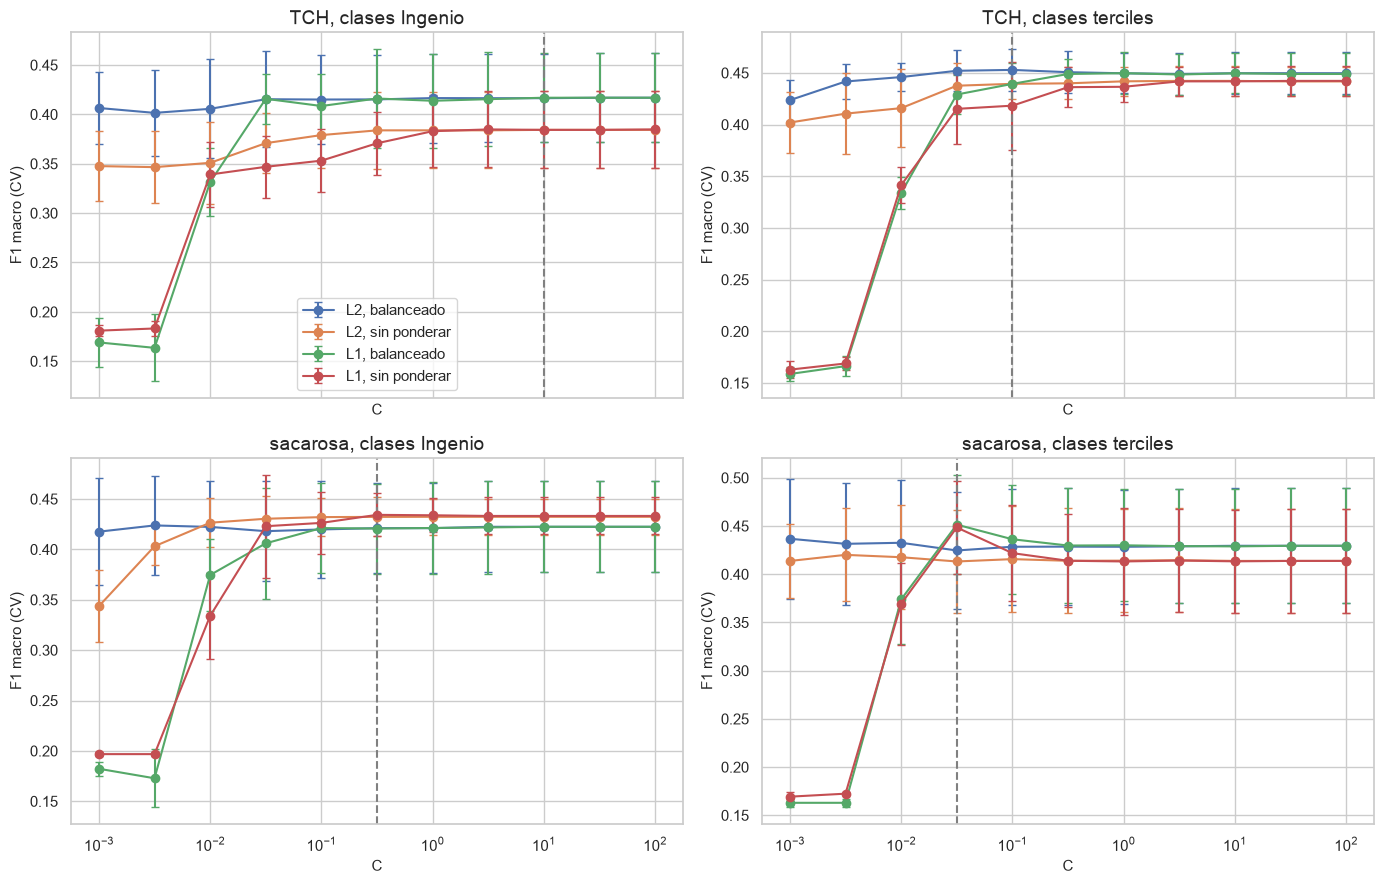

In [156]:
# 14.2 F1 macro de validación cruzada frente a C, por regularización y ponderación de clases
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (caso, busqueda) in zip(axes.ravel(), busquedas_log.items()):
    res = pd.DataFrame(busqueda.cv_results_)
    for (l1, cw), grupo in res.groupby(["param_modelo__l1_ratio", "param_modelo__class_weight"],
                                       dropna=False):
        etiqueta = f"{'L1' if l1 == 1 else 'L2'}, {'balanceado' if cw == 'balanced' else 'sin ponderar'}"
        ax.errorbar(grupo["param_modelo__C"].astype(float), grupo["mean_test_f1_macro"],
                    yerr=grupo["std_test_f1_macro"], marker="o", capsize=3, label=etiqueta)
    elegido = busqueda.cv_results_["param_modelo__C"][busqueda.best_index_]
    ax.axvline(float(elegido), color="gray", linestyle="--")
    ax.set(xscale="log", title=f"{caso[0]}, clases {caso[1]}", xlabel="C", ylabel="F1 macro (CV)")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [157]:
# 14.2 Mejor combinación con L1 y con L2 en cada caso
metricas_comparacion = ["f1_macro", "prec_bajo", "sens_bajo", "kappa", "auc_macro", "auc_bajo"]

filas = {}
for caso, busqueda in busquedas_log.items():
    res = pd.DataFrame(busqueda.cv_results_)
    for l1, grupo in res.groupby("param_modelo__l1_ratio"):
        mejor = grupo.loc[grupo["mean_test_f1_macro"].idxmax()]
        filas[(*caso, "L1" if l1 == 1 else "L2")] = {
            "C": mejor["param_modelo__C"],
            "class_weight": mejor["param_modelo__class_weight"],
            **{m: f"{mejor[f'mean_test_{m}']:.3f} ± {mejor[f'std_test_{m}']:.3f}"
               for m in metricas_comparacion},
        }

tabla_l1_l2 = pd.DataFrame(filas).T
tabla_l1_l2.index.names = ["Target", "Clases", "Regularización"]
display(tabla_l1_l2)

C class_weight       f1_macro  \
Target   Clases   Regularización                                          
TCH      Ingenio  L2              31.622777     balanced  0.417 ± 0.045   
                  L1                   10.0     balanced  0.417 ± 0.045   
         terciles L2                    0.1     balanced  0.453 ± 0.020   
                  L1                    1.0     balanced  0.450 ± 0.020   
sacarosa Ingenio  L2                    1.0          NaN  0.432 ± 0.018   
                  L1               0.316228          NaN  0.434 ± 0.021   
         terciles L2                  0.001     balanced  0.437 ± 0.062   
                  L1               0.031623     balanced  0.451 ± 0.052   

                                      prec_bajo      sens_bajo          kappa  \
Target   Clases   Regularización                                                
TCH      Ingenio  L2              0.326 ± 0.035  0.483 ± 0.102  0.146 ± 0.068   
                  L1              0.326 ± 0.035  0.483 ± 0.102  0.146 ± 0.068   
         terciles L2              0.461 ± 0.032  0.480 ± 0.115  0.193 ± 0.024   
                  L1              0.456 ± 0.030  0.482 ± 0.112  0.188 ± 0.024   
sacarosa Ingenio  L2              0.426 ± 0.085  0.280 ± 0.090  0.175 ± 0.047   
                  L1              0.429 ± 0.079  0.274 ± 0.086  0.180 ± 0.048   
         terciles L2              0.515 ± 0.074  0.616 ± 0.217  0.210 ± 0.071   
                  L1              0.569 ± 0.081  0.571 ± 0.171  0.228 ± 0.055   

                                      auc_macro       auc_bajo  
Target   Clases   Regularización                                
TCH      Ingenio  L2              0.609 ± 0.045  0.634 ± 0.029  
                  L1              0.609 ± 0.045  0.634 ± 0.029  
         terciles L2              0.633 ± 0.018  0.641 ± 0.032  
                  L1              0.634 ± 0.018  0.642 ± 0.032  
sacarosa Ingenio  L2              0.659 ± 0.035  0.730 ± 0.042  
                  L1              0.661 ± 0.036  0.732 ± 0.042  
         terciles L2              0.661 ± 0.036  0.728 ± 0.054  
                  L1              0.659 ± 0.027  0.727 ± 0.045

### Conclusión de 14.2

Combinación elegida en cada caso:

| Target | Clases | C | Regularización | Ponderación | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | 10 | L1 | Balanceada | 0.417 ± 0.045 | 0.326 ± 0.035 | 0.483 ± 0.102 | 0.146 ± 0.068 | 0.609 ± 0.045 | 0.634 ± 0.029 |
| TCH | Terciles | 0.1 | L2 | Balanceada | 0.453 ± 0.020 | 0.461 ± 0.032 | 0.480 ± 0.115 | 0.193 ± 0.024 | 0.633 ± 0.018 | 0.641 ± 0.032 |
| Sacarosa | Ingenio | 0.316 | L1 | Sin ponderar | 0.434 ± 0.021 | 0.429 ± 0.079 | 0.274 ± 0.086 | 0.180 ± 0.048 | 0.661 ± 0.036 | 0.732 ± 0.042 |
| Sacarosa | Terciles | 0.032 | L1 | Balanceada | 0.451 ± 0.052 | 0.569 ± 0.081 | 0.571 ± 0.171 | 0.228 ± 0.055 | 0.659 ± 0.027 | 0.727 ± 0.045 |

**Desempeño frente a las referencias**

- La regresión logística supera a los clasificadores de referencia en los cuatro casos. El F1 macro sube
  de 0.324–0.332 a 0.417–0.453, el kappa de prácticamente 0 a 0.146–0.228 y el AUC macro de 0.5 a
  0.609–0.661. La mejora es mayor que la desviación entre pliegues (0.020 a 0.052 en F1 macro), así que
  no se debe a la variación de la partición.
- Los valores de kappa indican un acuerdo leve en tres casos (0.146 a 0.193) y aceptable en sacarosa por
  terciles (0.228), en el límite inferior de esa categoría. Los predictores disponibles antes de la
  cosecha permiten distinguir las clases en periodos no vistos, pero explican una parte limitada del
  resultado.
- La desviación entre pliegues es alta en algunas métricas, en especial la sensibilidad de la clase baja
  (hasta ± 0.171 en sacarosa por terciles). Cada pliegue de validación reúne unos 11 periodos, y el
  desempeño cambia según los meses y años que le correspondan.
- En F1 macro los dos targets quedan en niveles parecidos, pero la clase baja de sacarosa se ordena
  mejor según su riesgo que la de TCH (AUC de la clase baja de 0.732 y 0.727, frente a 0.634 y 0.641).

**Efecto de los hiperparámetros**

- En TCH y en sacarosa con umbrales del Ingenio, el F1 macro se estabiliza a partir de C ≈ 0.03–0.1 y se
  mantiene prácticamente igual hasta C = 100. La elección no depende de un valor preciso de `C`. En TCH
  con umbrales del Ingenio se eligió C = 10, lo que equivale a una penalización muy débil.
- En sacarosa por terciles, L1 alcanza su mayor F1 macro con una penalización fuerte (C = 0.032) y
  desciende a cerca de 0.43 para valores mayores de `C`. Una penalización fuerte, que anula más
  coeficientes, generaliza algo mejor a periodos no vistos, aunque la diferencia queda dentro de la
  variación entre pliegues.
- Con C de 0.001 y 0.003, la regularización L1 anula todos los coeficientes y el F1 macro cae a
  0.16–0.18, el nivel del clasificador de la clase más frecuente. La regularización L2 conserva un
  desempeño cercano al de la zona estable, porque reduce los coeficientes sin anularlos.
- La ponderación balanceada mejora el F1 macro en TCH con umbrales del Ingenio en cerca de 0.03 en toda la
  zona estable. En los otros casos, las curvas con y sin ponderación quedan cerca, dentro de sus barras
  de error.

**L1 frente a L2**

| Target | Clases | Regularización | C | Ponderación | F1 macro | Sensibilidad bajo | Kappa | AUC bajo |
|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | L1 | 10 | Balanceada | 0.417 ± 0.045 | 0.483 ± 0.102 | 0.146 ± 0.068 | 0.634 ± 0.029 |
| TCH | Ingenio | L2 | 31.6 | Balanceada | 0.417 ± 0.045 | 0.483 ± 0.102 | 0.146 ± 0.068 | 0.634 ± 0.029 |
| TCH | Terciles | L1 | 1.0 | Balanceada | 0.450 ± 0.020 | 0.482 ± 0.112 | 0.188 ± 0.024 | 0.642 ± 0.032 |
| TCH | Terciles | L2 | 0.1 | Balanceada | 0.453 ± 0.020 | 0.480 ± 0.115 | 0.193 ± 0.024 | 0.641 ± 0.032 |
| Sacarosa | Ingenio | L1 | 0.316 | Sin ponderar | 0.434 ± 0.021 | 0.274 ± 0.086 | 0.180 ± 0.048 | 0.732 ± 0.042 |
| Sacarosa | Ingenio | L2 | 1.0 | Sin ponderar | 0.432 ± 0.018 | 0.280 ± 0.090 | 0.175 ± 0.047 | 0.730 ± 0.042 |
| Sacarosa | Terciles | L1 | 0.032 | Balanceada | 0.451 ± 0.052 | 0.571 ± 0.171 | 0.228 ± 0.055 | 0.727 ± 0.045 |
| Sacarosa | Terciles | L2 | 0.001 | Balanceada | 0.437 ± 0.062 | 0.616 ± 0.217 | 0.210 ± 0.071 | 0.728 ± 0.054 |

- En tres casos, la diferencia de F1 macro entre L1 y L2 va de 0.000 a 0.003, muy por debajo de la
  desviación entre pliegues. En TCH con umbrales del Ingenio las métricas son idénticas: con C de 10 y
  31.6 la penalización es tan débil que los dos modelos prácticamente coinciden. En TCH por terciles se
  eligió L2 por una diferencia de 0.003.
- En sacarosa por terciles, L1 supera a L2 por 0.014, que también queda dentro de la variación entre
  pliegues. La mejor combinación con L2 usa la penalización más fuerte de la grilla (C = 0.001).
- En desempeño, las dos regularizaciones son equivalentes. L1 tiene la ventaja de anular los
  coeficientes de los predictores menos útiles, lo que facilita la interpretación. Cuáles se conservan se
  analiza en 14.3.
- La mejor combinación con L2 usa la misma ponderación que la de L1 en los cuatro casos, así que la
  ponderación elegida no depende del tipo de regularización.

**Detección de la clase baja**

- En sacarosa con umbrales del Ingenio, tanto la mejor combinación con L1 como la mejor con L2 son sin
  ponderar. El modelo detecta solo el 27.4 % de las cosechas bajas, aunque las ordena según su riesgo
  mejor que los casos de TCH (AUC de la clase baja de 0.732). El modelo identifica qué cosechas tienen más
  probabilidad de ser bajas, pero pocas veces esa probabilidad supera a la de las otras dos clases.
  Bajar el umbral a partir del cual una cosecha se clasifica como baja podría aumentar su detección, lo
  que se analiza en la sección 17.

**Definiciones de clase**

- Las clases por terciles obtienen un F1 macro algo mayor que los umbrales del Ingenio (0.036 en TCH y
  0.017 en sacarosa), pero no es una comparación directa: son problemas con clases de distinto tamaño y
  distintas fronteras.

### 14.3 Coeficientes e importancia de los predictores

En la regresión logística multinomial cada clase tiene su propio vector de coeficientes, y solo las
diferencias entre clases tienen interpretación. Para el Ingenio, la comparación relevante es entre la
clase baja y la alta:

$$\log\frac{P(\text{bajo})}{P(\text{alto})} = (b_{\text{bajo}} - b_{\text{alto}}) + \sum_j (\beta_{\text{bajo},j} - \beta_{\text{alto},j})\, z_j$$

Como los predictores están estandarizados, la diferencia $\beta_{\text{bajo},j} - \beta_{\text{alto},j}$
indica cuánto cambia el logaritmo de la razón entre la probabilidad de bajo y la de alto cuando el
predictor $j$ aumenta una desviación estándar, con los demás fijos. Un valor positivo empuja la cosecha
hacia la clase baja y uno negativo hacia la alta. Su exponencial es la razón de odds: el factor por el
que se multiplica esa razón. La magnitud de la diferencia permite comparar la importancia de los
predictores entre sí.

Para cada caso se analiza el modelo elegido en 14.2, reentrenado con todo el conjunto de entrenamiento:

- **Contraste y razón de odds** de cada columna de la matriz de diseño.
- **Columnas eliminadas:** cuando el modelo elegido usa regularización L1, aquellas cuyos coeficientes
  quedan en cero para las tres clases. Con L2 ningún coeficiente se anula.
- **Estabilidad:** el mismo modelo se reajusta en los 5 pliegues de entrenamiento de la validación
  cruzada, y se cuenta en cuántos el contraste es distinto de cero y en cuántos conserva el signo del
  modelo final. Un predictor que cambia de signo entre pliegues no tiene un efecto interpretable.
- **Desviación estándar en unidades originales,** para traducir el contraste a cambios concretos de
  cada predictor.

Los cuatro armónicos del mes representan conjuntamente el efecto de la época de cosecha, así que sus
coeficientes no se interpretan por separado. Se combinan para obtener la contribución de cada mes al
contraste entre la clase baja y la alta.

In [158]:
# 14.3 Coeficientes del modelo elegido y estabilidad de la selección entre pliegues
from sklearn.base import clone


def contraste_bajo_alto(pipeline):
    """Diferencia de coeficientes β_bajo − β_alto de cada columna de la matriz de diseño."""
    modelo = pipeline.named_steps["modelo"]
    clases = list(modelo.classes_)
    contraste = modelo.coef_[clases.index("bajo")] - modelo.coef_[clases.index("alto")]
    return pd.Series(contraste, index=pipeline.named_steps["prep"].get_feature_names_out())


def tabla_coeficientes(busqueda, col_clase):
    """Contraste del modelo final, columnas eliminadas por L1 y estabilidad en los 5 pliegues."""
    final = busqueda.best_estimator_
    nombres = final.named_steps["prep"].get_feature_names_out()
    contraste = contraste_bajo_alto(final)
    eliminada = pd.Series((final.named_steps["modelo"].coef_ == 0).all(axis=0), index=nombres)

    # Mismo modelo reajustado en cada pliegue de entrenamiento de la validación cruzada
    X, y, grupos = datos_caso(col_clase, df_train)
    res = cross_validate(clone(final), X, y, groups=grupos, cv=cv, scoring="f1_macro",
                         return_estimator=True)
    por_pliegue = pd.DataFrame([contraste_bajo_alto(e) for e in res["estimator"]])

    tabla = pd.DataFrame({
        "β_bajo − β_alto": contraste.round(3),
        "Razón de odds": np.exp(contraste).round(2),
        "Eliminada por L1": eliminada,
        "Pliegues ≠ 0": (por_pliegue != 0).sum(),
        "Pliegues con el mismo signo": (np.sign(por_pliegue) == np.sign(contraste)).sum()
                                       .where(contraste != 0),
        "1 DE (unidades originales)": pd.Series(final.named_steps["prep"].named_steps["escalado"].scale_,
                                                index=nombres).round(2),
    })
    return tabla.sort_values("β_bajo − β_alto", key=np.abs, ascending=False)


tablas_coef = {caso: tabla_coeficientes(busquedas_log[caso], col) for caso, col in casos.items()}
for (tgt, defin), tabla in tablas_coef.items():
    print(f"\n{tgt}, clases {defin}: {tabla['Eliminada por L1'].sum()} de {len(tabla)} columnas eliminadas")
    display(tabla)


TCH, clases Ingenio: 0 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
grupo_tenencia_3,-0.631,0.53,False,5,5,0.50
cortes,0.399,1.49,False,5,5,1.63
anio,0.289,1.34,False,5,5,1.35
lluvia_sin_dato,0.234,1.26,False,5,5,0.47
pct_diatrea,-0.232,0.79,False,5,5,2.53
mes_cos_6,0.176,1.19,False,5,5,0.72
semsmad,0.164,1.18,False,5,5,3.53
lluvias,-0.144,0.87,False,5,5,121.80
edad,-0.133,0.88,False,5,5,1.15
dosismad,-0.126,0.88,False,5,5,0.25



TCH, clases terciles: 0 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
grupo_tenencia_3,-0.514,0.60,False,5,5,0.50
cortes,0.424,1.53,False,5,5,1.63
anio,0.313,1.37,False,5,5,1.35
edad,-0.213,0.81,False,5,5,1.15
pct_diatrea,-0.207,0.81,False,5,5,2.53
lluvia_sin_dato,0.162,1.18,False,5,5,0.47
semsmad,0.154,1.17,False,5,5,3.53
mes_cos_6,0.143,1.15,False,5,5,0.72
mes_cos_12,0.133,1.14,False,5,4,0.73
dosismad,-0.109,0.90,False,5,5,0.25



sacarosa, clases Ingenio: 0 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
mes_cos_12,-0.711,0.49,False,5,5,0.73
mes_cos_6,0.638,1.89,False,5,5,0.72
lluvias,0.636,1.89,False,5,5,121.70
semsmad,-0.332,0.72,False,5,5,3.53
pct_diatrea,0.222,1.25,False,5,5,2.53
mes_sin_6,0.217,1.24,False,5,5,0.69
mes_sin_12,0.208,1.23,False,5,5,0.67
grupo_tenencia_2,-0.122,0.89,False,5,5,0.46
grupo_tenencia_3,0.092,1.10,False,5,4,0.50
anio,-0.081,0.92,False,5,5,1.35



sacarosa, clases terciles: 4 de 14 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
mes_cos_12,-0.610,0.54,False,5,5.0,0.73
mes_cos_6,0.486,1.63,False,5,5.0,0.72
lluvias,0.436,1.55,False,5,5.0,121.70
semsmad,-0.221,0.80,False,5,5.0,3.53
mes_sin_12,0.137,1.15,False,5,5.0,0.67
mes_sin_6,0.095,1.10,False,4,4.0,0.69
grupo_tenencia_2,-0.078,0.93,False,4,4.0,0.46
pct_diatrea,0.076,1.08,False,4,4.0,2.53
lluvia_sin_dato,0.027,1.03,False,4,4.0,0.47
grupo_tenencia_3,0.026,1.03,False,2,2.0,0.50


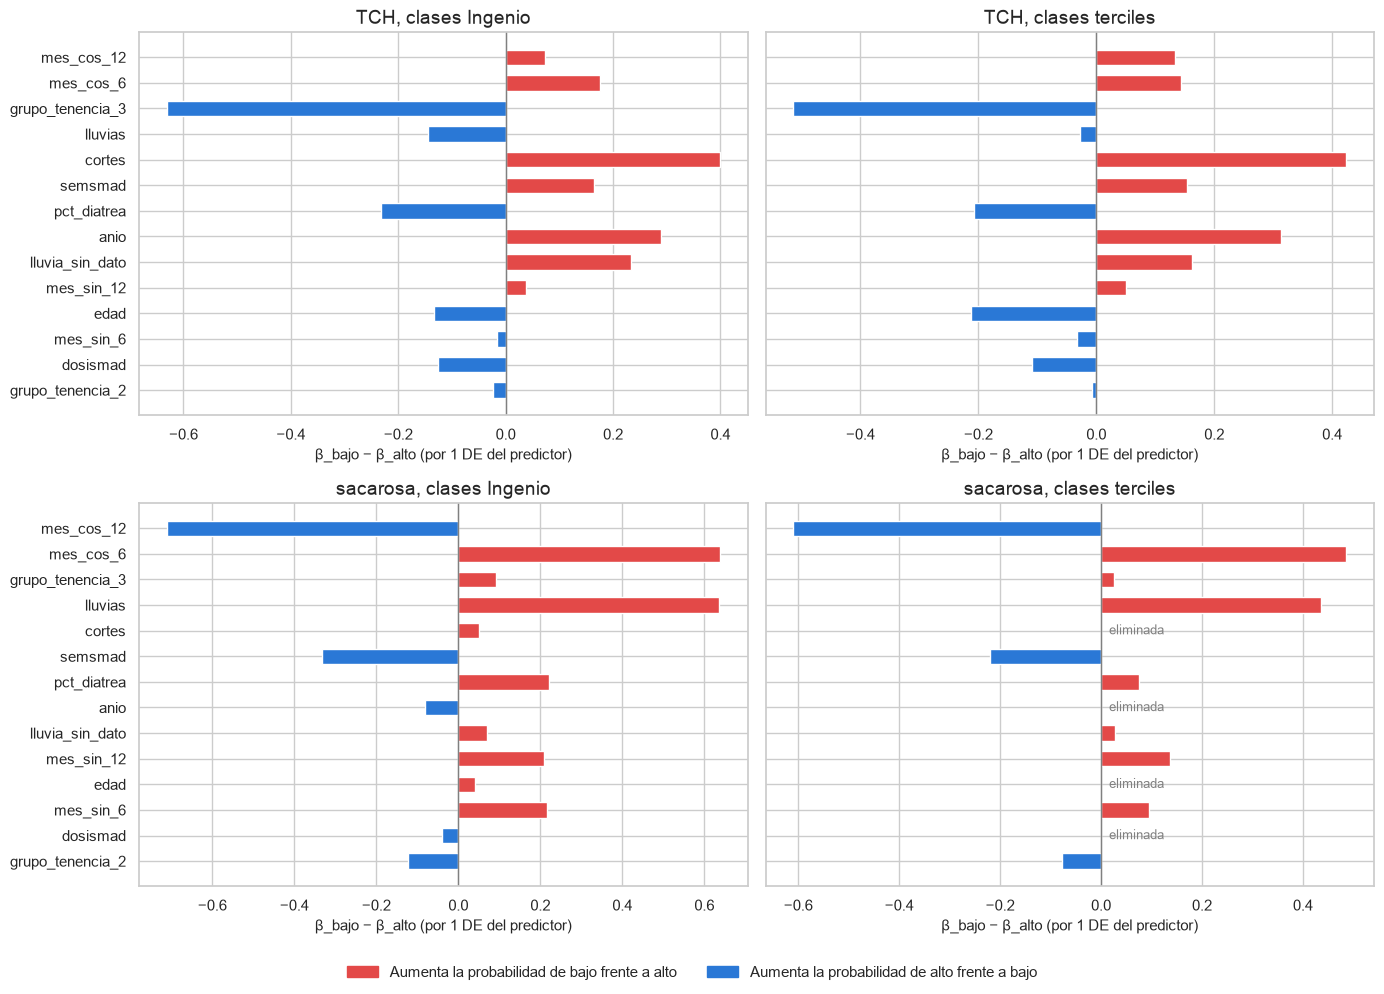

In [159]:
# 14.3 Contraste β_bajo − β_alto de cada predictor, por caso
COLOR_BAJO, COLOR_ALTO = "#e34948", "#2a78d6"  # hacia la clase baja / hacia la clase alta

# Mismo orden de predictores en los cuatro paneles: de mayor a menor contraste absoluto promedio
orden = (pd.DataFrame({caso: t["β_bajo − β_alto"] for caso, t in tablas_coef.items()})
         .abs().mean(axis=1).sort_values().index)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
for ax, ((tgt, defin), tabla) in zip(axes.ravel(), tablas_coef.items()):
    valores = tabla.loc[orden, "β_bajo − β_alto"]
    colores = np.where(valores > 0, COLOR_BAJO, COLOR_ALTO)
    ax.barh(orden, valores, color=colores, height=0.6)
    for pos, nombre in enumerate(orden):
        if tabla.loc[nombre, "Eliminada por L1"]:
            ax.text(0, pos, "  eliminada", va="center", fontsize=9, color="gray")
    ax.axvline(0, color="gray", linewidth=1)
    ax.set(title=f"{tgt}, clases {defin}", xlabel="β_bajo − β_alto (por 1 DE del predictor)")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=COLOR_BAJO),
                    plt.Rectangle((0, 0), 1, 1, color=COLOR_ALTO)],
           labels=["Aumenta la probabilidad de bajo frente a alto",
                   "Aumenta la probabilidad de alto frente a bajo"],
           loc="lower center", ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

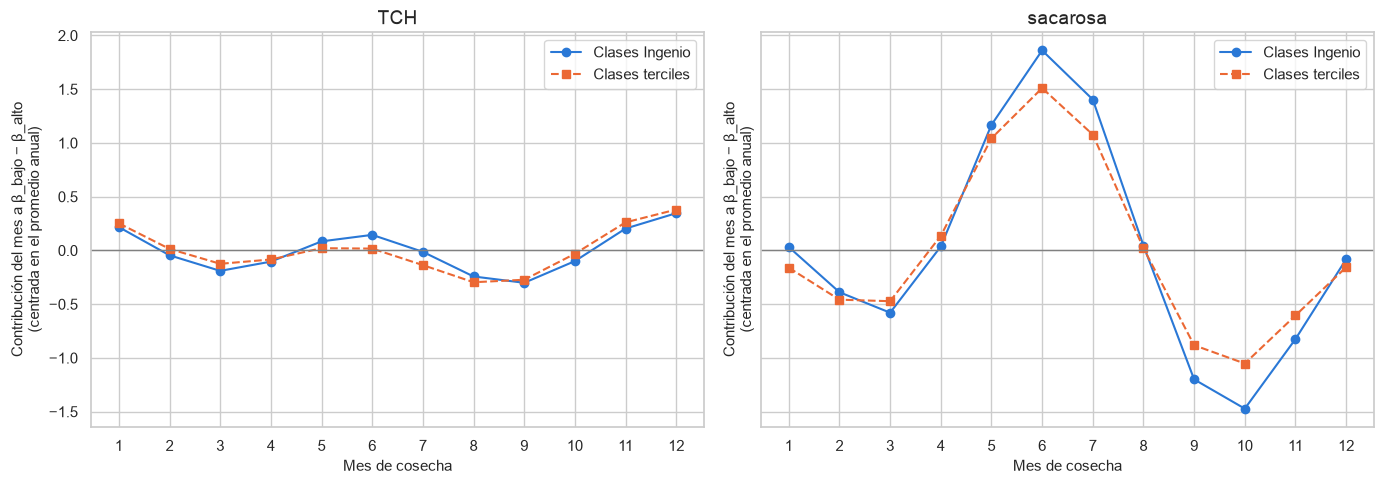

In [160]:
# 14.3 Efecto conjunto del mes de cosecha sobre el contraste bajo frente a alto
meses = np.arange(1, 13)
armonicos = pd.DataFrame({
    "mes_sin_12": np.sin(2 * np.pi * meses / 12), "mes_cos_12": np.cos(2 * np.pi * meses / 12),
    "mes_sin_6": np.sin(4 * np.pi * meses / 12), "mes_cos_6": np.cos(4 * np.pi * meses / 12),
}, index=meses)
estilos = {"Ingenio": ("#2a78d6", "o", "-"), "terciles": ("#eb6834", "s", "--")}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, tgt in zip(axes, ["TCH", "sacarosa"]):
    for defin, (color, marcador, linea) in estilos.items():
        final = busquedas_log[(tgt, defin)].best_estimator_
        escalado = final.named_steps["prep"].named_steps["escalado"]
        nombres = list(final.named_steps["prep"].get_feature_names_out())
        idx = [nombres.index(c) for c in predictores_mes]
        # Armónicos estandarizados con la media y la desviación de entrenamiento
        z = (armonicos[predictores_mes] - escalado.mean_[idx]) / escalado.scale_[idx]
        efecto = z @ contraste_bajo_alto(final)[predictores_mes].to_numpy()
        ax.plot(meses, efecto - efecto.mean(), linea, marker=marcador, color=color,
                label=f"Clases {defin}")
    ax.axhline(0, color="gray", linewidth=1)
    ax.set(title=tgt, xlabel="Mes de cosecha", xticks=meses,
           ylabel="Contribución del mes a β_bajo − β_alto\n(centrada en el promedio anual)")
    ax.legend()
plt.tight_layout()
plt.show()

### Conclusión de 14.3

**Cómo leer las tablas**

Cada tabla compara la clase baja con la alta. El contraste $\beta_{\text{bajo}} - \beta_{\text{alto}}$
indica hacia qué clase empuja cada predictor: si es positivo, valores más altos del predictor hacen más
probable la clase baja; si es negativo, la alta. La razón de odds es la exponencial del contraste, y dice
por cuánto se multiplica la razón entre la probabilidad de bajo y la de alto cuando el predictor aumenta
en la cantidad indicada en la columna "Aumento de referencia". Esa cantidad es una desviación estándar
del predictor en el conjunto de entrenamiento, expresada en sus unidades originales.

Por ejemplo, `cortes` en TCH tiene una razón de odds de 1.49 con un aumento de referencia de 1.6 cortes:
si dos cosechas son iguales en todo, salvo que una tiene 1.6 cortes más, la razón entre su probabilidad
de TCH bajo y su probabilidad de TCH alto es 1.49 veces la de la otra. Una razón de odds de 1 indica que
el predictor no distingue la clase baja de la alta. Por debajo de 1, el predictor empuja hacia la clase
alta. Como todos los contrastes están en la misma escala, su magnitud permite comparar la importancia de
predictores medidos en unidades distintas.

En las indicadoras (`grupo_tenencia` y `lluvia_sin_dato`) el aumento de referencia no tiene una lectura
natural, porque la variable solo vale 0 o 1. En ellas se interpretan el signo y la magnitud relativa. Los
armónicos del mes se interpretan juntos, con la curva de la contribución de cada mes.

**Selección de variables y estabilidad**

- Solo el modelo de sacarosa por terciles elimina columnas: con una penalización fuerte (C = 0.032), L1
  anula `edad`, `cortes`, `dosismad` y `anio`. En TCH con umbrales del Ingenio y en sacarosa con umbrales
  del Ingenio, L1 no elimina ninguna, y en TCH por terciles se eligió L2, que no anula coeficientes. La
  importancia de cada predictor se lee en la magnitud de su contraste y en su estabilidad entre pliegues.
- Los predictores principales mantienen su signo en los 5 pliegues en los cuatro casos. Los que cambian
  de signo o no aparecen en todos los pliegues, en al menos una de las dos definiciones de clase, tienen
  contrastes de 0.133 o menos en valor absoluto. En TCH son tres de los armónicos del mes y
  `grupo_tenencia_2`. En sacarosa son `edad`, `dosismad` y `grupo_tenencia_3` y, con terciles, también
  `anio`, `pct_diatrea`, `lluvia_sin_dato`, `grupo_tenencia_2` y `mes_sin_6`. Su efecto no es
  interpretable.
- Las dos definiciones de clase identifican los mismos predictores principales en cada target, con los
  mismos signos y un orden de importancia similar. Las conclusiones sobre los predictores no dependen de
  cómo se definan las clases.

**TCH**

| Predictor | Razón de odds (Ingenio / terciles) | Aumento de referencia | Lectura |
|---|---|---|---|
| `cortes` | 1.49 / 1.53 | 1.6 cortes | Más cortes, más probable el TCH bajo |
| `anio` | 1.34 / 1.37 | 1.4 años | Cosechas más recientes, más probable el TCH bajo |
| `lluvia_sin_dato` | 1.26 / 1.18 | Indicadora | Sin lluvia medida, más probable el TCH bajo |
| `semsmad` | 1.18 / 1.17 | 3.5 semanas | Más semanas desde el madurante, más probable el TCH bajo |
| `edad` | 0.88 / 0.81 | 1.2 meses | Mayor edad, más probable el TCH alto |
| `pct_diatrea` | 0.79 / 0.81 | 2.5 puntos % | Más daño por *Diatraea*, más probable el TCH alto |
| `dosismad` | 0.88 / 0.90 | 0.25 L/ha | Mayor dosis de madurante, más probable el TCH alto |
| `lluvias` | 0.87 / 0.97 | 122 mm | Más lluvia, más probable el TCH alto (solo con umbrales del Ingenio) |
| `grupo_tenencia_3` | 0.53 / 0.60 | Indicadora | El código 3 hace más probable el TCH alto que el código 1 |

Predictores con una explicación agronómica coherente:

- **`cortes`** tiene el mayor efecto hacia la clase baja: cada 1.6 cortes adicionales multiplican por
  cerca de 1.5 la razón entre la probabilidad de TCH bajo y la de alto. Es coherente con la pérdida de
  productividad de la cepa a medida que acumula cortes.
- **`edad`** empuja hacia la clase alta: una cosecha más tardía tuvo más tiempo para acumular biomasa.
- **`semsmad`** empuja hacia la clase baja. El madurante frena el crecimiento vegetativo para que la
  planta acumule sacarosa, así que una exposición más larga puede reducir el tonelaje.
- **`lluvias`** empuja hacia la clase alta con umbrales del Ingenio, lo que es coherente con el papel del
  agua en el crecimiento de la caña. Con terciles su efecto es casi nulo (0.97), así que es un efecto débil.

Predictores sin una explicación agronómica directa:

- **`anio`** empuja hacia la clase baja: las cosechas más recientes del periodo 2014 a 2021 tienen mayor
  probabilidad de TCH bajo. Es una tendencia en el tiempo cuya causa no está en los datos, y su uso
  para cosechas futuras se evalúa en la sección 16.
- **`lluvia_sin_dato`** empuja hacia la clase baja: las cosechas sin lluvia medida tienden a tener TCH
  bajo. La bandera marca el vacío de medición climática, que se concentra en ciertos años, así que puede
  recoger parte de la misma tendencia temporal que `anio`.
- **`grupo_tenencia_3`** empuja hacia la clase alta frente al código 1, pero el significado de los
  códigos no está documentado, así que el efecto no se puede atribuir a una forma de tenencia. En el EDA,
  el código 3 mostró una dosis mediana de madurante menor, lo que sugiere un manejo distinto.
- **`pct_diatrea`** empuja hacia la clase alta, cuando se esperaría que más daño por *Diatraea* redujera
  el tonelaje. Como se mide en la cosecha, podría reflejar condiciones del cultivo asociadas a mayor
  biomasa, pero con estos datos no se puede verificar.
- **`dosismad`** empuja hacia la clase alta con un efecto pequeño. Se esperaría lo contrario si el
  madurante reduce el tonelaje, igual que con `semsmad`. La dosis varía poco en este dataset (0.25 L/ha
  en una desviación estándar), así que su efecto se estima con poca información.

El mes de cosecha:

- Tiene un efecto pequeño en TCH: su contribución al contraste va de cerca de −0.3 en agosto y
  septiembre a 0.4 en diciembre.

**Sacarosa**

| Predictor | Razón de odds (Ingenio / terciles) | Aumento de referencia | Lectura |
|---|---|---|---|
| `lluvias` | 1.89 / 1.55 | 122 mm | Más lluvia, más probable la sacarosa baja |
| `pct_diatrea` | 1.25 / 1.08 | 2.5 puntos % | Más daño por *Diatraea*, más probable la sacarosa baja |
| `semsmad` | 0.72 / 0.80 | 3.5 semanas | Más semanas desde el madurante, más probable la sacarosa alta |
| `grupo_tenencia_2` | 0.89 / 0.93 | Indicadora | El código 2 hace algo más probable la sacarosa alta que el código 1 |
| Mes de cosecha | Ver gráfica | — | Mayo a julio, más probable la sacarosa baja; septiembre a noviembre, la alta |

Predictores con una explicación agronómica coherente:

- **`lluvias`** es el predictor continuo más importante: cada 122 mm adicionales multiplican por 1.89
  (umbrales del Ingenio) y 1.55 (terciles) la razón entre la probabilidad de sacarosa baja y la de alta.
  Es coherente con el efecto de la lluvia sobre la maduración: el agua estimula el crecimiento y diluye
  la sacarosa acumulada.
- **`semsmad`** empuja hacia la clase alta: más semanas entre la aplicación del madurante y la cosecha
  dan más tiempo para que el madurante actúe.
- **`pct_diatrea`** empuja hacia la clase baja: el daño por *Diatraea* se asocia con menor sacarosa, lo
  que es coherente con el deterioro de los tallos perforados. Con terciles el efecto es débil (1.08) y no
  aparece en todos los pliegues.

El mes de cosecha:

- Tiene el efecto más fuerte de todos los predictores. Su contribución al contraste va de −1.5 en
  octubre a 1.9 en junio con umbrales del Ingenio, y de −1.1 a 1.5 con terciles: las cosechas de mayo a
  julio tienden a la clase baja, y las de septiembre a noviembre, y en menor medida las de febrero y
  marzo, a la alta.
- Este efecto se suma al de `lluvias`, así que no se explica solo por la lluvia registrada. Podría
  reflejar las condiciones de las semanas previas a la cosecha, en las que se completa la maduración.

Predictores sin efecto:

- `edad`, `anio`, `cortes` y `dosismad` tienen contrastes cercanos a cero con umbrales del Ingenio, y L1
  los elimina con terciles. La sacarosa no muestra tendencia entre años. La dosis de madurante no
  distingue la clase baja de la alta, aunque en este dataset todas las suertes fueron maduradas y la
  dosis varía poco, así que el rango observado puede ser demasiado estrecho para que su efecto se
  manifieste.

**TCH frente a sacarosa**

- Los predictores más importantes son distintos para cada target. TCH depende sobre todo del estado de
  la cepa y del cultivo (`cortes`, `edad`, `grupo_tenencia`) y de una tendencia en el tiempo (`anio`,
  `lluvia_sin_dato`), y la sacarosa de las condiciones de maduración (`lluvias`, mes de cosecha,
  `semsmad`). Esto confirma que conviene tratarlos como dos problemas independientes.
- `semsmad` tiene signos opuestos en los dos targets: más tiempo de acción del madurante favorece la
  sacarosa y se asocia con menor tonelaje.

### Conclusión de la sección 14

- La regresión logística multinomial supera a los clasificadores de referencia en los cuatro casos, en
  periodos que no vio durante el entrenamiento. Su F1 macro va de 0.417 a 0.453, frente a un máximo de
  0.332 sin predictores, y su kappa de 0.146 a 0.228, frente a prácticamente 0. El acuerdo es leve o
  apenas aceptable: los predictores disponibles antes de la cosecha distinguen las clases, pero explican
  una parte limitada del resultado.
- En F1 macro los dos targets quedan en niveles parecidos, pero la clase baja de sacarosa se ordena mejor
  según su riesgo que la de TCH (AUC de 0.73 frente a 0.64). En sacarosa con umbrales del Ingenio, con la
  regla de la clase más probable, el modelo detecta solo el 27.4 % de las cosechas bajas.
- El desempeño es estable en un rango amplio de regularización, y L1 y L2 son equivalentes en desempeño.
  Solo en sacarosa por terciles una penalización fuerte, que elimina cuatro predictores, generaliza algo
  mejor, dentro de la variación entre pliegues.
- Los predictores principales son distintos para cada target: `cortes`, `edad`, `grupo_tenencia` y una
  tendencia en el tiempo (`anio` y `lluvia_sin_dato`) en TCH, y `lluvias`, el mes de cosecha y `semsmad`
  en sacarosa. Son los mismos con las dos definiciones de clase, y la mayoría tiene una explicación
  agronómica coherente. Las excepciones (`pct_diatrea` y `dosismad` en TCH, y la tendencia temporal)
  quedan identificadas como efectos sin una explicación directa.
- Los modelos elegidos en esta sección se evalúan en el conjunto de prueba en la sección 17, junto con
  los de KNN.

## 15. KNN

KNN (k vecinos más cercanos) clasifica cada cosecha según las clases de las k cosechas de entrenamiento
más parecidas. Estima la probabilidad de cada clase como la proporción de vecinos que pertenecen a ella:

$$\hat P(\text{clase } c \mid x) = \frac{\sum_{i \in N_k(x)} w_i \, \mathbb{1}(y_i = c)}{\sum_{i \in N_k(x)} w_i}$$

donde $N_k(x)$ son los k vecinos más cercanos a $x$ según la distancia euclidiana sobre los predictores
estandarizados, y $w_i$ es el peso de cada vecino: igual para todos (ponderación uniforme) o inversamente
proporcional a su distancia (ponderación por distancia).

KNN complementa a la regresión logística en tres aspectos:

- **Fronteras no lineales.** No supone que el efecto de cada predictor sea lineal ni aditivo, así que
  puede capturar interacciones, por ejemplo entre lluvias y mes de cosecha.
- **Sin coeficientes.** No produce una medida directa de la importancia de cada predictor.
- **Todos los predictores pesan igual en la distancia.** La logística aprende un peso para cada
  predictor, mientras que KNN da el mismo peso a todas las columnas estandarizadas, incluidas las que
  aportan poca información. Por eso es sensible a la selección de predictores, lo que se evalúa en la
  sección 16.

KNN no tiene un equivalente a la ponderación de clases de la logística, así que la clase baja, que es la
más pequeña con los umbrales del Ingenio, no recibe un peso adicional.

La sección tiene tres partes: la búsqueda de hiperparámetros (15.1), la sensibilidad del desempeño a la
agrupación de los pliegues de la validación cruzada (15.2) y la comparación con la regresión logística
(15.3).

### 15.1 Búsqueda de hiperparámetros

Se buscan dos hiperparámetros con la misma validación cruzada, las mismas métricas y el mismo criterio
de elección que en la regresión logística (mayor F1 macro):

- **`n_neighbors` (k):** valores impares de 1 a 51, para evitar empates entre clases con ponderación
  uniforme. Un k pequeño produce fronteras muy irregulares que se ajustan al ruido de los datos de
  entrenamiento; un k grande las suaviza, pero puede borrar diferencias reales entre clases.
- **`weights`:** ponderación uniforme o por distancia.

La gráfica muestra el F1 macro de validación cruzada frente a k para cada ponderación, con una banda de
± una desviación estándar entre pliegues. Si el k elegido queda en el extremo de la grilla, el rango
explorado sería insuficiente.

In [161]:
# 15.1 Búsqueda de hiperparámetros de KNN
from sklearn.neighbors import KNeighborsClassifier

grilla_knn = {
    "modelo__n_neighbors": list(range(1, 52, 2)),  # k impar de 1 a 51
    "modelo__weights": ["uniform", "distance"],
}

busquedas_knn = {caso: buscar(KNeighborsClassifier(), grilla_knn, col) for caso, col in casos.items()}

tabla_knn = pd.DataFrame({caso: resumen_busqueda(b) for caso, b in busquedas_knn.items()}).T
tabla_knn.index.names = ["Target", "Clases"]
display(tabla_knn)

n_neighbors   weights      exactitud     prec_macro  \
Target   Clases                                                         
TCH      Ingenio           13   uniform  0.427 ± 0.027  0.399 ± 0.033   
         terciles          25  distance  0.458 ± 0.018  0.454 ± 0.012   
sacarosa Ingenio           33  distance  0.489 ± 0.010  0.460 ± 0.029   
         terciles          39  distance  0.482 ± 0.023  0.489 ± 0.036   

                      sens_macro       f1_macro      prec_bajo      sens_bajo  \
Target   Clases                                                                 
TCH      Ingenio   0.391 ± 0.023  0.383 ± 0.025  0.318 ± 0.088  0.163 ± 0.054   
         terciles  0.454 ± 0.015  0.450 ± 0.015  0.454 ± 0.041  0.490 ± 0.072   
sacarosa Ingenio   0.448 ± 0.019  0.434 ± 0.037  0.416 ± 0.057  0.276 ± 0.065   
         terciles  0.481 ± 0.023  0.464 ± 0.030  0.560 ± 0.113  0.566 ± 0.107   

                           kappa      auc_macro       auc_bajo  
Target   Clases                                                 
TCH      Ingenio   0.092 ± 0.040  0.558 ± 0.025  0.564 ± 0.028  
         terciles  0.183 ± 0.025  0.623 ± 0.019  0.628 ± 0.042  
sacarosa Ingenio   0.184 ± 0.025  0.642 ± 0.016  0.722 ± 0.041  
         terciles  0.223 ± 0.036  0.654 ± 0.022  0.706 ± 0.046

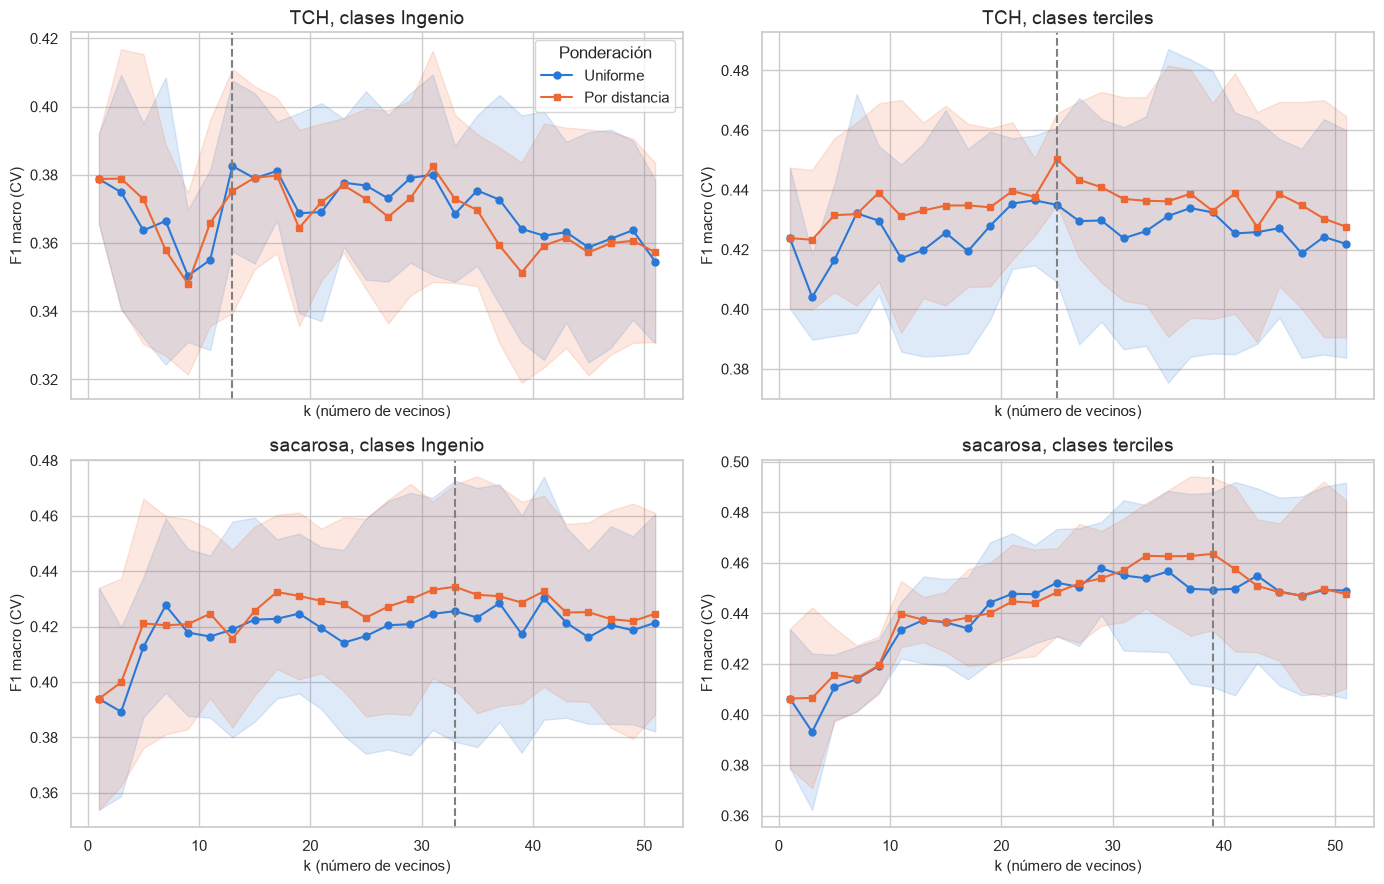

In [162]:
# 15.1 F1 macro de validación cruzada frente a k, por tipo de ponderación
estilos_knn = {"uniform": ("#2a78d6", "o", "Uniforme"), "distance": ("#eb6834", "s", "Por distancia")}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (caso, busqueda) in zip(axes.ravel(), busquedas_knn.items()):
    res = pd.DataFrame(busqueda.cv_results_)
    for peso, (color, marcador, etiqueta) in estilos_knn.items():
        grupo = res[res["param_modelo__weights"] == peso]
        k = grupo["param_modelo__n_neighbors"].astype(int)
        media, desv = grupo["mean_test_f1_macro"], grupo["std_test_f1_macro"]
        ax.plot(k, media, marker=marcador, color=color, label=etiqueta, markersize=5)
        ax.fill_between(k, media - desv, media + desv, color=color, alpha=0.15)
    k_elegido = busqueda.cv_results_["param_modelo__n_neighbors"][busqueda.best_index_]
    ax.axvline(int(k_elegido), color="gray", linestyle="--")
    ax.set(title=f"{caso[0]}, clases {caso[1]}", xlabel="k (número de vecinos)", ylabel="F1 macro (CV)")
axes[0, 0].legend(title="Ponderación")
plt.tight_layout()
plt.show()

### Conclusión de 15.1

| Target | Clases | k | Ponderación | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | 13 | Uniforme | 0.383 ± 0.025 | 0.318 ± 0.088 | 0.163 ± 0.054 | 0.092 ± 0.040 | 0.558 ± 0.025 | 0.564 ± 0.028 |
| TCH | Terciles | 25 | Por distancia | 0.450 ± 0.015 | 0.454 ± 0.041 | 0.490 ± 0.072 | 0.183 ± 0.025 | 0.623 ± 0.019 | 0.628 ± 0.042 |
| Sacarosa | Ingenio | 33 | Por distancia | 0.434 ± 0.037 | 0.416 ± 0.057 | 0.276 ± 0.065 | 0.184 ± 0.025 | 0.642 ± 0.016 | 0.722 ± 0.041 |
| Sacarosa | Terciles | 39 | Por distancia | 0.464 ± 0.030 | 0.560 ± 0.113 | 0.566 ± 0.107 | 0.223 ± 0.036 | 0.654 ± 0.022 | 0.706 ± 0.046 |

- KNN supera a los clasificadores de referencia en los cuatro casos, con un F1 macro de 0.383 a 0.464
  frente a un máximo de 0.332, y un kappa de 0.092 a 0.223.
- En TCH con umbrales del Ingenio la mejora es pequeña: el F1 macro supera al del azar estratificado
  en 0.06 y el kappa es de 0.092. El modelo detecta solo el 16.3 % de las cosechas bajas, menos que el
  azar estratificado (17.1 %), aunque con mayor precisión (0.318 frente a 0.222). La clase baja es la
  más pequeña con los umbrales del Ingenio, y KNN no tiene una ponderación de clases que compense su
  tamaño.
- Los valores de k elegidos son grandes (13 a 39). El F1 macro es menor con uno o tres vecinos y aumenta
  hasta k ≈ 10–30, sobre todo en sacarosa: la clase de una cosecha se predice mejor promediando muchas
  cosechas parecidas que tomando la de la más cercana.
- Por encima de k ≈ 10, el F1 macro varía entre 0.02 y 0.04 a lo largo de la grilla, dentro de la banda
  de una desviación estándar entre pliegues. El desempeño no depende de un valor preciso de k, y ningún
  k elegido queda en el extremo superior de la grilla.
- La ponderación por distancia obtiene un F1 macro igual o ligeramente mayor que la uniforme en tres
  casos. En TCH con umbrales del Ingenio las dos ponderaciones son prácticamente equivalentes.
- La clase baja de sacarosa se ordena según su riesgo mejor que la de TCH (AUC de la clase baja de 0.722
  y 0.706, frente a 0.564 y 0.628).

### 15.2 Sensibilidad a la agrupación de los pliegues

En la sección 11 se decidió agrupar la partición y la validación cruzada por periodo, porque las cosechas
simultáneas de una misma hacienda tienen predictores casi idénticos y clases parecidas. En esta
subsección se mide el efecto de esa decisión en los dos modelos, comparándola con una validación que
admite cosechas simultáneas en entrenamiento.

KNN clasifica cada cosecha a partir de sus vecinos más cercanos, así que es el modelo más expuesto a esa
situación: si una cosecha simultánea de la misma hacienda está disponible, probablemente sea su vecino más
cercano. Para comprobarlo, se busca el vecino más cercano de cada cosecha de entrenamiento entre las
cosechas de otras suertes, como ocurriría con una validación agrupada solo por suerte, sobre la matriz de
diseño estandarizada de 13.2. Los vecinos se clasifican según si pertenecen a la misma hacienda y al
mismo periodo, y para cada grupo se calculan la distancia mediana al vecino y el porcentaje de cosechas
que tienen la misma clase que su vecino, que se compara con la coincidencia esperada por azar.

In [163]:
# 15.2 Vecino más cercano de cada cosecha de entrenamiento entre las cosechas de otras suertes
from sklearn.metrics import pairwise_distances

# Distancias euclidianas sobre la matriz de diseño estandarizada de 13.2
distancias = pairwise_distances(X_train_prep)
suertes = df_train["suerte"].to_numpy()
distancias[suertes[:, None] == suertes[None, :]] = np.inf  # como en una validación agrupada por suerte

idx_vecino = distancias.argmin(axis=1)
vecino = df_train.iloc[idx_vecino].reset_index(drop=True)
propio = df_train.reset_index(drop=True)

misma_hacienda = (propio["FAZ"] == vecino["FAZ"]).to_numpy()
mismo_periodo = (propio["periodo"] == vecino["periodo"]).to_numpy()
relacion = pd.Series(np.select(
    [misma_hacienda & mismo_periodo, misma_hacienda, mismo_periodo],
    ["Misma hacienda y mismo periodo", "Misma hacienda, otro periodo", "Otra hacienda, mismo periodo"],
    default="Otra hacienda y otro periodo",
), name="Relación con el vecino más cercano")


def coincide(col):
    """1 si la cosecha y su vecino tienen la misma clase, 0 si no, NaN si alguna no tiene clase."""
    a, b = propio[col].astype(object), vecino[col].astype(object)
    return (a == b).astype(float).where(a.notna() & b.notna())


diagnostico = pd.DataFrame({
    "Registros": relacion.value_counts(),
    "% de registros": relacion.value_counts(normalize=True).mul(100).round(1),
    "Distancia mediana": pd.Series(distancias.min(axis=1)).groupby(relacion).median().round(2),
    "% misma clase TCH (Ingenio)": coincide("clase_tch_ingenio").groupby(relacion).mean().mul(100).round(1),
    "% misma clase sacarosa (Ingenio)": coincide("clase_sac_ingenio").groupby(relacion).mean().mul(100).round(1),
}).reindex(["Misma hacienda y mismo periodo", "Misma hacienda, otro periodo",
            "Otra hacienda, mismo periodo", "Otra hacienda y otro periodo"])
display(diagnostico)

# Coincidencia esperada por azar: probabilidad de que dos cosechas al azar tengan la misma clase
azar = {col: (df_train[col].value_counts(normalize=True) ** 2).sum() * 100
        for col in ["clase_tch_ingenio", "clase_sac_ingenio"]}
print(f"Coincidencia esperada por azar: TCH {azar['clase_tch_ingenio']:.1f} % | "
      f"sacarosa {azar['clase_sac_ingenio']:.1f} %")

,Registros,% de registros,Distancia mediana,% misma clase TCH (Ingenio),% misma clase sacarosa (Ingenio)
Relación con el vecino más cercano,,,,,
Misma hacienda y mismo periodo,787,45.3,0.26,65.0,56.4
"Misma hacienda, otro periodo",18,1.0,1.81,61.1,33.3
"Otra hacienda, mismo periodo",722,41.6,0.98,43.0,54.4
Otra hacienda y otro periodo,210,12.1,1.80,38.6,40.5


Coincidencia esperada por azar: TCH 35.1 % | sacarosa 35.6 %


Para medir el efecto en el desempeño, se repite la validación cruzada de ambos modelos con los pliegues
agrupados de tres formas:

- **Por periodo**, la agrupación elegida en la sección 11: el modelo no dispone de ninguna cosecha
  simultánea. Debe reproducir los resultados de 14.2 y 15.1.
- **Por hacienda:** todas las cosechas de una hacienda quedan en el mismo pliegue, así que el modelo se
  evalúa en haciendas que no vio, pero puede disponer de cosechas simultáneas de otras haciendas.
- **Por suerte:** solo se separan las cosechas de una misma suerte, así que el modelo puede disponer de
  cosechas simultáneas de la misma hacienda.

Con cada agrupación se vuelve a buscar el hiperparámetro principal de cada modelo (`C` en la regresión
logística y k en KNN), porque su valor óptimo puede depender de la agrupación. El tipo de regularización,
la ponderación de clases de la logística y la ponderación de los vecinos se mantienen como se eligieron
en 14.2 y 15.1.

In [164]:
# 15.2 Desempeño en validación cruzada según la variable con que se agrupan los pliegues
agrupaciones = {"Periodo (elegida)": "periodo", "Hacienda": "FAZ", "Suerte": "suerte"}


def cv_agrupada(modelo, grilla, col_clase, col_grupo):
    """Búsqueda con pliegues agrupados por col_grupo. Devuelve F1 macro, kappa y el k o C elegido."""
    d = df_train[df_train[col_clase].notna()]
    busqueda = GridSearchCV(
        Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)]),
        grilla, scoring={"f1_macro": "f1_macro", "kappa": metricas["kappa"]}, refit="f1_macro",
        cv=cv, n_jobs=-1,
    ).fit(d[columnas_entrada], d[col_clase].astype(str), groups=d[col_grupo])
    fila = pd.DataFrame(busqueda.cv_results_).loc[busqueda.best_index_]
    return {"F1 macro": fila["mean_test_f1_macro"], "Kappa": fila["mean_test_kappa"],
            "Hiperparámetro": next(iter(busqueda.best_params_.values()))}


filas = []
for caso, col in casos.items():
    for nombre_grupo, col_grupo in agrupaciones.items():
        # Logística con la regularización y la ponderación elegidas en 14.2; solo se vuelve a buscar C
        params_log = busquedas_log[caso].best_params_
        log = cv_agrupada(
            LogisticRegression(solver="saga", max_iter=5000, random_state=RANDOM_STATE,
                               l1_ratio=params_log["modelo__l1_ratio"],
                               class_weight=params_log["modelo__class_weight"]),
            {"modelo__C": grilla_log["modelo__C"]}, col, col_grupo)
        # KNN con la ponderación elegida en 15.1; se vuelve a buscar k
        params_knn = busquedas_knn[caso].best_params_
        knn = cv_agrupada(KNeighborsClassifier(weights=params_knn["modelo__weights"]),
                          {"modelo__n_neighbors": grilla_knn["modelo__n_neighbors"]}, col, col_grupo)
        filas.append({"Target": caso[0], "Clases": caso[1], "Pliegues agrupados por": nombre_grupo,
                      "F1 logística": log["F1 macro"], "C logística": log["Hiperparámetro"],
                      "F1 KNN": knn["F1 macro"], "k KNN": knn["Hiperparámetro"],
                      "Kappa logística": log["Kappa"], "Kappa KNN": knn["Kappa"]})

tabla_agrupacion = pd.DataFrame(filas).set_index(["Target", "Clases", "Pliegues agrupados por"])
display(tabla_agrupacion.round(3))

F1 logística  C logística  F1 KNN  \
Target   Clases   Pliegues agrupados por                                      
TCH      Ingenio  Periodo (elegida)              0.417       10.000   0.383   
                  Hacienda                       0.430        0.032   0.392   
                  Suerte                         0.439        3.162   0.505   
         terciles Periodo (elegida)              0.453        0.100   0.450   
                  Hacienda                       0.453        1.000   0.436   
                  Suerte                         0.472        0.032   0.501   
sacarosa Ingenio  Periodo (elegida)              0.434        0.316   0.434   
                  Hacienda                       0.467        1.000   0.503   
                  Suerte                         0.479       31.623   0.550   
         terciles Periodo (elegida)              0.451        0.032   0.464   
                  Hacienda                       0.486        0.032   0.504   
                  Suerte                         0.494        0.316   0.533   

                                          k KNN  Kappa logística  Kappa KNN  
Target   Clases   Pliegues agrupados por                                     
TCH      Ingenio  Periodo (elegida)          13            0.146      0.092  
                  Hacienda                   33            0.167      0.133  
                  Suerte                      1            0.179      0.250  
         terciles Periodo (elegida)          25            0.193      0.183  
                  Hacienda                   31            0.193      0.165  
                  Suerte                     51            0.216      0.268  
sacarosa Ingenio  Periodo (elegida)          33            0.180      0.184  
                  Hacienda                   13            0.222      0.263  
                  Suerte                     13            0.236      0.329  
         terciles Periodo (elegida)          39            0.228      0.223  
                  Hacienda                   25            0.261      0.274  
                  Suerte                     13            0.269      0.312

### Conclusión de 15.2

**Vecino más cercano**

| Relación con el vecino más cercano | % de cosechas | Distancia mediana | Misma clase TCH | Misma clase sacarosa |
|---|---|---|---|---|
| Misma hacienda y mismo periodo | 45.3 % | 0.26 | 65.0 % | 56.4 % |
| Misma hacienda, otro periodo | 1.0 % | 1.81 | 61.1 % | 33.3 % |
| Otra hacienda, mismo periodo | 41.6 % | 0.98 | 43.0 % | 54.4 % |
| Otra hacienda y otro periodo | 12.1 % | 1.80 | 38.6 % | 40.5 % |

La coincidencia esperada por azar es 35.1 % en TCH y 35.6 % en sacarosa.

- Si la validación solo separara las cosechas de una misma suerte, el vecino más cercano del 45.3 % de
  las cosechas sería otra suerte de su hacienda cosechada en el mismo periodo, a una distancia mediana de
  0.26, entre 4 y 7 veces menor que la de los demás vecinos. En TCH, ese vecino tiene la misma clase en el
  65.0 % de los casos, frente al 35.1 % esperado por azar.
- En sacarosa, los vecinos del mismo periodo coinciden en clase tanto si son de la misma hacienda
  (56.4 %) como de otra (54.4 %), frente al 40.5 % de los vecinos de otro periodo. El 86.9 % de los
  vecinos más cercanos son del mismo periodo. El grupo de la misma hacienda en otro periodo tiene solo
  18 cosechas, así que su porcentaje de coincidencia no es representativo.

**Desempeño según la agrupación de los pliegues**

| Target | Clases | Agrupación | F1 logística | F1 KNN | k KNN | Kappa logística | Kappa KNN |
|---|---|---|---|---|---|---|---|
| TCH | Ingenio | Periodo (elegida) | 0.417 | 0.383 | 13 | 0.146 | 0.092 |
| TCH | Ingenio | Hacienda | 0.430 | 0.392 | 33 | 0.167 | 0.133 |
| TCH | Ingenio | Suerte | 0.439 | 0.505 | 1 | 0.179 | 0.250 |
| TCH | Terciles | Periodo (elegida) | 0.453 | 0.450 | 25 | 0.193 | 0.183 |
| TCH | Terciles | Hacienda | 0.453 | 0.436 | 31 | 0.193 | 0.165 |
| TCH | Terciles | Suerte | 0.472 | 0.501 | 51 | 0.216 | 0.268 |
| Sacarosa | Ingenio | Periodo (elegida) | 0.434 | 0.434 | 33 | 0.180 | 0.184 |
| Sacarosa | Ingenio | Hacienda | 0.467 | 0.503 | 13 | 0.222 | 0.263 |
| Sacarosa | Ingenio | Suerte | 0.479 | 0.550 | 13 | 0.236 | 0.329 |
| Sacarosa | Terciles | Periodo (elegida) | 0.451 | 0.464 | 39 | 0.228 | 0.223 |
| Sacarosa | Terciles | Hacienda | 0.486 | 0.504 | 25 | 0.261 | 0.274 |
| Sacarosa | Terciles | Suerte | 0.494 | 0.533 | 13 | 0.269 | 0.312 |

- Las filas agrupadas por periodo reproducen los resultados de 14.2 y 15.1.
- KNN es mucho más sensible a la agrupación que la regresión logística. Con pliegues agrupados por
  suerte, su F1 macro aumenta entre 0.051 y 0.122 respecto a la agrupación por periodo, y en TCH con
  umbrales del Ingenio su kappa pasa de 0.092 a 0.250 con un solo vecino. El F1 macro de la logística
  aumenta entre 0.019 y 0.045. La logística estima coeficientes comunes a todas las cosechas, mientras
  que KNN toma la clase de las cosechas más parecidas, que con esa agrupación son simultáneas.
- La agrupación por hacienda separa los dos efectos descritos en 11.1. En TCH da resultados cercanos a
  los de la agrupación por periodo, porque el parecido en tonelaje es propio de cada hacienda. En
  sacarosa, en cambio, el F1 macro aumenta tanto en KNN (0.434 a 0.503 y 0.464 a 0.504) como en la
  logística (0.434 a 0.467 y 0.451 a 0.486), porque las cosechas del mismo periodo de otras haciendas
  siguen disponibles en entrenamiento y se parecen en sacarosa.
- La comparación entre los modelos depende de la agrupación. Con pliegues agrupados por suerte, KNN
  superaría a la logística en los cuatro casos, por 0.029 a 0.071 de F1 macro. Con la agrupación por
  periodo, que reproduce el uso del modelo para clasificar cosechas antes de que ocurran, esa ventaja
  desaparece: los dos modelos se comparan en 15.3.
- Estos resultados confirman la decisión de la sección 11: una validación que admite cosechas
  simultáneas sobreestimaría el desempeño de ambos modelos, y el de KNN en mayor medida.

### 15.3 Comparación con la regresión logística

Los dos modelos se evaluaron con la misma validación cruzada agrupada por periodo, en los mismos 5
pliegues, así que su desempeño se puede comparar pliegue a pliegue. Además de la media y la desviación de
las métricas principales, se calcula la diferencia de F1 macro entre KNN y la regresión logística en cada
pliegue. Si un modelo es mejor en todos los pliegues, la diferencia no depende de qué periodos queden en
cada uno. Si gana en unos y pierde en otros, los dos modelos no se distinguen con estos datos.

In [165]:
# 15.3 Comparación de la regresión logística y KNN en los mismos pliegues
filas = {}
for caso in casos:
    for nombre, busqueda in [("Logística", busquedas_log[caso]), ("KNN", busquedas_knn[caso])]:
        fila = pd.DataFrame(busqueda.cv_results_).loc[busqueda.best_index_]
        filas[(*caso, nombre)] = {m: f"{fila[f'mean_test_{m}']:.3f} ± {fila[f'std_test_{m}']:.3f}"
                                  for m in metricas_comparacion}
tabla_log_knn = pd.DataFrame(filas).T
tabla_log_knn.index.names = ["Target", "Clases", "Modelo"]
display(tabla_log_knn)


# Diferencia de F1 macro pliegue a pliegue (KNN − logística)
def f1_por_pliegue(busqueda):
    """F1 macro de la combinación elegida en cada uno de los 5 pliegues."""
    return np.array([busqueda.cv_results_[f"split{i}_test_f1_macro"][busqueda.best_index_]
                     for i in range(cv.get_n_splits())])


diferencias = pd.DataFrame({
    caso: f1_por_pliegue(busquedas_knn[caso]) - f1_por_pliegue(busquedas_log[caso]) for caso in casos
}).T
diferencias.columns = [f"Pliegue {i + 1}" for i in range(cv.get_n_splits())]
diferencias["Media"] = diferencias.mean(axis=1)
diferencias["Pliegues con KNN mejor"] = (diferencias.iloc[:, :cv.get_n_splits()] > 0).sum(axis=1)
diferencias.index.names = ["Target", "Clases"]
display(diferencias.round(3))

f1_macro      prec_bajo      sens_bajo  \
Target   Clases   Modelo                                                   
TCH      Ingenio  Logística  0.417 ± 0.045  0.326 ± 0.035  0.483 ± 0.102   
                  KNN        0.383 ± 0.025  0.318 ± 0.088  0.163 ± 0.054   
         terciles Logística  0.453 ± 0.020  0.461 ± 0.032  0.480 ± 0.115   
                  KNN        0.450 ± 0.015  0.454 ± 0.041  0.490 ± 0.072   
sacarosa Ingenio  Logística  0.434 ± 0.021  0.429 ± 0.079  0.274 ± 0.086   
                  KNN        0.434 ± 0.037  0.416 ± 0.057  0.276 ± 0.065   
         terciles Logística  0.451 ± 0.052  0.569 ± 0.081  0.571 ± 0.171   
                  KNN        0.464 ± 0.030  0.560 ± 0.113  0.566 ± 0.107   

                                     kappa      auc_macro       auc_bajo  
Target   Clases   Modelo                                                  
TCH      Ingenio  Logística  0.146 ± 0.068  0.609 ± 0.045  0.634 ± 0.029  
                  KNN        0.092 ± 0.040  0.558 ± 0.025  0.564 ± 0.028  
         terciles Logística  0.193 ± 0.024  0.633 ± 0.018  0.641 ± 0.032  
                  KNN        0.183 ± 0.025  0.623 ± 0.019  0.628 ± 0.042  
sacarosa Ingenio  Logística  0.180 ± 0.048  0.661 ± 0.036  0.732 ± 0.042  
                  KNN        0.184 ± 0.025  0.642 ± 0.016  0.722 ± 0.041  
         terciles Logística  0.228 ± 0.055  0.659 ± 0.027  0.727 ± 0.045  
                  KNN        0.223 ± 0.036  0.654 ± 0.022  0.706 ± 0.046

Pliegue 1  Pliegue 2  Pliegue 3  Pliegue 4  Pliegue 5  \
Target   Clases                                                            
TCH      Ingenio      -0.115     -0.058      0.013     -0.040      0.028   
         terciles      0.009     -0.034      0.030     -0.009     -0.009   
sacarosa Ingenio      -0.067     -0.005     -0.001      0.014      0.059   
         terciles      0.079      0.021     -0.040     -0.028      0.028   

                   Media  Pliegues con KNN mejor  
Target   Clases                                   
TCH      Ingenio  -0.034                       2  
         terciles -0.003                       2  
sacarosa Ingenio   0.000                       2  
         terciles  0.012                       3

### Conclusión de 15.3

| Target | Clases | Modelo | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | Logística | 0.417 ± 0.045 | 0.326 ± 0.035 | 0.483 ± 0.102 | 0.146 ± 0.068 | 0.609 ± 0.045 | 0.634 ± 0.029 |
| TCH | Ingenio | KNN | 0.383 ± 0.025 | 0.318 ± 0.088 | 0.163 ± 0.054 | 0.092 ± 0.040 | 0.558 ± 0.025 | 0.564 ± 0.028 |
| TCH | Terciles | Logística | 0.453 ± 0.020 | 0.461 ± 0.032 | 0.480 ± 0.115 | 0.193 ± 0.024 | 0.633 ± 0.018 | 0.641 ± 0.032 |
| TCH | Terciles | KNN | 0.450 ± 0.015 | 0.454 ± 0.041 | 0.490 ± 0.072 | 0.183 ± 0.025 | 0.623 ± 0.019 | 0.628 ± 0.042 |
| Sacarosa | Ingenio | Logística | 0.434 ± 0.021 | 0.429 ± 0.079 | 0.274 ± 0.086 | 0.180 ± 0.048 | 0.661 ± 0.036 | 0.732 ± 0.042 |
| Sacarosa | Ingenio | KNN | 0.434 ± 0.037 | 0.416 ± 0.057 | 0.276 ± 0.065 | 0.184 ± 0.025 | 0.642 ± 0.016 | 0.722 ± 0.041 |
| Sacarosa | Terciles | Logística | 0.451 ± 0.052 | 0.569 ± 0.081 | 0.571 ± 0.171 | 0.228 ± 0.055 | 0.659 ± 0.027 | 0.727 ± 0.045 |
| Sacarosa | Terciles | KNN | 0.464 ± 0.030 | 0.560 ± 0.113 | 0.566 ± 0.107 | 0.223 ± 0.036 | 0.654 ± 0.022 | 0.706 ± 0.046 |

Diferencia de F1 macro entre KNN y la regresión logística en cada pliegue:

| Target | Clases | Pliegue 1 | Pliegue 2 | Pliegue 3 | Pliegue 4 | Pliegue 5 | Media | Pliegues con KNN mejor |
|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | −0.115 | −0.058 | 0.013 | −0.040 | 0.028 | −0.034 | 2 |
| TCH | Terciles | 0.009 | −0.034 | 0.030 | −0.009 | −0.009 | −0.003 | 2 |
| Sacarosa | Ingenio | −0.067 | −0.005 | −0.001 | 0.014 | 0.059 | 0.000 | 2 |
| Sacarosa | Terciles | 0.079 | 0.021 | −0.040 | −0.028 | 0.028 | 0.012 | 3 |

- Ningún modelo es mejor de forma consistente en F1 macro. KNN supera a la regresión logística en 2 o 3
  de los 5 pliegues según el caso, y las diferencias medias van de −0.034 a 0.012, mientras que las
  diferencias en cada pliegue van de −0.115 a 0.079. Qué modelo obtiene mayor F1 macro depende de los
  periodos que queden en cada pliegue.
- En TCH con umbrales del Ingenio, la regresión logística es mejor en casi todas las métricas: detecta
  el 48.3 % de las cosechas bajas frente al 16.3 % de KNN, con un kappa de 0.146 frente a 0.092 y un AUC
  de la clase baja de 0.634 frente a 0.564. La diferencia se debe principalmente a la ponderación
  balanceada de la logística, que KNN no tiene.
- El AUC de la clase baja de la logística es igual o mayor que el de KNN en los cuatro casos (0.634 a
  0.732, frente a 0.564 a 0.722). La logística ordena las cosechas según su riesgo de ser bajas algo mejor
  que KNN, lo que es relevante para fijar un umbral de alerta.
- La estabilidad entre pliegues no favorece a ninguno de los dos: KNN tiene menor desviación de F1 macro
  en TCH, y la logística en sacarosa con umbrales del Ingenio. En sacarosa por terciles, la logística
  tiene la mayor desviación (± 0.052).
- La flexibilidad de KNN para representar fronteras no lineales no se traduce en un mejor desempeño con
  estos predictores. Esto puede indicar que las relaciones entre los predictores y las clases son
  principalmente aditivas, o que KNN pierde precisión al dar el mismo peso en la distancia a predictores
  poco informativos. Esta segunda posibilidad se evalúa en la sección 16.

### Conclusión de la sección 15

- Con la validación agrupada por periodo, KNN supera a los clasificadores de referencia en los cuatro
  casos, con un F1 macro de 0.383 a 0.464 y un kappa de 0.092 a 0.223. Los mejores resultados se obtienen
  con muchos vecinos (k de 13 a 39) y, en tres casos, con ponderación por distancia.
- KNN es el modelo más sensible a la forma de validar. Con una validación que admite cosechas
  simultáneas de la misma hacienda, su F1 macro aumentaría hasta 0.122 y superaría a la regresión
  logística en los cuatro casos. Esa ventaja proviene de cosechas cuyo resultado no se conocería al
  momento de clasificar, así que no se mantiene con la validación por periodo.
- Con la validación por periodo, KNN y la regresión logística tienen un F1 macro equivalente en los cuatro
  casos. La logística es mejor en TCH con umbrales del Ingenio, donde detecta tres veces más cosechas
  bajas, y ordena las cosechas según su riesgo igual o mejor que KNN en todos los casos. Además, sus
  coeficientes permiten interpretar el efecto de cada predictor, lo que KNN no ofrece.
- Los modelos elegidos en esta sección se evalúan en el conjunto de prueba en la sección 17, junto con
  los de la regresión logística.

## 16. Evaluación de variables candidatas

Algunos predictores se incluyeron como candidatos en el EDA, y su aporte se evalúa aquí comparando el
desempeño del modelo con y sin cada uno, con la misma validación cruzada agrupada por periodo. Se
comparan ocho conjuntos de predictores:

| Variante | Qué evalúa |
|---|---|
| Completo | Los 13 predictores de la sección 13, como referencia |
| Sin `anio` | El aporte de la tendencia entre años |
| Sin `lluvia_sin_dato` | El aporte de la bandera de lluvia sin medición |
| Sin `anio` ni `lluvia_sin_dato` | El aporte conjunto de las dos, que en TCH parecen reflejar la misma tendencia temporal (14.3) |
| Sin armónicos del mes | El aporte de la estacionalidad |
| Con `edad²` | Una posible relación curva entre la edad del cultivo y el resultado |
| Reducido (enunciado) | Solo `edad`, `cortes`, `lluvias`, `grupo_tenencia` y `pct_diatrea` |
| Reducido (enunciado) + mes | El conjunto anterior más los armónicos del mes |

El conjunto reducido corresponde a los predictores que sugiere el enunciado del taller, sin la variedad,
que es constante en este dataset. Se define con un criterio externo, y no a partir de los resultados de
las secciones 14 y 15, para que su evaluación no sea optimista. Interesa sobre todo en KNN, que da el
mismo peso en la distancia a todos los predictores, incluidos los poco informativos. El término `edad²`
se calcula con la edad centrada en su media de entrenamiento, para que no quede casi colineal con `edad`.

En cada variante se mantienen la regularización y la ponderación de clases de la logística elegidas en
14.2, y la ponderación de los vecinos elegida en 15.1, y se vuelven a buscar `C` y k. Se reportan el F1
macro, su diferencia con el conjunto completo, su desviación entre pliegues y el AUC de la clase baja.

Una diferencia de F1 macro menor que la desviación entre pliegues no se considera evidencia de que una
variable aporte o perjudique. En ese caso se prefiere el conjunto más simple, y en el caso de `anio`,
también porque el conjunto de prueba cubre los mismos años que el de entrenamiento: la evaluación no
mide su desempeño al clasificar cosechas de años posteriores, en los que el modelo tendría que
extrapolar la tendencia. El conjunto elegido para cada caso es el que se evalúa en la sección 17.

In [166]:
# 16. Evaluación de variables candidatas con la misma validación cruzada
# edad² centrada con la media de entrenamiento, para que no quede casi colineal con edad
media_edad = df_train["edad"].mean()
for d in (df_train, df_test):
    d["edad2"] = (d["edad"] - media_edad) ** 2

base_num, base_directas, base_cat = predictores_num_mediana, predictores_bin + predictores_mes, predictores_cat
sin = lambda lista, quitar: [c for c in lista if c not in quitar]

variantes = {
    "Completo": dict(num=base_num, directas=base_directas, cat=base_cat),
    "Sin anio": dict(num=sin(base_num, ["anio"]), directas=base_directas, cat=base_cat),
    "Sin lluvia_sin_dato": dict(num=base_num, directas=sin(base_directas, ["lluvia_sin_dato"]), cat=base_cat),
    "Sin anio ni lluvia_sin_dato": dict(num=sin(base_num, ["anio"]),
                                        directas=sin(base_directas, ["lluvia_sin_dato"]), cat=base_cat),
    "Sin armónicos del mes": dict(num=base_num, directas=predictores_bin, cat=base_cat),
    "Con edad²": dict(num=base_num + ["edad2"], directas=base_directas, cat=base_cat),
    "Reducido (enunciado)": dict(num=["edad", "cortes", "pct_diatrea"], directas=[], cat=base_cat),
    "Reducido (enunciado) + mes": dict(num=["edad", "cortes", "pct_diatrea"], directas=predictores_mes,
                                       cat=base_cat),
}
metricas_16 = {m: metricas[m] for m in ["f1_macro", "kappa", "auc_bajo"]}


def cv_variante(modelo, grilla, col_clase, columnas):
    """Validación cruzada agrupada por periodo con un conjunto de predictores dado."""
    X, y, grupos = datos_caso(col_clase, df_train)
    X = X.assign(edad2=df_train.loc[X.index, "edad2"])
    busqueda = GridSearchCV(
        Pipeline([("prep", crear_preprocesador(**columnas)), ("modelo", modelo)]),
        grilla, scoring=metricas_16, refit="f1_macro", cv=cv, n_jobs=-1,
    ).fit(X, y, groups=grupos)
    fila = pd.DataFrame(busqueda.cv_results_).loc[busqueda.best_index_]
    return {m: fila[f"mean_test_{m}"] for m in metricas_16} | {"std_f1": fila["std_test_f1_macro"]}


filas = []
for caso, col in casos.items():
    params_log, params_knn = busquedas_log[caso].best_params_, busquedas_knn[caso].best_params_
    modelo_log_caso = LogisticRegression(solver="saga", max_iter=5000, random_state=RANDOM_STATE,
                                         l1_ratio=params_log["modelo__l1_ratio"],
                                         class_weight=params_log["modelo__class_weight"])
    modelo_knn_caso = KNeighborsClassifier(weights=params_knn["modelo__weights"])
    for nombre, columnas in variantes.items():
        log = cv_variante(modelo_log_caso, {"modelo__C": grilla_log["modelo__C"]}, col, columnas)
        knn = cv_variante(modelo_knn_caso, {"modelo__n_neighbors": grilla_knn["modelo__n_neighbors"]},
                          col, columnas)
        filas.append({"Target": caso[0], "Clases": caso[1], "Variante": nombre,
                      "F1 logística": log["f1_macro"], "Desv. logística": log["std_f1"],
                      "F1 KNN": knn["f1_macro"], "Desv. KNN": knn["std_f1"],
                      "AUC bajo logística": log["auc_bajo"], "AUC bajo KNN": knn["auc_bajo"]})

tabla_variantes = pd.DataFrame(filas).set_index(["Target", "Clases", "Variante"])
# Diferencia de F1 macro de cada variante frente al conjunto completo del mismo caso y modelo
for modelo in ["logística", "KNN"]:
    completo = tabla_variantes.xs("Completo", level="Variante")[f"F1 {modelo}"]
    tabla_variantes[f"Δ F1 {modelo}"] = (tabla_variantes[f"F1 {modelo}"]
                                         - completo.reindex(tabla_variantes.index.droplevel("Variante")).to_numpy())
columnas_tabla = ["F1 logística", "Δ F1 logística", "Desv. logística", "F1 KNN", "Δ F1 KNN", "Desv. KNN",
                  "AUC bajo logística", "AUC bajo KNN"]
display(tabla_variantes[columnas_tabla].round(3))

F1 logística  Δ F1 logística  \
Target   Clases   Variante                                                    
TCH      Ingenio  Completo                            0.417           0.000   
                  Sin anio                            0.419           0.002   
                  Sin lluvia_sin_dato                 0.420           0.003   
                  Sin anio ni lluvia_sin_dato         0.422           0.005   
                  Sin armónicos del mes               0.428           0.011   
                  Con edad²                           0.421           0.004   
                  Reducido (enunciado)                0.423           0.006   
                  Reducido (enunciado) + mes          0.423           0.006   
         terciles Completo                            0.453           0.000   
                  Sin anio                            0.447          -0.006   
                  Sin lluvia_sin_dato                 0.437          -0.016   
                  Sin anio ni lluvia_sin_dato         0.446          -0.007   
                  Sin armónicos del mes               0.447          -0.006   
                  Con edad²                           0.455           0.002   
                  Reducido (enunciado)                0.451          -0.002   
                  Reducido (enunciado) + mes          0.434          -0.019   
sacarosa Ingenio  Completo                            0.434           0.000   
                  Sin anio                            0.446           0.012   
                  Sin lluvia_sin_dato                 0.436           0.001   
                  Sin anio ni lluvia_sin_dato         0.448           0.013   
                  Sin armónicos del mes               0.410          -0.024   
                  Con edad²                           0.436           0.002   
                  Reducido (enunciado)                0.419          -0.015   
                  Reducido (enunciado) + mes          0.437           0.002   
         terciles Completo                            0.451           0.000   
                  Sin anio                            0.452           0.000   
                  Sin lluvia_sin_dato                 0.452           0.001   
                  Sin anio ni lluvia_sin_dato         0.452           0.001   
                  Sin armónicos del mes               0.424          -0.027   
                  Con edad²                           0.454           0.002   
                  Reducido (enunciado)                0.421          -0.030   
                  Reducido (enunciado) + mes          0.444          -0.007   

                                               Desv. logística  F1 KNN  \
Target   Clases   Variante                                               
TCH      Ingenio  Completo                               0.045   0.383   
                  Sin anio                               0.039   0.381   
                  Sin lluvia_sin_dato                    0.042   0.380   
                  Sin anio ni lluvia_sin_dato            0.051   0.378   
                  Sin armónicos del mes                  0.024   0.412   
                  Con edad²                              0.043   0.384   
                  Reducido (enunciado)                   0.013   0.401   
                  Reducido (enunciado) + mes             0.051   0.371   
         terciles Completo                               0.020   0.450   
                  Sin anio                               0.022   0.424   
                  Sin lluvia_sin_dato                    0.029   0.439   
                  Sin anio ni lluvia_sin_dato            0.028   0.429   
                  Sin armónicos del mes                  0.018   0.454   
                  Con edad²                              0.013   0.442   
                  Reducido (enunciado)                   0.016   0.433   
                  Reducido (enunciado) + mes             0.028   0.416   
sacarosa Ingenio  Completo  

### Conclusión de la sección 16

Diferencia de F1 macro de cada variante frente al conjunto completo (logística / KNN):

| Variante | TCH, Ingenio | TCH, terciles | Sacarosa, Ingenio | Sacarosa, terciles |
|---|---|---|---|---|
| Sin `anio` | 0.002 / −0.001 | −0.006 / −0.027 | 0.012 / 0.010 | 0.000 / 0.007 |
| Sin `lluvia_sin_dato` | 0.003 / −0.002 | −0.016 / −0.011 | 0.001 / −0.001 | 0.001 / −0.001 |
| Sin `anio` ni `lluvia_sin_dato` | 0.005 / −0.005 | −0.007 / −0.022 | 0.013 / 0.009 | 0.001 / 0.005 |
| Sin armónicos del mes | 0.011 / 0.030 | −0.006 / 0.003 | −0.024 / −0.029 | −0.027 / −0.057 |
| Con `edad²` | 0.004 / 0.002 | 0.002 / −0.008 | 0.002 / 0.005 | 0.002 / −0.005 |
| Reducido (enunciado) | 0.006 / 0.018 | −0.002 / −0.017 | −0.015 / −0.023 | −0.030 / −0.054 |
| Reducido (enunciado) + mes | 0.006 / −0.011 | −0.019 / −0.034 | 0.002 / 0.003 | −0.007 / −0.017 |

La desviación del F1 macro entre pliegues va de 0.011 a 0.056 según el caso, el modelo y la variante.

- Las filas del conjunto completo reproducen los resultados de 14.2 y 15.1.
- **`anio`:** quitarlo cambia el F1 macro de la logística entre −0.006 y 0.012, dentro de la desviación
  entre pliegues en los cuatro casos. En KNN solo lo reduce más que esa desviación en TCH por terciles
  (−0.027), mientras que con los umbrales del Ingenio el cambio es nulo. No hay evidencia consistente de
  que aporte, y en el uso del modelo obligaría a extrapolar la tendencia a años que no están en los datos.
- **`lluvia_sin_dato`:** quitarla cambia el F1 macro como máximo en 0.016, dentro de la desviación en
  todos los casos. La bandera no aporta información adicional a la lluvia imputada.
- **`anio` y `lluvia_sin_dato` juntas:** quitarlas cambia el F1 macro entre −0.022 y 0.013, dentro de la
  desviación en las ocho comparaciones. En sacarosa con umbrales del Ingenio, ambos modelos mejoran
  ligeramente sin ellas.
- **Armónicos del mes:** en sacarosa son indispensables. Sin ellos, el F1 macro cae entre 0.024 y 0.057 y
  el AUC de la clase baja de la logística baja de 0.732 y 0.727 a 0.669 y 0.660. En TCH no aportan a la
  logística, y en KNN con umbrales del Ingenio quitarlos aumenta el F1 macro en 0.030, más que la
  desviación entre pliegues. Es coherente con 14.3, donde el mes casi no distinguía la clase baja de la
  alta en TCH, y con la sensibilidad de KNN a los predictores poco informativos señalada en 15.3.
- **`edad²`:** agregarla cambia el F1 macro como máximo en 0.008. En el rango observado de edad, la
  relación con las clases no muestra una curvatura que el modelo aproveche.
- **Conjunto reducido del enunciado:** en TCH tiene un desempeño similar al del conjunto completo, pero en
  sacarosa es peor (−0.015 a −0.054), porque no incluye el mes de cosecha ni `semsmad`. Al agregarle los
  armónicos del mes, la diferencia en sacarosa se reduce a entre −0.017 y 0.003. Los predictores que
  sugiere el enunciado describen bien el tonelaje, pero no la calidad, que depende de las condiciones de
  maduración.

**Conjunto de predictores elegido**

Se eliminan `anio` y `lluvia_sin_dato`, y se conservan los demás predictores sin `edad²`. El conjunto
final tiene 11 predictores (`edad`, `cortes`, `semsmad`, `lluvias`, `pct_diatrea`, `dosismad`, los
cuatro armónicos del mes y `grupo_tenencia`) y es común a ambos targets y ambos modelos. Tiene un
desempeño equivalente al del conjunto completo en validación cruzada, no depende de extrapolar una
tendencia entre años y elimina la bandera de lluvia, cuyo efecto en TCH no tenía una explicación
agronómica directa (14.3). Aunque el mes no aporta en TCH, se conserva para mantener un único conjunto,
porque es el predictor más

## 17. Evaluación en el conjunto de prueba

El conjunto de prueba, separado en la sección 11, se usa aquí por primera y única vez. Se evalúan la
regresión logística y KNN en los cuatro casos, con el conjunto de 11 predictores elegido en la sección 16.
Ninguna decisión de esta sección modifica los modelos a partir de su desempeño en prueba: los
hiperparámetros, los predictores y los umbrales se eligen solo con el conjunto de entrenamiento.

La sección tiene cuatro partes: el desempeño de los modelos finales y su comparación con la validación
cruzada (17.1), el desempeño por clase y las matrices de confusión, con énfasis en la clase media
(17.2), el análisis de los umbrales de alerta para la clase baja (17.3), y la elección del modelo para
cada caso (17.4).

### 17.1 Modelos finales y comparación con la validación cruzada

Como el conjunto de predictores cambió en la sección 16, se vuelve a buscar el hiperparámetro principal
de cada modelo (`C` en la regresión logística y k en KNN) con la misma validación cruzada agrupada por
periodo. La regularización y la ponderación de clases de la logística, y la ponderación de los vecinos de
KNN, se mantienen como se eligieron en 14.2 y 15.1. Cada búsqueda reentrena el modelo elegido con todo el
conjunto de entrenamiento, y ese modelo se evalúa en el conjunto de prueba con las nueve métricas de 14.1.
Como referencia, se evalúa también el clasificador de azar estratificado.

La comparación entre la validación cruzada y la prueba indica si el modelo generaliza a periodos nuevos.
Una diferencia pequeña en relación con la desviación entre pliegues es una señal saludable. Una caída
grande en prueba indicaría sobreajuste o un sesgo optimista en la validación cruzada, por haber elegido
los hiperparámetros con esos mismos pliegues.

In [167]:
# 17.1 Modelos finales con los 11 predictores y evaluación en el conjunto de prueba
from sklearn.metrics import accuracy_score, f1_score

columnas_finales = dict(num=[c for c in predictores_num_mediana if c != "anio"],
                        directas=predictores_mes, cat=predictores_cat)


def metricas_prueba(modelo, X, y):
    """Las nueve métricas de 14.1, calculadas sobre un conjunto de datos a partir de las predicciones."""
    pred, proba = modelo.predict(X), modelo.predict_proba(X)
    return {
        "exactitud": accuracy_score(y, pred),
        "prec_macro": precision_score(y, pred, average="macro", zero_division=0),
        "sens_macro": recall_score(y, pred, average="macro"),
        "f1_macro": f1_score(y, pred, average="macro"),
        "prec_bajo": precision_score(y, pred, labels=["bajo"], average="macro", zero_division=0),
        "sens_bajo": recall_score(y, pred, labels=["bajo"], average="macro"),
        "kappa": cohen_kappa_score(y, pred),
        "auc_macro": roc_auc_score(y, proba, multi_class="ovr", labels=modelo.classes_),
        "auc_bajo": auc_bajo(modelo, X, y),
    }


def modelos_candidatos(caso):
    """Logística y KNN con la regularización y las ponderaciones elegidas en 14.2 y 15.1."""
    p_log, p_knn = busquedas_log[caso].best_params_, busquedas_knn[caso].best_params_
    return {
        "Logística": (LogisticRegression(solver="saga", max_iter=5000, random_state=RANDOM_STATE,
                                         l1_ratio=p_log["modelo__l1_ratio"],
                                         class_weight=p_log["modelo__class_weight"]),
                      {"modelo__C": grilla_log["modelo__C"]}),
        "KNN": (KNeighborsClassifier(weights=p_knn["modelo__weights"]),
                {"modelo__n_neighbors": grilla_knn["modelo__n_neighbors"]}),
        "Azar estratificado": (DummyClassifier(strategy="stratified", random_state=RANDOM_STATE), {}),
    }


finales, filas_cv, filas_test = {}, {}, {}
for caso, col in casos.items():
    X_tr, y_tr, g_tr = datos_caso(col, df_train)
    X_te, y_te, _ = datos_caso(col, df_test)
    for nombre, (modelo, grilla) in modelos_candidatos(caso).items():
        # Se vuelve a buscar C o k con los 11 predictores; la búsqueda reentrena con todo train
        busqueda = GridSearchCV(
            Pipeline([("prep", crear_preprocesador(**columnas_finales)), ("modelo", modelo)]),
            grilla, scoring=metricas, refit="f1_macro", cv=cv, n_jobs=-1,
        ).fit(X_tr, y_tr, groups=g_tr)
        finales[(*caso, nombre)] = busqueda
        fila_cv = pd.DataFrame(busqueda.cv_results_).loc[busqueda.best_index_]
        filas_cv[(*caso, nombre)] = {m: fila_cv[f"mean_test_{m}"] for m in metricas} | \
                                    {f"{m} desv": fila_cv[f"std_test_{m}"] for m in metricas}
        # Única evaluación en el conjunto de prueba
        filas_test[(*caso, nombre)] = metricas_prueba(busqueda.best_estimator_, X_te, y_te)

indice = ["Target", "Clases", "Modelo"]
metricas_cv = pd.DataFrame(filas_cv).T.rename_axis(indice)
metricas_test = pd.DataFrame(filas_test).T.rename_axis(indice)

# Hiperparámetro elegido con los 11 predictores
display(pd.Series({k: (next(iter(b.best_params_.values())) if b.best_params_ else "—")
                   for k, b in finales.items()}, name="C o k").rename_axis(indice).to_frame())

# Todas las métricas en el conjunto de prueba
display(metricas_test.round(3))

# Validación cruzada frente a prueba en las métricas principales
comparacion = pd.concat({
    m: pd.DataFrame({"CV": metricas_cv[m], "Desv. CV": metricas_cv[f"{m} desv"], "Test": metricas_test[m],
                     "Test − CV": metricas_test[m] - metricas_cv[m]})
    for m in ["f1_macro", "sens_bajo", "kappa", "auc_bajo"]
}, axis=1)
display(comparacion.drop(index="Azar estratificado", level="Modelo").round(3))

C o k
Target   Clases   Modelo                      
TCH      Ingenio  Logística           3.162278
                  KNN                       13
                  Azar estratificado         —
         terciles Logística               10.0
                  KNN                       37
                  Azar estratificado         —
sacarosa Ingenio  Logística               10.0
                  KNN                        9
                  Azar estratificado         —
         terciles Logística           0.031623
                  KNN                       51
                  Azar estratificado         —

exactitud  prec_macro  sens_macro  \
Target   Clases   Modelo                                                  
TCH      Ingenio  Logística               0.433       0.425       0.444   
                  KNN                     0.416       0.421       0.385   
                  Azar estratificado      0.313       0.300       0.296   
         terciles Logística               0.436       0.432       0.436   
                  KNN                     0.396       0.395       0.396   
                  Azar estratificado      0.356       0.356       0.356   
sacarosa Ingenio  Logística               0.504       0.497       0.458   
                  KNN                     0.507       0.489       0.471   
                  Azar estratificado      0.407       0.361       0.365   
         terciles Logística               0.516       0.523       0.515   
                  KNN                     0.484       0.483       0.483   
                  Azar estratificado      0.327       0.326       0.326   

                                      f1_macro  prec_bajo  sens_bajo  kappa  \
Target   Clases   Modelo                                                      
TCH      Ingenio  Logística              0.416      0.354      0.500  0.149   
                  KNN                    0.377      0.452      0.186  0.071   
                  Azar estratificado     0.296      0.247      0.186 -0.072   
         terciles Logística              0.426      0.496      0.446  0.153   
                  KNN                    0.384      0.454      0.399  0.093   
                  Azar estratificado     0.355      0.351      0.399  0.034   
sacarosa Ingenio  Logística              0.457      0.511      0.237  0.203   
                  KNN                    0.473      0.406      0.268  0.223   
                  Azar estratificado     0.361      0.203      0.144  0.063   
         terciles Logística              0.518      0.642      0.555  0.274   
                  KNN                    0.481      0.589      0.555  0.227   
                  Azar estratificado     0.325      0.349      0.374 -0.011   

                                      auc_macro  auc_bajo  
Target   Clases   Modelo                                   
TCH      Ingenio  Logística               0.634     0.674  
                  KNN                     0.557     0.615  
                  Azar estratificado      0.469     0.510  
         terciles Logística               0.613     0.658  
                  KNN                     0.566     0.596  
                  Azar estratificado      0.517     0.519  
sacarosa Ingenio  Logística               0.699     0.773  
                  KNN                     0.661     0.711  
                  Azar estratificado      0.527     0.494  
         terciles Logística               0.700     0.771  
                  KNN                     0.653     0.719  
                  Azar estratificado      0.494     0.504

f1_macro                           sens_bajo  \
                                  CV Desv. CV   Test Test − CV        CV   
Target   Clases   Modelo                                                   
TCH      Ingenio  Logística    0.422    0.051  0.416    -0.006     0.475   
                  KNN          0.378    0.035  0.377    -0.000     0.169   
         terciles Logística    0.446    0.028  0.426    -0.019     0.444   
                  KNN          0.429    0.037  0.384    -0.044     0.487   
sacarosa Ingenio  Logística    0.448    0.015  0.457     0.010     0.297   
                  KNN          0.443    0.028  0.473     0.030     0.337   
         terciles Logística    0.452    0.050  0.518     0.065     0.567   
                  KNN          0.468    0.056  0.481     0.013     0.545   

                                                       kappa                  \
                            Desv. CV   Test Test − CV     CV Desv. CV   Test   
Target   Clases   Modelo                                                       
TCH      Ingenio  Logística    0.081  0.500     0.025  0.154    0.066  0.149   
                  KNN          0.076  0.186     0.017  0.088    0.044  0.071   
         terciles Logística    0.096  0.446     0.002  0.182    0.039  0.153   
                  KNN          0.029  0.399    -0.088  0.156    0.050  0.093   
sacarosa Ingenio  Logística    0.073  0.237    -0.060  0.198    0.021  0.203   
                  KNN          0.039  0.268    -0.069  0.169    0.045  0.223   
         terciles Logística    0.170  0.555    -0.012  0.230    0.049  0.274   
                  KNN          0.101  0.555     0.010  0.234    0.066  0.227   

                                      auc_bajo                            
                            Test − CV       CV Desv. CV   Test Test − CV  
Target   Clases   Modelo                                                  
TCH      Ingenio  Logística    -0.006    0.628    0.029  0.674     0.046  
                  KNN          -0.017    0.540    0.031  0.615     0.075  
         terciles Logística    -0.029    0.632    0.040  0.658     0.026  
                  KNN          -0.064    0.606    0.053  0.596    -0.010  
sacarosa Ingenio  Logística     0.005    0.734    0.040  0.773     0.039  
                  KNN           0.054    0.677    0.052  0.711     0.035  
         terciles Logística     0.045    0.728    0.043  0.771     0.043  
                  KNN          -0.007    0.705    0.045  0.719     0.014

### Conclusión de 17.1

Hiperparámetro elegido con los 11 predictores:

| Target | Clases | `C` logística | k KNN |
|---|---|---|---|
| TCH | Ingenio | 3.16 | 13 |
| TCH | Terciles | 10 | 37 |
| Sacarosa | Ingenio | 10 | 9 |
| Sacarosa | Terciles | 0.032 | 51 |

Desempeño en el conjunto de prueba:

| Target | Clases | Modelo | Exactitud | F1 macro | Precisión bajo | Sensibilidad bajo | Kappa | AUC macro | AUC bajo |
|---|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | Logística | 0.433 | 0.416 | 0.354 | 0.500 | 0.149 | 0.634 | 0.674 |
| TCH | Ingenio | KNN | 0.416 | 0.377 | 0.452 | 0.186 | 0.071 | 0.557 | 0.615 |
| TCH | Ingenio | Azar estratificado | 0.313 | 0.296 | 0.247 | 0.186 | −0.072 | 0.469 | 0.510 |
| TCH | Terciles | Logística | 0.436 | 0.426 | 0.496 | 0.446 | 0.153 | 0.613 | 0.658 |
| TCH | Terciles | KNN | 0.396 | 0.384 | 0.454 | 0.399 | 0.093 | 0.566 | 0.596 |
| TCH | Terciles | Azar estratificado | 0.356 | 0.355 | 0.351 | 0.399 | 0.034 | 0.517 | 0.519 |
| Sacarosa | Ingenio | Logística | 0.504 | 0.457 | 0.511 | 0.237 | 0.203 | 0.699 | 0.773 |
| Sacarosa | Ingenio | KNN | 0.507 | 0.473 | 0.406 | 0.268 | 0.223 | 0.661 | 0.711 |
| Sacarosa | Ingenio | Azar estratificado | 0.407 | 0.361 | 0.203 | 0.144 | 0.063 | 0.527 | 0.494 |
| Sacarosa | Terciles | Logística | 0.516 | 0.518 | 0.642 | 0.555 | 0.274 | 0.700 | 0.771 |
| Sacarosa | Terciles | KNN | 0.484 | 0.481 | 0.589 | 0.555 | 0.227 | 0.653 | 0.719 |
| Sacarosa | Terciles | Azar estratificado | 0.327 | 0.325 | 0.349 | 0.374 | −0.011 | 0.494 | 0.504 |

Diferencia entre prueba y validación cruzada (prueba − CV), con la desviación entre pliegues entre
paréntesis:

| Target | Clases | Modelo | F1 macro | Sensibilidad bajo | Kappa | AUC bajo |
|---|---|---|---|---|---|---|
| TCH | Ingenio | Logística | −0.006 (0.051) | 0.025 (0.081) | −0.006 (0.066) | 0.046 (0.029) |
| TCH | Ingenio | KNN | 0.000 (0.035) | 0.017 (0.076) | −0.017 (0.044) | 0.075 (0.031) |
| TCH | Terciles | Logística | −0.019 (0.028) | 0.002 (0.096) | −0.029 (0.039) | 0.026 (0.040) |
| TCH | Terciles | KNN | −0.044 (0.037) | −0.088 (0.029) | −0.064 (0.050) | −0.010 (0.053) |
| Sacarosa | Ingenio | Logística | 0.010 (0.015) | −0.060 (0.073) | 0.005 (0.021) | 0.039 (0.040) |
| Sacarosa | Ingenio | KNN | 0.030 (0.028) | −0.069 (0.039) | 0.054 (0.045) | 0.035 (0.052) |
| Sacarosa | Terciles | Logística | 0.065 (0.050) | −0.012 (0.170) | 0.045 (0.049) | 0.043 (0.043) |
| Sacarosa | Terciles | KNN | 0.013 (0.056) | 0.010 (0.101) | −0.007 (0.066) | 0.014 (0.045) |

- Los dos modelos superan al clasificador de azar estratificado en prueba en los cuatro casos, con un F1
  macro de 0.377 a 0.518 frente a 0.296 a 0.361.
- El desempeño en prueba es coherente con el de la validación cruzada. La diferencia de F1 macro va de
  −0.044 a 0.065, del orden de una desviación entre pliegues, así que no hay señales de sobreajuste. En
  sacarosa, el F1 macro en prueba es igual o mayor que en validación cruzada, lo que indica que los 16
  periodos de prueba resultaron algo más fáciles de clasificar que el promedio de los pliegues. El AUC de
  la clase baja es mayor en prueba en siete de los ocho modelos.
- En prueba, la regresión logística obtiene un F1 macro mayor que KNN en tres de los cuatro casos (por
  0.037 a 0.042) y un AUC mayor en los cuatro. En sacarosa con umbrales del Ingenio, KNN tiene un F1 macro
  y un kappa algo mayores (0.473 y 0.223, frente a 0.457 y 0.203), pero la logística clasifica la clase
  baja con mayor precisión (0.511 frente a 0.406) y la ordena mejor según su riesgo (AUC de 0.773 frente
  a 0.711). Como la prueba es una sola partición de 450 cosechas, estas diferencias son compatibles con
  la equivalencia entre los modelos observada en la validación cruzada, pero todas favorecen a la
  logística salvo en un caso.
- La detección de la clase baja en sacarosa con umbrales del Ingenio sigue siendo baja en prueba (23.7 %
  con la logística y 26.8 % con KNN), aunque es el caso en que la logística mejor ordena las cosechas
  según su riesgo (AUC de 0.773). En TCH con umbrales del Ingenio, KNN detecta el 18.6 % de las cosechas
  bajas, lo mismo que el azar estratificado, mientras que la logística, con ponderación balanceada,
  detecta el 50.0 %.
- En sacarosa por terciles, el k elegido para KNN (51) es el máximo de la grilla, así que el óptimo podría
  estar en un valor mayor. La grilla no se amplía después de haber usado el conjunto de prueba, para no
  ajustar el modelo con información de la evaluación. En 15.1, el F1 macro de ese caso variaba poco para
  k mayor que 30, así que el efecto debería ser pequeño.

### 17.2 Desempeño por clase y matrices de confusión

Las métricas macro resumen las tres clases en un solo valor. Para saber qué clases se distinguen mejor,
se calculan la precisión, la sensibilidad y el F1 de cada clase en el conjunto de prueba, y las matrices
de confusión de cada modelo.

La clase media limita con las otras dos, así que se espera que sea la más difícil de clasificar. La
comparación entre las dos definiciones de clase permite saber si esa dificultad depende del modelo o de
la definición: con los umbrales del Ingenio, la clase media de TCH abarca 25 t/ha (de 125 a 150) y la de
sacarosa 0.7 puntos porcentuales (de 12.2 a 12.9), mientras que con terciles su amplitud la determinan
los cortes de la sección 12 (de 133 a 153 t/ha y de 12.4 a 13.1 %).

Además, se cuenta qué parte de los errores ocurre entre clases no contiguas, es decir, cosechas bajas
clasificadas como altas o altas clasificadas como bajas. Si esos errores son pocos, el modelo capta el
orden de las clases y la mayoría de sus errores se concentra en las fronteras con la clase media.

Las matrices se normalizan por la clase real: cada fila muestra cómo se reparten las cosechas de esa
clase entre las clases predichas, así que la diagonal corresponde a la sensibilidad de cada clase. Entre
paréntesis se muestra el número de cosechas.

In [168]:
# 17.2 Desempeño por clase en el conjunto de prueba
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

clases = ["bajo", "medio", "alto"]
filas, matrices = [], {}
for caso, col in casos.items():
    X_te, y_te, _ = datos_caso(col, df_test)
    for nombre in ["Logística", "KNN"]:
        pred = finales[(*caso, nombre)].best_estimator_.predict(X_te)
        prec, sens, f1, n = precision_recall_fscore_support(y_te, pred, labels=clases, zero_division=0)
        for i, clase in enumerate(clases):
            filas.append({"Target": caso[0], "Clases": caso[1], "Modelo": nombre, "Clase": clase,
                          "Precisión": prec[i], "Sensibilidad": sens[i], "F1": f1[i], "Registros": n[i]})
        matrices[(*caso, nombre)] = confusion_matrix(y_te, pred, labels=clases)

por_clase = (pd.DataFrame(filas)
             .pivot_table(index=["Target", "Clases", "Modelo"], columns="Clase",
                          values=["Precisión", "Sensibilidad", "F1"], sort=False)
             .reindex(columns=clases, level="Clase"))
display(por_clase.round(3))

# Errores entre clases no contiguas: una cosecha baja clasificada como alta, o una alta como baja
errores = pd.DataFrame({
    k: {"Errores": m.sum() - np.trace(m),
        "Entre bajo y alto": m[0, 2] + m[2, 0],
        "% de los errores entre bajo y alto": (m[0, 2] + m[2, 0]) / (m.sum() - np.trace(m)) * 100}
    for k, m in matrices.items()
}).T.rename_axis(["Target", "Clases", "Modelo"])
display(errores.astype({"Errores": int, "Entre bajo y alto": int}).round(1))

Precisión               Sensibilidad         \
Clase                            bajo  medio   alto         bajo  medio   
Target   Clases   Modelo                                                  
TCH      Ingenio  Logística     0.354  0.433  0.486        0.500  0.222   
                  KNN           0.452  0.379  0.431        0.186  0.330   
         terciles Logística     0.496  0.370  0.431        0.446  0.265   
                  KNN           0.454  0.351  0.381        0.399  0.225   
sacarosa Ingenio  Logística     0.511  0.412  0.567        0.237  0.410   
                  KNN           0.406  0.460  0.600        0.268  0.584   
         terciles Logística     0.642  0.422  0.507        0.555  0.476   
                  KNN           0.589  0.400  0.460        0.555  0.354   

                                       F1                
Clase                         alto   bajo  medio   alto  
Target   Clases   Modelo                                 
TCH      Ingenio  Logística  0.610  0.415  0.293  0.541  
                  KNN        0.640  0.264  0.353  0.515  
         terciles Logística  0.596  0.470  0.309  0.500  
                  KNN        0.563  0.424  0.274  0.455  
sacarosa Ingenio  Logística  0.727  0.324  0.411  0.637  
                  KNN        0.561  0.323  0.515  0.580  
         terciles Logística  0.514  0.595  0.447  0.510  
                  KNN        0.541  0.571  0.375  0.497

Errores  Entre bajo y alto  \
Target   Clases   Modelo                                  
TCH      Ingenio  Logística      255                 67   
                  KNN            263                 50   
         terciles Logística      254                 75   
                  KNN            272                 92   
sacarosa Ingenio  Logística      223                 28   
                  KNN            222                 39   
         terciles Logística      218                 45   
                  KNN            232                 59   

                             % de los errores entre bajo y alto  
Target   Clases   Modelo                                         
TCH      Ingenio  Logística                                26.3  
                  KNN                                      19.0  
         terciles Logística                                29.5  
                  KNN                                      33.8  
sacarosa Ingenio  Logística                                12.6  
                  KNN                                      17.6  
         terciles Logística                                20.6  
                  KNN                                      25.4

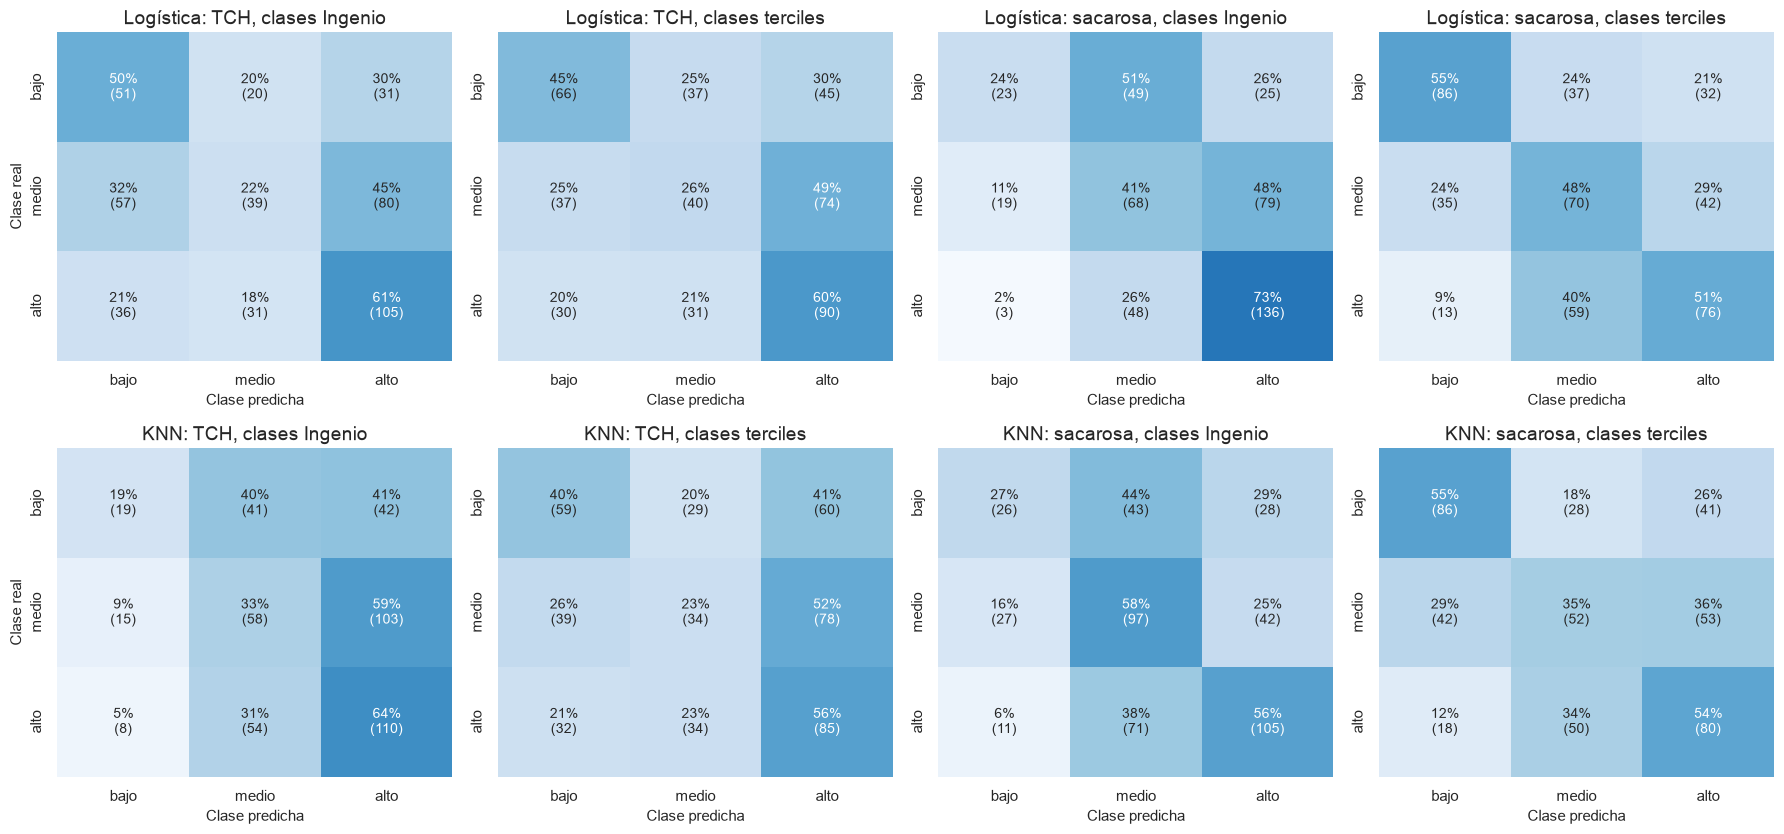

In [169]:
# 17.2 Matrices de confusión en el conjunto de prueba, normalizadas por la clase real
fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
for j, caso in enumerate(casos):
    for i, nombre in enumerate(["Logística", "KNN"]):
        m = matrices[(*caso, nombre)]
        proporcion = m / m.sum(axis=1, keepdims=True)
        etiquetas = np.array([[f"{p:.0%}\n({c})" for p, c in zip(fp, fc)] for fp, fc in zip(proporcion, m)])
        sns.heatmap(proporcion, annot=etiquetas, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False,
                    xticklabels=clases, yticklabels=clases, ax=axes[i, j], annot_kws={"fontsize": 10})
        axes[i, j].set(title=f"{nombre}: {caso[0]}, clases {caso[1]}", xlabel="Clase predicha",
                       ylabel="Clase real" if j == 0 else "")
plt.tight_layout()
plt.show()

### Conclusión de 17.2

F1 de cada clase en el conjunto de prueba:

| Target | Clases | Modelo | Bajo | Medio | Alto |
|---|---|---|---|---|---|
| TCH | Ingenio | Logística | 0.415 | 0.293 | 0.541 |
| TCH | Ingenio | KNN | 0.264 | 0.353 | 0.515 |
| TCH | Terciles | Logística | 0.470 | 0.309 | 0.500 |
| TCH | Terciles | KNN | 0.424 | 0.274 | 0.455 |
| Sacarosa | Ingenio | Logística | 0.324 | 0.411 | 0.637 |
| Sacarosa | Ingenio | KNN | 0.323 | 0.515 | 0.580 |
| Sacarosa | Terciles | Logística | 0.595 | 0.447 | 0.510 |
| Sacarosa | Terciles | KNN | 0.571 | 0.375 | 0.497 |

Errores entre clases no contiguas (cosechas bajas clasificadas como altas o altas como bajas):

| Target | Clases | Logística | KNN |
|---|---|---|---|
| TCH | Ingenio | 67 de 255 (26.3 %) | 50 de 263 (19.0 %) |
| TCH | Terciles | 75 de 254 (29.5 %) | 92 de 272 (33.8 %) |
| Sacarosa | Ingenio | 28 de 223 (12.6 %) | 39 de 222 (17.6 %) |
| Sacarosa | Terciles | 45 de 218 (20.6 %) | 59 de 232 (25.4 %) |

- En TCH, la clase media es la más difícil de clasificar con las dos definiciones, salvo en KNN con
  umbrales del Ingenio, que tiene aún más dificultad con la clase baja. Su F1 va de 0.274 a 0.353, frente
  a 0.415 a 0.541 de las clases extremas en la logística. Cambiar los umbrales del Ingenio por terciles
  no la mejora de forma consistente: la logística pasa de 0.293 a 0.309 y KNN baja de 0.353 a 0.274.
- En TCH, entre el 19.0 % y el 33.8 % de los errores ocurren entre la clase baja y la alta. Si los
  errores se repartieran al azar entre las dos clases incorrectas, cerca de un tercio sería de ese tipo,
  así que los modelos captan poco el orden de las clases. Por ejemplo, la logística clasifica como altas
  el 30 % de las cosechas bajas con las dos definiciones.
- En sacarosa los modelos distinguen mejor el orden de las clases: entre el 12.6 % y el 25.4 % de los
  errores ocurren entre la clase baja y la alta, y con la logística y los umbrales del Ingenio solo el
  2 % de las cosechas altas se clasifica como baja.
- En sacarosa con umbrales del Ingenio, la clase más difícil no es la media sino la baja, con un F1 de
  0.32 en ambos modelos, frente a 0.41 y 0.52 de la clase media. La clase baja es la más pequeña con esta
  definición, y la mayoría de sus errores la asignan a la clase media (51 % de las cosechas bajas con la
  logística y 44 % con KNN), es decir, a la clase contigua. En sacarosa por terciles, la clase media sí es
  la más difícil (F1 de 0.447 y 0.375).
- En TCH, la dificultad con la clase media no depende de la definición de las clases: se mantiene con
  los umbrales del Ingenio y con terciles, en los dos modelos, y va acompañada de confusiones frecuentes
  entre las clases extremas. La limitación está en la información de los predictores sobre el tonelaje,
  que no incluyen el tipo de suelo, la lluvia por etapas del ciclo ni el riego. En sacarosa, los modelos
  captan el orden de las clases, y la dificultad principal está en la frontera entre la clase baja y la
  media con los umbrales del Ingenio.

### 17.3 Umbrales de alerta para la clase baja

Hasta ahora, cada cosecha se asigna a la clase con mayor probabilidad. Para identificar cosechas bajas,
el Ingenio puede usar otra regla: emitir una alerta cuando la probabilidad de la clase baja supera un
umbral. Un umbral bajo detecta más cosechas bajas a costa de más falsas alarmas, y uno alto produce menos
alarmas pero deja más cosechas bajas sin detectar. El umbral adecuado depende de la relación entre el
costo de no detectar una cosecha baja, que impide intervenir a tiempo, y el de una falsa alarma, que
implica revisar una suerte que no lo necesitaba. Esa relación no se conoce, así que se analizan cinco
escenarios: una falsa alarma dos veces más costosa que una cosecha baja no detectada, costos iguales, y
una cosecha baja no detectada dos, tres y cinco veces más costosa que una falsa alarma.

Para cada escenario se elige, entre umbrales de 0.10 a 0.80, el que minimiza el costo total de los
errores en el conjunto de entrenamiento, y luego se verifica en el conjunto de prueba. Las probabilidades
de entrenamiento se obtienen fuera de pliegue, con la misma validación cruzada agrupada por periodo: cada
cosecha recibe la probabilidad de un modelo que no la usó en su ajuste. Así, el umbral se elige sin usar
el conjunto de prueba. Se usa la regresión logística, que ordenó las cosechas según su riesgo de ser
bajas mejor que KNN en los cuatro casos (17.1).

El umbral se elige minimizando directamente el costo con los errores observados, y no con la fórmula
que lo deriva de la relación de costos, porque esa fórmula supone probabilidades calibradas. En tres de
los cuatro casos la logística usa ponderación balanceada de clases, que aumenta a propósito la
probabilidad de la clase baja.

Como referencia se incluye la regla de la clase más probable, evaluada en 17.1.

In [170]:
# 17.3 Umbrales de alerta para la clase baja con la regresión logística
from sklearn.model_selection import cross_val_predict

umbrales = np.round(np.arange(0.10, 0.81, 0.05), 2)
# Relación entre el costo de no detectar una cosecha baja y el de una falsa alarma
escenarios = {"Falsa alarma 2 veces más costosa": 0.5, "Costos iguales": 1,
              "Baja no detectada 2 veces más costosa": 2, "Baja no detectada 3 veces más costosa": 3,
              "Baja no detectada 5 veces más costosa": 5}


def curva_alerta(p_bajo, es_bajo):
    """Sensibilidad, precisión y cosechas alertadas al alertar cuando P(bajo) >= umbral."""
    filas = []
    for t in umbrales:
        alerta = p_bajo >= t
        vp, fp, fn = (alerta & es_bajo).sum(), (alerta & ~es_bajo).sum(), (~alerta & es_bajo).sum()
        filas.append({"Umbral": t, "Sensibilidad": vp / es_bajo.sum(),
                      "Precisión": vp / alerta.sum() if alerta.sum() else np.nan,
                      "% alertadas": alerta.mean() * 100, "FP": fp, "FN": fn})
    return pd.DataFrame(filas).set_index("Umbral")


curvas, filas_umbral = {}, []
for caso, col in casos.items():
    modelo = finales[(*caso, "Logística")].best_estimator_
    i_bajo = list(modelo.classes_).index("bajo")
    X_tr, y_tr, g_tr = datos_caso(col, df_train)
    X_te, y_te, _ = datos_caso(col, df_test)
    # Probabilidades de entrenamiento fuera de pliegue: cada cosecha la predice un modelo que no la vio
    p_tr = cross_val_predict(clone(modelo), X_tr, y_tr, groups=g_tr, cv=cv, method="predict_proba")[:, i_bajo]
    p_te = modelo.predict_proba(X_te)[:, i_bajo]
    curvas[caso] = (curva_alerta(p_tr, (y_tr == "bajo").to_numpy()),
                    curva_alerta(p_te, (y_te == "bajo").to_numpy()))
    c_tr, c_te = curvas[caso]

    # Regla por defecto: la cosecha se clasifica como baja si "bajo" es la clase más probable
    fila_def = metricas_test.loc[(*caso, "Logística")]
    filas_umbral.append({"Target": caso[0], "Clases": caso[1], "Escenario": "Clase más probable (17.1)",
                         "Umbral": "—", "Sensibilidad test": fila_def["sens_bajo"],
                         "Precisión test": fila_def["prec_bajo"],
                         "% alertadas test": (modelo.predict(X_te) == "bajo").mean() * 100})
    # Umbral que minimiza el costo total en entrenamiento para cada escenario, verificado en prueba
    for nombre, razon in escenarios.items():
        t = (razon * c_tr["FN"] + c_tr["FP"]).idxmin()
        filas_umbral.append({"Target": caso[0], "Clases": caso[1], "Escenario": nombre, "Umbral": t,
                             "Sensibilidad train": c_tr.loc[t, "Sensibilidad"],
                             "Precisión train": c_tr.loc[t, "Precisión"],
                             "Sensibilidad test": c_te.loc[t, "Sensibilidad"],
                             "Precisión test": c_te.loc[t, "Precisión"],
                             "% alertadas test": c_te.loc[t, "% alertadas"]})

tabla_umbrales = (pd.DataFrame(filas_umbral).set_index(["Target", "Clases", "Escenario"])
                  [["Umbral", "Sensibilidad train", "Precisión train", "Sensibilidad test", "Precisión test",
                    "% alertadas test"]])
display(tabla_umbrales.round(3))

Umbral  \
Target   Clases   Escenario                                      
TCH      Ingenio  Clase más probable (17.1)                  —   
                  Falsa alarma 2 veces más costosa         0.8   
                  Costos iguales                           0.8   
                  Baja no detectada 2 veces más costosa    0.6   
                  Baja no detectada 3 veces más costosa   0.35   
                  Baja no detectada 5 veces más costosa   0.25   
         terciles Clase más probable (17.1)                  —   
                  Falsa alarma 2 veces más costosa         0.7   
                  Costos iguales                          0.55   
                  Baja no detectada 2 veces más costosa    0.3   
                  Baja no detectada 3 veces más costosa    0.2   
                  Baja no detectada 5 veces más costosa    0.2   
sacarosa Ingenio  Clase más probable (17.1)                  —   
                  Falsa alarma 2 veces más costosa         0.8   
                  Costos iguales                           0.6   
                  Baja no detectada 2 veces más costosa    0.3   
                  Baja no detectada 3 veces más costosa    0.3   
                  Baja no detectada 5 veces más costosa   0.15   
         terciles Clase más probable (17.1)                  —   
                  Falsa alarma 2 veces más costosa        0.65   
                  Costos iguales                          0.35   
                  Baja no detectada 2 veces más costosa   0.35   
                  Baja no detectada 3 veces más costosa    0.3   
                  Baja no detectada 5 veces más costosa   0.15   

                                                         Sensibilidad train  \
Target   Clases   Escenario                                                   
TCH      Ingenio  Clase más probable (17.1)                             NaN   
                  Falsa alarma 2 veces más costosa                    0.000   
                  Costos iguales                                      0.000   
                  Baja no detectada 2 veces más costosa               0.020   
                  Baja no detectada 3 veces más costosa               0.538   
                  Baja no detectada 5 veces más costosa               0.824   
         terciles Clase más probable (17.1)                             NaN   
                  Falsa alarma 2 veces más costosa                    0.000   
                  Costos iguales                                      0.060   
                  Baja no detectada 2 veces más costosa               0.716   
                  Baja no detectada 3 veces más costosa               0.942   
                  Baja no detectada 5 veces más costosa               0.942   
sacarosa Ingenio  Clase más probable (17.1)                             NaN   
                  Falsa alarma 2 veces más costosa                    0.000   
                  Costos iguales                                      0.091   
                  Baja no detectada 2 veces más costosa               0.540   
                  Baja no detectada 3 veces más costosa               0.540   
                  Baja no detectada 5 veces más costosa               0.850   
         terciles Clase más probable (17.1)                             NaN   
                  Falsa alarma 2 veces más costosa                    0.073   
                  Costos iguales                                      0.609   
                  Baja no detectada 2 veces más costosa               0.609   
                  Baja no detectada 3 veces más costosa               0.751   
                  Baja no detectada 5 veces más costosa               0.949   

                                                         Precisión train  \
Target   Clases   Escenario                                                
TCH      Ingenio  Clase más probable (17.1)                          NaN   
                  Falsa alarma 2 veces más costosa      

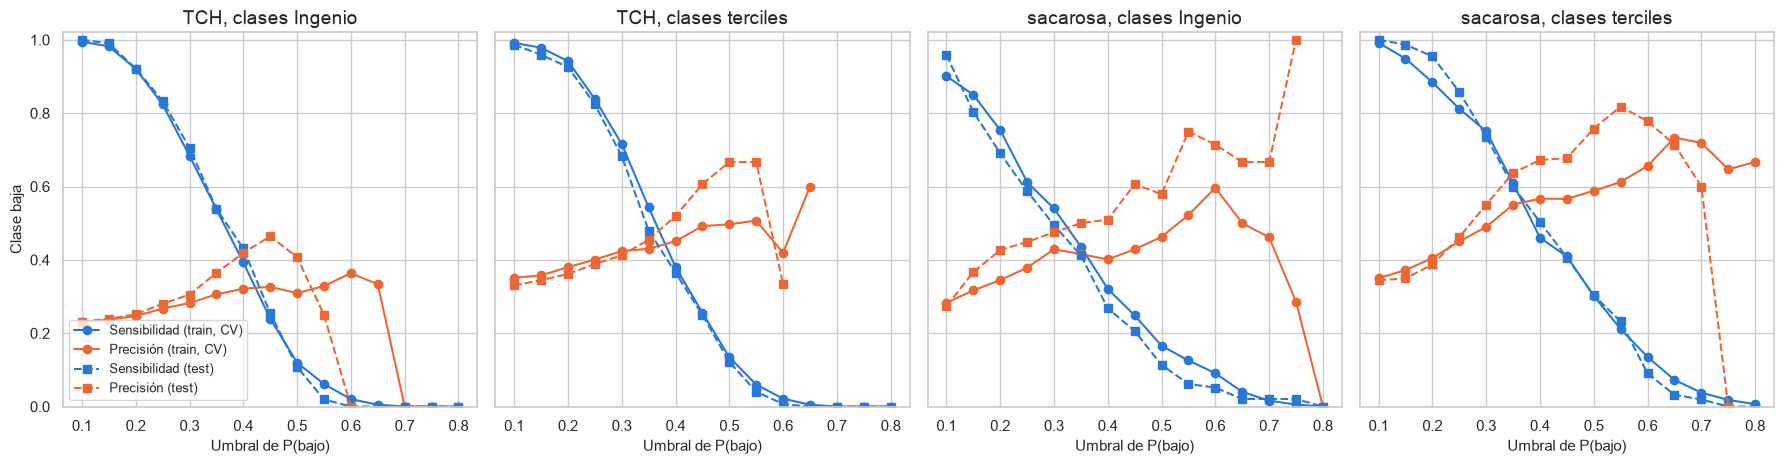

In [171]:
# 17.3 Sensibilidad y precisión de la alerta de clase baja según el umbral
COLOR_SENS, COLOR_PREC = "#2a78d6", "#eb6834"
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharey=True)
for ax, (caso, (c_tr, c_te)) in zip(axes, curvas.items()):
    ax.plot(c_tr.index, c_tr["Sensibilidad"], color=COLOR_SENS, marker="o", label="Sensibilidad (train, CV)")
    ax.plot(c_tr.index, c_tr["Precisión"], color=COLOR_PREC, marker="o", label="Precisión (train, CV)")
    ax.plot(c_te.index, c_te["Sensibilidad"], color=COLOR_SENS, linestyle="--", marker="s", label="Sensibilidad (test)")
    ax.plot(c_te.index, c_te["Precisión"], color=COLOR_PREC, linestyle="--", marker="s", label="Precisión (test)")
    ax.set(title=f"{caso[0]}, clases {caso[1]}", xlabel="Umbral de P(bajo)", ylim=(0, 1.02))
axes[0].set_ylabel("Clase baja")
axes[0].legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

### Conclusión de 17.3

Umbral elegido en cada escenario y su desempeño en el conjunto de prueba:

| Target | Clases | Escenario | Umbral | Sensibilidad bajo | Precisión bajo | Cosechas alertadas |
|---|---|---|---|---|---|---|
| TCH | Ingenio | Clase más probable (17.1) | — | 0.500 | 0.354 | 32.0 % |
| TCH | Ingenio | Falsa alarma 2 veces más costosa | 0.80 | 0.000 | — | 0.0 % |
| TCH | Ingenio | Costos iguales | 0.80 | 0.000 | — | 0.0 % |
| TCH | Ingenio | Baja no detectada 2 veces más costosa | 0.60 | 0.000 | 0.000 | 0.4 % |
| TCH | Ingenio | Baja no detectada 3 veces más costosa | 0.35 | 0.539 | 0.364 | 33.6 % |
| TCH | Ingenio | Baja no detectada 5 veces más costosa | 0.25 | 0.833 | 0.281 | 67.3 % |
| TCH | Terciles | Clase más probable (17.1) | — | 0.446 | 0.496 | 29.6 % |
| TCH | Terciles | Falsa alarma 2 veces más costosa | 0.70 | 0.000 | — | 0.0 % |
| TCH | Terciles | Costos iguales | 0.55 | 0.041 | 0.667 | 2.0 % |
| TCH | Terciles | Baja no detectada 2 veces más costosa | 0.30 | 0.682 | 0.412 | 54.4 % |
| TCH | Terciles | Baja no detectada 3 y 5 veces más costosa | 0.20 | 0.926 | 0.361 | 84.2 % |
| Sacarosa | Ingenio | Clase más probable (17.1) | — | 0.237 | 0.511 | 10.0 % |
| Sacarosa | Ingenio | Falsa alarma 2 veces más costosa | 0.80 | 0.000 | — | 0.0 % |
| Sacarosa | Ingenio | Costos iguales | 0.60 | 0.052 | 0.714 | 1.6 % |
| Sacarosa | Ingenio | Baja no detectada 2 y 3 veces más costosa | 0.30 | 0.495 | 0.475 | 22.4 % |
| Sacarosa | Ingenio | Baja no detectada 5 veces más costosa | 0.15 | 0.804 | 0.366 | 47.3 % |
| Sacarosa | Terciles | Clase más probable (17.1) | — | 0.555 | 0.642 | 29.8 % |
| Sacarosa | Terciles | Falsa alarma 2 veces más costosa | 0.65 | 0.032 | 0.714 | 1.6 % |
| Sacarosa | Terciles | Costos iguales y baja no detectada 2 veces más costosa | 0.35 | 0.600 | 0.637 | 32.4 % |
| Sacarosa | Terciles | Baja no detectada 3 veces más costosa | 0.30 | 0.735 | 0.551 | 46.0 % |
| Sacarosa | Terciles | Baja no detectada 5 veces más costosa | 0.15 | 0.987 | 0.349 | 97.3 % |

- Una alerta solo reduce el costo total si la probabilidad de que sea correcta supera la proporción que
  representa el costo de una falsa alarma dentro de la suma de ambos costos: 67 % si la falsa alarma es
  dos veces más costosa, 50 % con costos iguales, 33 % si no detectar una cosecha baja es dos veces más
  costoso, 25 % si es tres veces y 17 % si es cinco veces. Cuando la falsa alarma es más costosa, el
  umbral óptimo emite muy pocas alertas o ninguna en los cuatro casos. Con costos iguales ocurre lo mismo
  en tres casos, porque la precisión de las alertas rara vez supera el 50 %. La excepción es sacarosa por
  terciles, donde un umbral de 0.35 alcanza una precisión de 0.551 en entrenamiento y alerta al 32.4 % de
  las cosechas de prueba. En TCH con umbrales del Ingenio, la precisión de las alertas en entrenamiento
  no supera el 37 %, así que la alerta solo resulta útil si una cosecha baja no detectada cuesta al menos
  tres veces lo que una falsa alarma.
- En sacarosa con umbrales del Ingenio, un umbral de 0.30 duplica la detección de cosechas bajas frente a
  la regla de la clase más probable (49.5 % frente a 23.7 % en prueba) con una precisión similar (47.5 %
  frente a 51.1 %), a cambio de alertar al 22.4 % de las cosechas en lugar del 10.0 %. Es el umbral de
  menor costo si una cosecha baja no detectada cuesta dos o tres veces lo que una falsa alarma. El modelo
  ya ordenaba bien las cosechas según su riesgo (AUC de 0.773), pero la regla de la clase más probable
  asignaba a la clase media la mitad de las cosechas bajas (17.2).
- En los casos con ponderación balanceada de clases, la regla de la clase más probable ya funciona como
  un umbral intermedio. En TCH con umbrales del Ingenio da una sensibilidad de 0.500 y una precisión de
  0.354, muy parecidas a las del umbral 0.35 (0.539 y 0.364).
- Los umbrales elegidos con las probabilidades fuera de pliegue de entrenamiento se sostienen en prueba:
  las curvas de sensibilidad de los dos conjuntos casi coinciden en los cuatro casos, y la precisión en
  prueba es similar o mayor en los umbrales intermedios. Solo con umbrales altos, que alertan a muy pocas
  cosechas, la precisión varía mucho entre los dos conjuntos.
- Cuando no detectar una cosecha baja es mucho más costoso (cinco veces), el umbral óptimo es tan bajo
  que la alerta pierde selectividad: marca entre el 47 % y el 97 % de las cosechas. En sacarosa por
  terciles alerta a casi todas, así que equivaldría a revisar todas las suertes.
- La elección del umbral es una decisión del Ingenio, no del modelo. Si el Ingenio estima que una cosecha
  baja no detectada cuesta entre dos y tres veces lo que una revisión innecesaria, el umbral de 0.30 en
  sacarosa con umbrales del Ingenio le permitiría identificar cerca de la mitad de las cosechas de baja
  sacarosa revisando una de cada cinco suertes, con casi la mitad de las alertas correctas.

### 17.4 Elección del modelo para cada caso

La elección entre la regresión logística y KNN no se basa solo en la métrica principal. Se consideran
cuatro criterios:

- **Desempeño en validación cruzada:** F1 macro medio en los 5 pliegues, que es la estimación usada para
  ajustar los modelos.
- **Desempeño en prueba:** F1 macro, kappa y métricas de la clase baja en periodos que no intervinieron en
  ninguna decisión.
- **Estabilidad:** desviación del F1 macro entre pliegues.
- **Utilidad para el Ingenio:** capacidad de ordenar las cosechas según su riesgo de ser bajas (AUC de la
  clase baja), que permite fijar un umbral de alerta (17.3), e interpretabilidad del efecto de cada
  predictor.

La tabla reúne estos criterios para los dos modelos en cada caso.

In [172]:
# 17.4 Resumen del desempeño de los modelos finales en validación cruzada y en prueba
resumen = pd.DataFrame({
    "F1 CV": metricas_cv["f1_macro"], "Desv. F1 CV": metricas_cv["f1_macro desv"],
    "F1 test": metricas_test["f1_macro"], "Kappa test": metricas_test["kappa"],
    "Precisión bajo test": metricas_test["prec_bajo"], "Sensibilidad bajo test": metricas_test["sens_bajo"],
    "AUC bajo CV": metricas_cv["auc_bajo"], "AUC bajo test": metricas_test["auc_bajo"],
}).drop(index="Azar estratificado", level="Modelo").astype(float)
display(resumen.round(3))

F1 CV  Desv. F1 CV  F1 test  Kappa test  \
Target   Clases   Modelo                                               
TCH      Ingenio  Logística  0.422        0.051    0.416       0.149   
                  KNN        0.378        0.035    0.377       0.071   
         terciles Logística  0.446        0.028    0.426       0.153   
                  KNN        0.429        0.037    0.384       0.093   
sacarosa Ingenio  Logística  0.448        0.015    0.457       0.203   
                  KNN        0.443        0.028    0.473       0.223   
         terciles Logística  0.452        0.050    0.518       0.274   
                  KNN        0.468        0.056    0.481       0.227   

                             Precisión bajo test  Sensibilidad bajo test  \
Target   Clases   Modelo                                                   
TCH      Ingenio  Logística                0.354                   0.500   
                  KNN                      0.452                   0.186   
         terciles Logística                0.496                   0.446   
                  KNN                      0.454                   0.399   
sacarosa Ingenio  Logística                0.511                   0.237   
                  KNN                      0.406                   0.268   
         terciles Logística                0.642                   0.555   
                  KNN                      0.589                   0.555   

                             AUC bajo CV  AUC bajo test  
Target   Clases   Modelo                                 
TCH      Ingenio  Logística        0.628          0.674  
                  KNN              0.540          0.615  
         terciles Logística        0.632          0.658  
                  KNN              0.606          0.596  
sacarosa Ingenio  Logística        0.734          0.773  
                  KNN              0.677          0.711  
         terciles Logística        0.728          0.771  
                  KNN              0.705          0.719

### Conclusión de 17.4

| Target | Clases | Modelo | F1 CV | F1 test | Kappa test | Sensibilidad bajo test | AUC bajo CV | AUC bajo test |
|---|---|---|---|---|---|---|---|---|
| TCH | Ingenio | Logística | 0.422 ± 0.051 | 0.416 | 0.149 | 0.500 | 0.628 | 0.674 |
| TCH | Ingenio | KNN | 0.378 ± 0.035 | 0.377 | 0.071 | 0.186 | 0.540 | 0.615 |
| TCH | Terciles | Logística | 0.446 ± 0.028 | 0.426 | 0.153 | 0.446 | 0.632 | 0.658 |
| TCH | Terciles | KNN | 0.429 ± 0.037 | 0.384 | 0.093 | 0.399 | 0.606 | 0.596 |
| Sacarosa | Ingenio | Logística | 0.448 ± 0.015 | 0.457 | 0.203 | 0.237 | 0.734 | 0.773 |
| Sacarosa | Ingenio | KNN | 0.443 ± 0.028 | 0.473 | 0.223 | 0.268 | 0.677 | 0.711 |
| Sacarosa | Terciles | Logística | 0.452 ± 0.050 | 0.518 | 0.274 | 0.555 | 0.728 | 0.771 |
| Sacarosa | Terciles | KNN | 0.468 ± 0.056 | 0.481 | 0.227 | 0.555 | 0.705 | 0.719 |

**Modelo elegido: regresión logística en los cuatro casos**

- En TCH, la logística obtiene un F1 macro mayor en validación cruzada y en prueba, y un kappa, una
  sensibilidad de la clase baja y un AUC de la clase baja mayores, con las dos definiciones de clase. Con
  los umbrales del Ingenio, KNN tiene mayor precisión en la clase baja (0.452 frente a 0.354) y menor
  desviación entre pliegues, pero detecta solo el 18.6 % de las cosechas bajas, lo mismo que el azar,
  mientras que la logística detecta la mitad.
- En sacarosa, los dos modelos son equivalentes en validación cruzada (diferencias de F1 macro de 0.005
  y 0.016, dentro de la desviación entre pliegues). En prueba, la logística es mejor con terciles, y KNN
  tiene un F1 macro y un kappa algo mayores con los umbrales del Ingenio. En ese caso se elige igualmente
  la logística, porque ordena mejor las cosechas según su riesgo de ser bajas (AUC de 0.773 frente a
  0.711), y con un umbral de alerta de 0.30 duplica su detección de la clase baja (17.3).
- La estabilidad entre pliegues no distingue a los modelos: la logística tiene menor desviación en tres
  casos y KNN en uno.
- La logística es además interpretable: sus coeficientes indican el efecto de cada predictor sobre la
  probabilidad de cada clase (14.3), lo que permite traducir el modelo en recomendaciones agronómicas.
  KNN no ofrece esa información, y su flexibilidad para representar fronteras no lineales no mejoró el
  desempeño con estos predictores.

**Definición de clases**

- Los terciles obtienen un F1 macro algo mayor, pero no es una comparación directa, porque las clases
  tienen tamaños y fronteras distintas. Con las dos definiciones, los predictores importantes y sus
  signos son los mismos (14.3), y la dificultad de la clase media en TCH se mantiene (17.2).
- Para el uso operativo se recomiendan los umbrales del Ingenio: sus clases tienen un significado
  agronómico reconocido por el Ingenio, mientras que los cortes de los terciles dependen de la
  distribución del periodo analizado y cambiarían con nuevos datos. Los terciles sirven como verificación
  de que las conclusiones no dependen de la definición de las clases.

### Conclusión de la sección 17

- En el conjunto de prueba, formado por 16 periodos que no intervinieron en ninguna decisión, la
  regresión logística obtiene un F1 macro de 0.416 a 0.518 y un kappa de 0.149 a 0.274, frente a un F1
  macro de 0.296 a 0.361 del azar estratificado. El desempeño en prueba es coherente con el de la
  validación cruzada, sin señales de sobreajuste.
- La regresión logística es el modelo elegido en los cuatro casos, por su desempeño igual o mejor que el
  de KNN, su mayor capacidad para ordenar las cosechas según su riesgo de ser bajas y su
  interpretabilidad.
- En TCH, la clase media es la más difícil con las dos definiciones, y entre una quinta parte y un tercio
  de los errores confunde las clases extremas: los predictores disponibles tienen poca información sobre
  el tonelaje. En sacarosa, los modelos captan el orden de las clases, y la mayor dificultad está en
  separar la clase baja de la media con los umbrales del Ingenio.
- La utilidad del modelo para alertar sobre cosechas bajas depende de la relación de costos que estime el
  Ingenio. En sacarosa con umbrales del Ingenio, un umbral de alerta de 0.30 duplica la detección de
  cosechas bajas con una precisión similar, si una cosecha baja no detectada cuesta dos o tres veces lo
  que una falsa alarma. En TCH, la alerta solo resulta útil si ese costo es al menos tres veces mayor.
- Se recomiendan los umbrales del Ingenio para el uso operativo, por su significado agronómico. Las
  conclusiones sobre los predictores son las mismas con terciles.

## 18. Interpretación y conclusiones

Esta sección traduce los resultados en conclusiones para el Ingenio. Primero se revisan los coeficientes
de los modelos finales (18.1), que tienen menos predictores que los analizados en 14.3. Después se
formulan las recomendaciones que se desprenden de los modelos (18.2), las limitaciones de los datos y del
análisis (18.3) y las líneas de trabajo futuro (18.4).

### 18.1 Coeficientes de los modelos finales

Los coeficientes analizados en 14.3 corresponden a modelos con 13 predictores. Los modelos finales,
elegidos en la sección 16, no incluyen `anio` ni `lluvia_sin_dato`, y se reentrenaron en 17.1 con los 11
predictores restantes. Al quitar predictores, los coeficientes de los demás pueden cambiar, en especial
si estaban relacionados con los eliminados. Por eso se repite el análisis de 14.3 con los modelos
finales: contraste entre la clase baja y la alta, razón de odds, columnas eliminadas y estabilidad entre
pliegues. Además, se compara la razón de odds de cada predictor en ambos análisis.

In [173]:
# 18.1 Coeficientes de los modelos finales (regresión logística con 11 predictores)
tablas_coef_final = {caso: tabla_coeficientes(finales[(*caso, "Logística")], col) for caso, col in casos.items()}
for (tgt, defin), tabla in tablas_coef_final.items():
    print(f"\n{tgt}, clases {defin}: {tabla['Eliminada por L1'].sum()} de {len(tabla)} columnas eliminadas")
    display(tabla)

# Razón de odds de cada predictor en 14.3 (13 predictores) y en el modelo final (11 predictores)
comparacion_odds = pd.concat({
    f"{tgt}, {defin}": pd.DataFrame({
        "14.3": tablas_coef[(tgt, defin)]["Razón de odds"],
        "Final": tablas_coef_final[(tgt, defin)]["Razón de odds"],
    }).reindex(tablas_coef_final[(tgt, defin)].index)
    for tgt, defin in casos
}, axis=1)
display(comparacion_odds)


TCH, clases Ingenio: 0 de 12 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
grupo_tenencia_3,-0.488,0.61,False,5,5,0.50
cortes,0.444,1.56,False,5,5,1.63
pct_diatrea,-0.271,0.76,False,5,5,2.53
dosismad,-0.223,0.80,False,5,5,0.25
lluvias,-0.206,0.81,False,5,5,121.80
mes_cos_6,0.191,1.21,False,5,5,0.72
semsmad,0.168,1.18,False,5,5,3.53
edad,-0.144,0.87,False,5,5,1.15
mes_cos_12,0.112,1.12,False,5,5,0.73
mes_sin_12,0.057,1.06,False,5,4,0.67



TCH, clases terciles: 0 de 12 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
cortes,0.482,1.62,False,5,5,1.63
grupo_tenencia_3,-0.451,0.64,False,5,5,0.50
pct_diatrea,-0.255,0.77,False,5,5,2.53
edad,-0.237,0.79,False,5,5,1.15
dosismad,-0.228,0.80,False,5,5,0.25
semsmad,0.169,1.18,False,5,5,3.53
mes_cos_12,0.168,1.18,False,5,5,0.73
mes_cos_6,0.166,1.18,False,5,5,0.72
lluvias,-0.099,0.91,False,5,5,121.80
mes_sin_12,0.069,1.07,False,5,5,0.67



sacarosa, clases Ingenio: 0 de 12 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
mes_cos_12,-0.734,0.48,False,5,5,0.73
lluvias,0.684,1.98,False,5,5,121.70
mes_cos_6,0.639,1.89,False,5,5,0.72
semsmad,-0.389,0.68,False,5,5,3.53
pct_diatrea,0.249,1.28,False,5,5,2.53
mes_sin_6,0.219,1.25,False,5,5,0.69
mes_sin_12,0.218,1.24,False,5,5,0.67
grupo_tenencia_3,0.142,1.15,False,5,5,0.50
grupo_tenencia_2,-0.134,0.87,False,5,5,0.46
edad,0.077,1.08,False,5,4,1.15



sacarosa, clases terciles: 3 de 12 columnas eliminadas


,β_bajo − β_alto,Razón de odds,Eliminada por L1,Pliegues ≠ 0,Pliegues con el mismo signo,1 DE (unidades originales)
mes_cos_12,-0.609,0.54,False,5,5.0,0.73
mes_cos_6,0.484,1.62,False,5,5.0,0.72
lluvias,0.436,1.55,False,5,5.0,121.70
semsmad,-0.223,0.80,False,5,5.0,3.53
mes_sin_12,0.138,1.15,False,5,5.0,0.67
mes_sin_6,0.094,1.10,False,4,4.0,0.69
grupo_tenencia_2,-0.078,0.92,False,4,4.0,0.46
pct_diatrea,0.075,1.08,False,4,4.0,2.53
grupo_tenencia_3,0.042,1.04,False,2,2.0,0.50
edad,0.000,1.00,True,0,NaN,1.15


TCH, Ingenio       TCH, terciles       sacarosa, Ingenio  \
                         14.3 Final          14.3 Final              14.3   
grupo_tenencia_3         0.53  0.61          0.60  0.64              1.10   
cortes                   1.49  1.56          1.53  1.62              1.05   
pct_diatrea              0.79  0.76          0.81  0.77              1.25   
dosismad                 0.88  0.80          0.90  0.80              0.96   
lluvias                  0.87  0.81          0.97  0.91              1.89   
mes_cos_6                1.19  1.21          1.15  1.18              1.89   
semsmad                  1.18  1.18          1.17  1.18              0.72   
edad                     0.88  0.87          0.81  0.79              1.04   
mes_cos_12               1.08  1.12          1.14  1.18              0.49   
mes_sin_12               1.04  1.06          1.05  1.07              1.23   
grupo_tenencia_2         0.98  0.98          0.99  0.98              0.89   
mes_sin_6                0.98  1.01          0.97  1.00              1.24   

                       sacarosa, terciles        
                 Final               14.3 Final  
grupo_tenencia_3  1.15               1.03  1.04  
cortes            1.05               1.00  1.00  
pct_diatrea       1.28               1.08  1.08  
dosismad          0.98               1.00  1.00  
lluvias           1.98               1.55  1.55  
mes_cos_6         1.89               1.63  1.62  
semsmad           0.68               0.80  0.80  
edad              1.08               1.00  1.00  
mes_cos_12        0.48               0.54  0.54  
mes_sin_12        1.24               1.15  1.15  
grupo_tenencia_2  0.87               0.93  0.92  
mes_sin_6         1.25               1.10  1.10

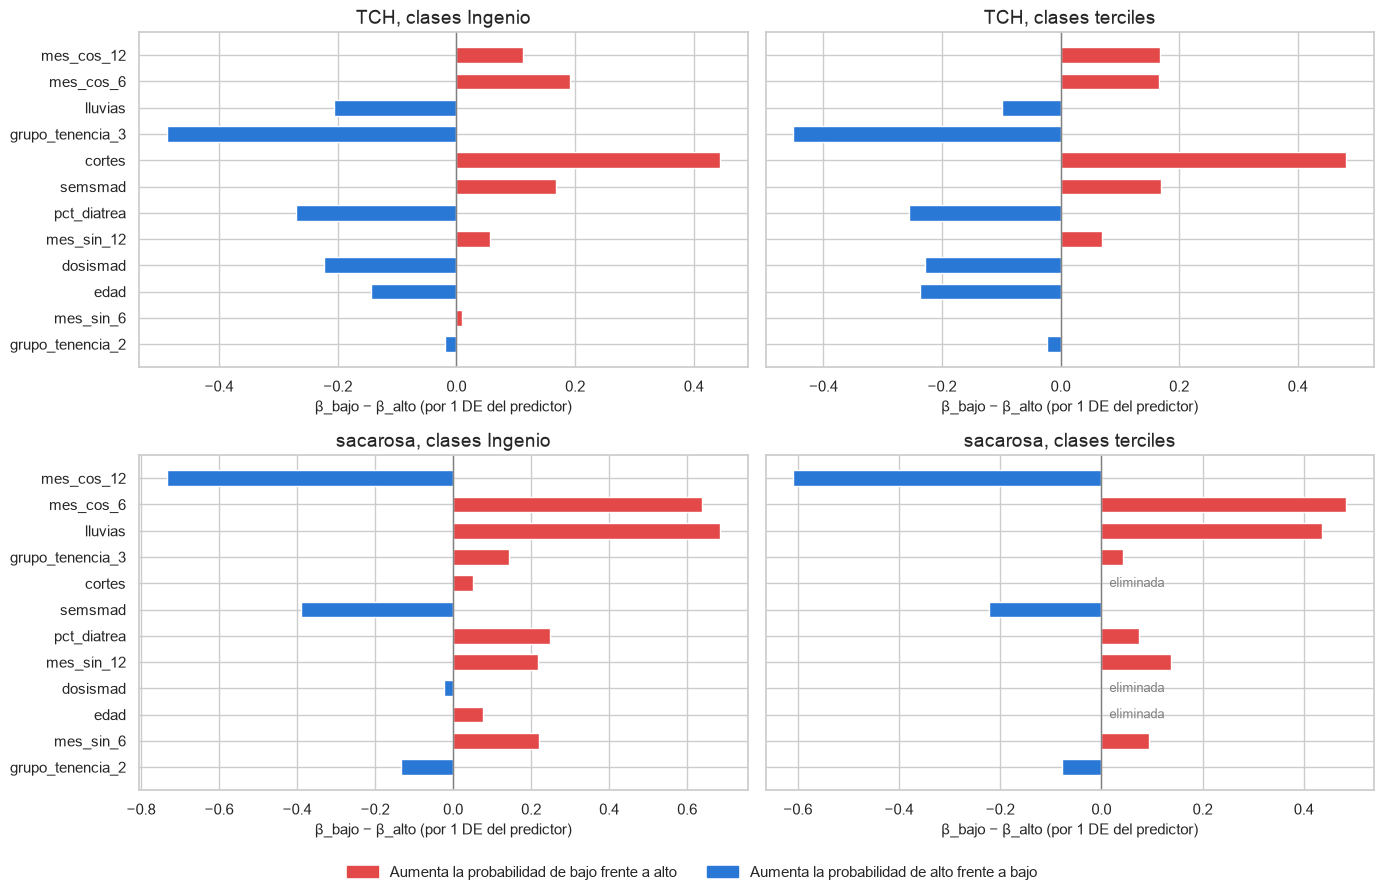

In [174]:
# 18.1 Contraste β_bajo − β_alto de cada predictor en los modelos finales
orden_final = (pd.DataFrame({caso: t["β_bajo − β_alto"] for caso, t in tablas_coef_final.items()})
               .abs().mean(axis=1).sort_values().index)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, ((tgt, defin), tabla) in zip(axes.ravel(), tablas_coef_final.items()):
    valores = tabla.loc[orden_final, "β_bajo − β_alto"]
    ax.barh(orden_final, valores, color=np.where(valores > 0, COLOR_BAJO, COLOR_ALTO), height=0.6)
    for pos, nombre in enumerate(orden_final):
        if tabla.loc[nombre, "Eliminada por L1"]:
            ax.text(0, pos, "  eliminada", va="center", fontsize=9, color="gray")
    ax.axvline(0, color="gray", linewidth=1)
    ax.set(title=f"{tgt}, clases {defin}", xlabel="β_bajo − β_alto (por 1 DE del predictor)")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=COLOR_BAJO),
                    plt.Rectangle((0, 0), 1, 1, color=COLOR_ALTO)],
           labels=["Aumenta la probabilidad de bajo frente a alto",
                   "Aumenta la probabilidad de alto frente a bajo"],
           loc="lower center", ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### Conclusión de 18.1

Razón de odds de la clase baja frente a la alta en 14.3 (13 predictores) y en el modelo final (11
predictores):

| Predictor | TCH, Ingenio | TCH, terciles | Sacarosa, Ingenio | Sacarosa, terciles |
|---|---|---|---|---|
| `cortes` | 1.49 → 1.56 | 1.53 → 1.62 | 1.05 → 1.05 | eliminada |
| `edad` | 0.88 → 0.87 | 0.81 → 0.79 | 1.04 → 1.08 | eliminada |
| `semsmad` | 1.18 → 1.18 | 1.17 → 1.18 | 0.72 → 0.68 | 0.80 → 0.80 |
| `lluvias` | 0.87 → 0.81 | 0.97 → 0.91 | 1.89 → 1.98 | 1.55 → 1.55 |
| `pct_diatrea` | 0.79 → 0.76 | 0.81 → 0.77 | 1.25 → 1.28 | 1.08 → 1.08 |
| `dosismad` | 0.88 → 0.80 | 0.90 → 0.80 | 0.96 → 0.98 | eliminada |
| `grupo_tenencia_2` | 0.98 → 0.98 | 0.99 → 0.98 | 0.89 → 0.87 | 0.93 → 0.92 |
| `grupo_tenencia_3` | 0.53 → 0.61 | 0.60 → 0.64 | 1.10 → 1.15 | 1.03 → 1.04 |

- Los modelos finales tienen 12 columnas en la matriz de diseño: los 11 predictores, con `grupo_tenencia`
  codificado en dos indicadoras. Solo el modelo de sacarosa por terciles elimina columnas (`edad`,
  `cortes` y `dosismad`), como en 14.3.
- Ningún predictor principal cambia de signo al quitar `anio` y `lluvia_sin_dato`, y los que eran
  estables en 14.3 conservan su signo en los 5 pliegues. La interpretación de 14.3 se mantiene para los
  predictores que siguen en el modelo.
- En sacarosa los coeficientes prácticamente no cambian: con terciles las razones de odds son iguales a
  las de 14.3, y con los umbrales del Ingenio difieren como máximo en 0.09 (`lluvias`, de 1.89 a 1.98).
  Los predictores eliminados no influían en la sacarosa.
- En TCH, al quitar la tendencia temporal, se refuerzan los efectos de `cortes` (razón de odds de 1.56 y
  1.62), de `lluvias` (0.81 y 0.91) y de `dosismad` (0.80 en ambas definiciones), y se debilita el de
  `grupo_tenencia_3` (0.61 y 0.64). `lluvias` queda con un efecto estable hacia la clase alta con las dos
  definiciones, lo que es coherente con el papel del agua en el crecimiento de la caña.
- El refuerzo de `dosismad` hacia la clase alta, un signo sin explicación agronómica directa (14.3),
  indica que parte del efecto que antes recogía `anio` se atribuye ahora a la dosis. Podría deberse a
  que la dosis de madurante cambió a lo largo de los años del periodo, lo que no se verificó en este
  análisis. Por eso su coeficiente no se interpreta como un efecto de la dosis sobre el tonelaje.
- Los predictores de mayor efecto en los modelos finales son `cortes`, `grupo_tenencia`, `pct_diatrea`,
  `edad` y `lluvias` en TCH, y el mes de cosecha, `lluvias` y `semsmad` en sacarosa. Sobre ellos se
  formulan las recomendaciones de 18.2.

### 18.2 Recomendaciones para el Ingenio

Las recomendaciones se basan en los predictores con efectos estables entre pliegues y con una
explicación agronómica coherente (14.3 y 18.1). Los coeficientes describen asociaciones en datos
históricos, no efectos causales: indican qué cosechas tienen mayor probabilidad de ser bajas o altas,
pero no garantizan que modificar un predictor cambie el resultado. Por eso las recomendaciones se
plantean como criterios para priorizar el seguimiento y para evaluar decisiones de manejo, y no como
intervenciones con un efecto asegurado. Todas aplican a suertes de la variedad CC01-1940 con maduración
química y cosecha mecánica, que es el alcance del dataset.

**Tonelaje (TCH)**

- **Número de cortes.** Dado que el número de cortes es el predictor con mayor efecto hacia el TCH bajo
  (cada 1.6 cortes adicionales multiplican por cerca de 1.6 la razón entre la probabilidad de TCH bajo y
  la de alto), el Ingenio podría usar el número de cortes para priorizar la evaluación de renovación de
  las suertes con más cortes y concentrar en ellas el seguimiento de productividad.
- **Edad en la cosecha.** Dado que una mayor edad del cultivo en la cosecha se asocia con una mayor
  probabilidad de TCH alto, el Ingenio podría tener en cuenta la edad al programar la cosecha, y evitar,
  cuando la logística lo permita, cosechar suertes con edades en el extremo inferior del rango observado
  (10 a 21 meses).
- **Lluvia.** Dado que una menor lluvia registrada se asocia con una mayor probabilidad de TCH bajo, el
  Ingenio podría usar la lluvia acumulada como señal temprana para anticipar menores tonelajes y, donde
  exista riego, para priorizar las suertes con menor lluvia.

**Sacarosa**

- **Mes de cosecha.** Dado que el mes de cosecha es el predictor más influyente de la sacarosa (las
  cosechas de mayo a julio tienden a la clase baja, y las de septiembre y octubre a la alta), el Ingenio
  podría anticipar una menor sacarosa en las cosechas programadas de mayo a julio y reforzar en esas
  suertes el seguimiento de la maduración antes del corte.
- **Lluvia.** Dado que cada 122 mm adicionales de lluvia multiplican por 1.98 (umbrales del Ingenio) y por
  1.55 (terciles) la razón entre la probabilidad de sacarosa baja y la de alta, el Ingenio podría usar la
  lluvia registrada antes de la cosecha para identificar las suertes con riesgo de baja sacarosa y evaluar
  en ellas el ajuste de la fecha de corte o de la maduración.
- **Daño por *Diatraea*.** Dado que un mayor daño por *Diatraea* se asocia con una menor sacarosa, los
  resultados respaldan la importancia del control del barrenador para la calidad de la caña. Como el
  porcentaje de daño se mide en la cosecha, su utilidad como predictor anticipado depende de contar con
  mediciones de daño durante el ciclo.

**Tonelaje frente a calidad: semanas desde el madurante**

- Dado que más semanas entre la aplicación del madurante y la cosecha se asocian con mayor sacarosa y con
  menor tonelaje, el Ingenio podría definir ese intervalo según el objetivo de cada suerte: más semanas
  cuando la prioridad es la calidad y menos cuando es el tonelaje. El intercambio entre ambos objetivos
  debería cuantificarse en un ensayo controlado antes de convertirlo en una regla de manejo.

**Alerta de cosechas bajas**

- En sacarosa con los umbrales del Ingenio, alertar cuando la probabilidad de la clase baja supera 0.30
  permitiría identificar cerca de la mitad de las cosechas de baja sacarosa (49.5 % en prueba), revisando
  el 22.4 % de las suertes, con casi la mitad de las alertas correctas (47.5 %). Esta regla conviene si el
  Ingenio estima que una cosecha baja no detectada cuesta entre dos y tres veces lo que una revisión
  innecesaria (17.3).
- En TCH, la precisión de las alertas es baja: con los umbrales del Ingenio no supera el 37 % en el
  conjunto de entrenamiento, con el que se eligen los umbrales. Por eso la alerta solo compensa si no
  detectar una cosecha baja cuesta al menos tres veces lo que una falsa alarma. Con los predictores
  actuales, el modelo de TCH es más útil para priorizar el seguimiento que para emitir alertas
  individuales.

### 18.3 Limitaciones

**Datos**

- **Alcance del dataset.** Todos los registros corresponden a la variedad CC01-1940, con maduración química
  y cosecha mecánica. Las conclusiones aplican solo a suertes con esas características y no describen el
  comportamiento de todo el Ingenio. Como la variedad es constante, tampoco se puede evaluar su efecto.
- **Vacío de datos climáticos.** El 31 % de los registros no tiene lluvia medida, por el vacío de cobertura
  climática del Ingenio entre 2017 y comienzos de 2022. Esos valores se imputaron con la mediana del mes de
  cosecha, que es una aproximación y no una medición.
- **Lluvia sin ventanas del ciclo.** `lluvias` es un único valor acumulado, cuya ventana de acumulación no
  está documentada. No se pudo analizar la lluvia por etapas del ciclo (crecimiento y maduración), que
  según el Ingenio es determinante, ni el efecto rezagado de fenómenos como El Niño y La Niña.
- **Predictores que faltan.** El dataset no incluye el tipo de suelo, el riego, la fertilización ni la
  topografía. Su ausencia explica en parte el desempeño limitado en TCH, donde los modelos confunden con
  frecuencia las clases extremas (17.2).
- **Significado incierto de algunas variables.** Los códigos de `grupo_tenencia` no están documentados,
  así que su efecto no se puede atribuir a una forma de tenencia. El significado de `semsmad` se dedujo de
  los datos, sin confirmación del Ingenio. `dosismad` varía poco, porque todas las suertes fueron maduradas,
  y ese rango estrecho puede ocultar su efecto.
- **Momento de medición de `pct_diatrea`.** El daño por *Diatraea* se mide en la cosecha, así que en
  operación solo estaría disponible si se midiera durante el ciclo.
- **Concentración de la sacarosa.** Con los umbrales del Ingenio, la clase media de sacarosa abarca solo
  0.7 puntos porcentuales. Diferencias pequeñas en la medición pueden cambiar la clase de una cosecha, lo
  que limita la precisión alcanzable en la frontera entre clases.

**Validación**

- **Conjunto de prueba pequeño y con meses poco representados.** La prueba está formada por 16 periodos
  (450 cosechas), y febrero, mayo, octubre y diciembre tienen menos de 10 cosechas en ella, así que la
  evaluación final no mide el desempeño en esos meses. Es una sola partición, y diferencias de alrededor
  de 0.04 en F1 macro entre modelos están dentro de su variabilidad.
- **Sin evaluación en años futuros.** La partición por periodo evita las cosechas simultáneas, pero el
  conjunto de prueba cubre los mismos años que el de entrenamiento (2015 a 2020). No se evaluó el
  desempeño al clasificar cosechas de años posteriores, que es el uso real del modelo.
- **Estimaciones de validación cruzada algo optimistas.** Los hiperparámetros y el conjunto de predictores
  se eligieron con los mismos pliegues con los que se estimó su desempeño. La evaluación en prueba no
  mostró una caída, pero con un solo conjunto de prueba ese sesgo no se puede descartar por completo.
- **Cortes de los terciles fijos en la validación cruzada.** Los cortes se calcularon con todo el conjunto
  de entrenamiento, incluidos los pliegues de validación. El efecto es menor y no afecta la evaluación en
  prueba.
- **Grilla de KNN.** En sacarosa por terciles, el k elegido con los predictores finales (51) quedó en el
  extremo de la grilla, que no se amplió después de usar el conjunto de prueba.

**Modelos e interpretación**

- **Desempeño limitado.** Con un kappa de 0.15 a 0.27 en prueba, los predictores disponibles antes de la
  cosecha permiten distinguir las clases, pero explican una parte limitada del resultado. Los modelos son
  más útiles para ordenar las cosechas según su riesgo que para asignar una clase exacta a cada una.
- **Asociación y no causalidad.** Los coeficientes describen asociaciones en datos observacionales. Algunos
  efectos no tienen una explicación agronómica directa (`pct_diatrea` y `dosismad` en TCH), y el de
  `dosismad` cambió al eliminar `anio`, lo que indica que puede reflejar cambios de manejo en el tiempo
  más que un efecto de la dosis.
- **Costos desconocidos.** Los costos de no detectar una cosecha baja y de una falsa alarma no se conocen.
  Por eso el análisis de umbrales se presentó por escenarios, y la elección del umbral queda a criterio del
  Ingenio.
- **Probabilidades no calibradas.** La ponderación balanceada de clases, usada en tres de los cuatro
  modelos, distorsiona las probabilidades estimadas. Los umbrales se eligieron minimizando el costo
  observado, pero las probabilidades no deben leerse como frecuencias exactas.
- **Clases ordenadas tratadas como nominales.** La regresión logística multinomial no aprovecha el orden
  entre las clases baja, media y alta, lo que contribuye a los errores entre clases no contiguas.

### 18.4 Trabajo futuro

**Nuevas variables**

- **Lluvia por etapas del ciclo y con rezago.** Construir la lluvia acumulada por ventanas (por ejemplo, 0 a
  3, 3 a 6 y 6 a 9 meses desde el corte anterior, y los 2 meses previos a la cosecha) a partir de los
  datos climáticos que el Ingenio integra desde Cenicaña, y agregar índices de El Niño y La Niña con
  rezago respecto a la siembra. Permitiría separar el efecto de la lluvia en el crecimiento del efecto en
  la maduración, y reducir la parte del efecto estacional que hoy recoge el mes de cosecha.
- **Suelo, riego y fertilización.** Incorporar la clasificación de suelos de Cenicaña y los registros de
  riego y fertilización de cada suerte. Son los factores de mayor peso en el tonelaje que faltan en el
  dataset, y su ausencia limita el desempeño en TCH.
- **Imágenes satelitales y sensores.** Índices de vegetación (por ejemplo, NDVI a partir de imágenes
  Sentinel-2) medidos durante el ciclo darían una estimación del desarrollo del cultivo antes de la
  cosecha, y sensores de humedad del suelo complementarían la lluvia registrada. Ambos aportarían
  información directa sobre la biomasa, que los predictores actuales solo reflejan de forma indirecta.
- **Monitoreo de *Diatraea* durante el ciclo.** Medir el daño del barrenador antes de la cosecha permitiría
  usarlo como predictor anticipado, y no solo como una medición al momento del corte.
- **Documentación de variables.** Confirmar con el Ingenio el significado de los códigos de
  `grupo_tenencia` y de `semsmad`, para interpretar sus efectos.
- **Ampliación del alcance.** Extender el análisis a otras variedades, a suertes sin maduración química y
  a cosecha manual, como las que incluye el histórico de suertes usado en regresión.

**Mejoras metodológicas**

- **Validación temporal.** Entrenar con los años anteriores y evaluar en los siguientes, en varias
  ventanas sucesivas. Mediría directamente el desempeño al clasificar cosechas futuras, incluida la
  estabilidad de los efectos entre años.
- **Regresión logística ordinal.** Un modelo que tenga en cuenta el orden entre las clases baja, media y
  alta podría reducir los errores entre clases no contiguas y dar coeficientes más fáciles de interpretar,
  con un solo efecto por predictor.
- **Modelos que capturen interacciones.** Probar modelos basados en árboles de decisión, que pueden
  representar interacciones como la de la lluvia con el mes de cosecha o con el suelo, y comparar su
  desempeño con el de la logística usando la misma validación agrupada por periodo.
- **Predictores específicos por target en KNN.** En TCH con los umbrales del Ingenio, KNN mejoró al quitar
  el mes de cosecha (sección 16). Un conjunto de predictores distinto para cada target, o una métrica de
  distancia con pesos por predictor, podría mejorar su desempeño.
- **Calibración de probabilidades y costos reales.** Calibrar las probabilidades de la logística y estimar
  con el Ingenio el costo de una cosecha baja no detectada y el de una revisión innecesaria. Con ambos, el
  umbral de alerta se podría fijar directamente a partir de la relación de costos.
- **Integración con el análisis de regresión.** Comparar la clasificación directa con la que se obtiene al
  predecir TCH y sacarosa con los modelos de regresión y asignar después la clase, y revisar la
  validación del análisis de regresión con una partición agrupada por periodo, dado el efecto de las
  cosechas simultáneas observado aquí (15.2).

**Monitoreo en tiempo real**

- El modelo se podría ejecutar cada mes sobre las suertes programadas para cosecha, con la lluvia
  actualizada desde la conexión con Cenicaña, y entregar una lista de suertes ordenadas según su
  probabilidad de sacarosa o TCH bajos, con la alerta según el umbral elegido por el Ingenio.
- Para mantenerlo vigente, se debería comparar cada mes la distribución de los predictores y el resultado
  real de las cosechas con lo esperado, y reentrenarlo periódicamente con la validación agrupada por
  periodo. Los cambios de manejo, de variedades o de clima pueden hacer que los efectos estimados dejen de
  ser válidos.

**Limitaciones éticas y prácticas**

- **Apoyo, no reemplazo del criterio agronómico.** Con un kappa de 0.15 a 0.27, el modelo debe usarse para
  priorizar el seguimiento, y no para tomar decisiones automáticas sobre suertes individuales.
- **Trato equitativo entre formas de tenencia.** Si los códigos de `grupo_tenencia` corresponden a tierras
  propias y a proveedores, un modelo que los usa podría llevar a asignar más o menos seguimiento según la
  forma de tenencia y no según las condiciones del cultivo. Su uso en decisiones que afecten a proveedores
  debería revisarse con transparencia.
- **Costo de las falsas alarmas.** Cada alerta implica una revisión en campo. Un umbral demasiado bajo
  podría saturar a los equipos y restar credibilidad a las alertas, así que su elección debe considerar la
  capacidad operativa.
- **Privacidad de la información de las suertes.** Los datos de producción de proveedores son
  información sensible, y su uso en un sistema de monitoreo requiere acuerdos claros sobre su manejo.

### Conclusión general

- Se clasificaron las cosechas de CC01-1940 en niveles bajo, medio y alto de TCH y de sacarosa, con dos
  definiciones de clase (umbrales del Ingenio y terciles), usando solo información disponible antes de la
  cosecha. La partición y la validación cruzada se agruparon por periodo, porque las cosechas simultáneas
  de una misma hacienda tienen predictores casi idénticos y resultados parecidos. Una validación que las
  admitiera sobreestimaría el desempeño, en especial el de KNN, que parecería superar a la regresión
  logística sin hacerlo en la práctica (15.2).
- La regresión logística multinomial con regularización es el modelo elegido en los cuatro casos. En el
  conjunto de prueba obtiene un F1 macro de 0.416 a 0.518, un kappa de 0.149 a 0.274 y un AUC de la clase
  baja de 0.658 a 0.773, por encima de un clasificador aleatorio y de forma coherente con la validación
  cruzada. KNN tuvo un desempeño igual o menor, ordenó peor las cosechas según su riesgo y no permite
  interpretar el efecto de los predictores.
- TCH y sacarosa dependen de predictores distintos. El tonelaje se asocia sobre todo con el número de
  cortes, la edad del cultivo, el grupo de tenencia y la lluvia. La sacarosa, con el mes de cosecha, la
  lluvia y las semanas desde la aplicación del madurante, que favorecen la calidad a costa del tonelaje.
- La sacarosa se clasifica y se ordena mejor que el tonelaje. En TCH, los modelos confunden con frecuencia
  las clases extremas y tienen dificultad con la clase media con las dos definiciones de clase, lo que
  indica que faltan predictores sobre el tonelaje, como el suelo, el riego y la lluvia por etapas del
  ciclo, más que un problema de la definición de las clases.
- La utilidad operativa del modelo depende de cuánto le cuesta al Ingenio no detectar una cosecha baja. En
  sacarosa con los umbrales del Ingenio, un umbral de alerta de 0.30 permitiría identificar cerca de la
  mitad de las cosechas de baja sacarosa revisando una de cada cinco suertes, si una cosecha baja no
  detectada cuesta entre dos y tres veces lo que una revisión innecesaria.
- Con los predictores actuales, el modelo sirve para priorizar el seguimiento de las suertes con mayor
  riesgo, no para predecir con precisión la clase de cada cosecha. Incorporar la lluvia por etapas del
  ciclo, el suelo, el riego e información satelital, y validarlo en años posteriores, son los pasos
  necesarios para convertirlo en una herramienta de decisión.